In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy.optimize as fsolve
from scipy.integrate import odeint ,solve_ivp
import scipy as sc
from numpy.linalg import solve
from scipy.linalg import solve_triangular
import pandas as pd
from scipy.optimize import differential_evolution
from typing import List, Tuple
from tqdm import tqdm

# Partie I : Modèle SIR

### Modèle SIR déterministe

Dansle modèle *déterministe*, les nombres *S(t), I(t), R(t)* représentant respectivement le nombre d'individus dans les états *S, I et R* sont solutions des équations différentielles suivantes :

$$
\left\{
    \begin{array}{}
        \frac{dS(t)}{dt}&=-\frac{\beta I(t)S(t)}{N} \\
        \frac{dI(t)}{dt}&=\frac{\beta I(t)S(t)}{N}-\gamma I(t)\\
    \frac{dR(t)}{dt}&=\gamma I(t)
    \end{array}
\right.
$$

Pour faire une première simulation réaliste, nous avons choisi des valeurs de paramètres inspirées des premières phases de la pandémie de COVID-19 en France, en particulier la première vague de mars-avril 2020. Selon les estimations de l’Institut Pasteur, le nombre de reproduction de base $ \mathcal{R}_0 $ était de l’ordre de 2.9, et la durée moyenne d’infection était d’environ 10 jours. En utilisant la relation $ \mathcal{R}_0 = \beta / \gamma $, et en posant $\gamma = 0{,}1 $ (correspondant à une période infectieuse moyenne de 10 jours), on en déduit $\beta = 0{,}29$.

Ces valeurs ont été utilisées dans notre première simulation numérique pour observer l’évolution théorique des proportions de personnes susceptibles, infectées et guéries au cours du temps.


Dans cette simulation, la population totale est fixée à \( N = 67\,000\,000 \) (population française estimée). Les conditions initiales sont les suivantes : $S_0 = 66\,933\,000$ , $ I_0 = 67000 $, $R_0 = 0$, ce qui correspond à une situation où environ 0.1\% de la population est initialement infectée

In [ ]:
# Dans notre code on a calculer la solution de l'équation différentielle par méthode d'euler (il y a des package qui le font sur python, mais nous l'avons fais par nous meme) ##################################

## Paramètres
N = 67000000
gamma = 0.1
I0 = 67000
T= 160
S0= 66933000
R0 = 0
T    = 160       # horizon temporel
dt   = 0.1       # pas pour Euler
times    = np.arange(0, T+dt, dt)


## Modélisation déterministe
def simulation_deterministe(S0, I0, R0, beta, gamma, N, times, dt):

  """
  modélise la dynamique du modèle de SIR déterministe (S, I, R)
  """

  S = np.empty_like(times)
  I = np.empty_like(times)
  R = np.empty_like(times)
  time=np.empty_like(times)
  t=0

  S[0], I[0], R[0] = S0, I0, R0

  for k in range(1, len(times)):
        dS = -beta * S[k-1] * I[k-1] / N
        dI =  beta * S[k-1] * I[k-1] / N - gamma * I[k-1]
        dR =  gamma * I[k-1]
        S[k] = S[k-1] + dS * dt
        I[k] = I[k-1] + dI * dt
        R[k] = R[k-1] + dR * dt
        t=t+dt
        time[k]=t

  return time,S, I, R





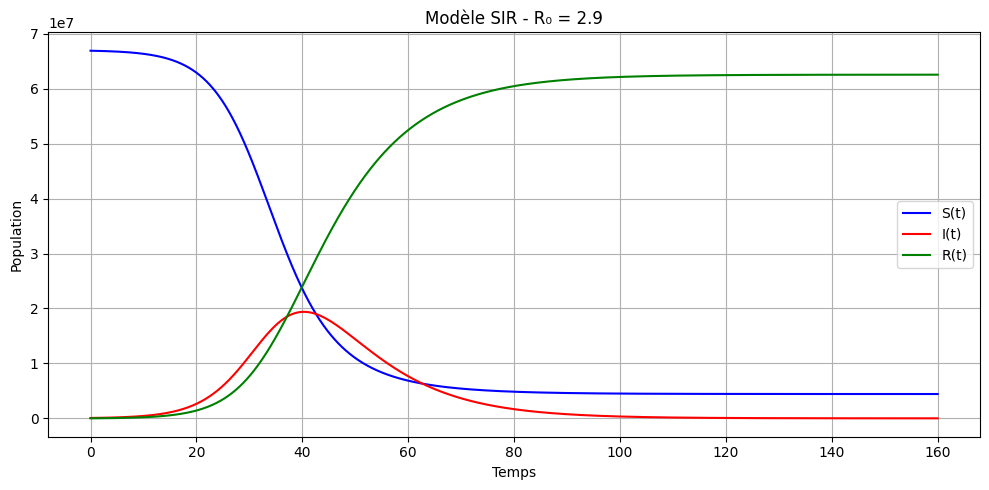

In [ ]:
scenarios = [
    {"beta": 0.29,  "label": "R₀ = 2.9", "ylim": (0, 300)}
]

for scenario in scenarios:
    beta = scenario["beta"]
    R0_val = beta / gamma
    t,S, I, R= simulation_deterministe(S0, I0, R0, beta, gamma, N, times, dt)

    plt.figure(figsize=(10, 5))
    plt.plot(t, S, label='S(t)', color='blue')
    plt.plot(t, I, label='I(t)', color='red')
    plt.plot(t, R, label='R(t)', color='green')

    plt.title(f"Modèle SIR - {scenario['label']}")
    plt.xlabel("Temps")
    plt.ylabel("Population")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


 Notre but dans la cellule suivante est de simuler dans le cadre déterminitre la matrice de transition

> c'est à dire construit la matrice de population (S, I, R) où chaque colonne représente l'état à un instant t.



<ipython-input-4-c817e4988e8b>:28: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


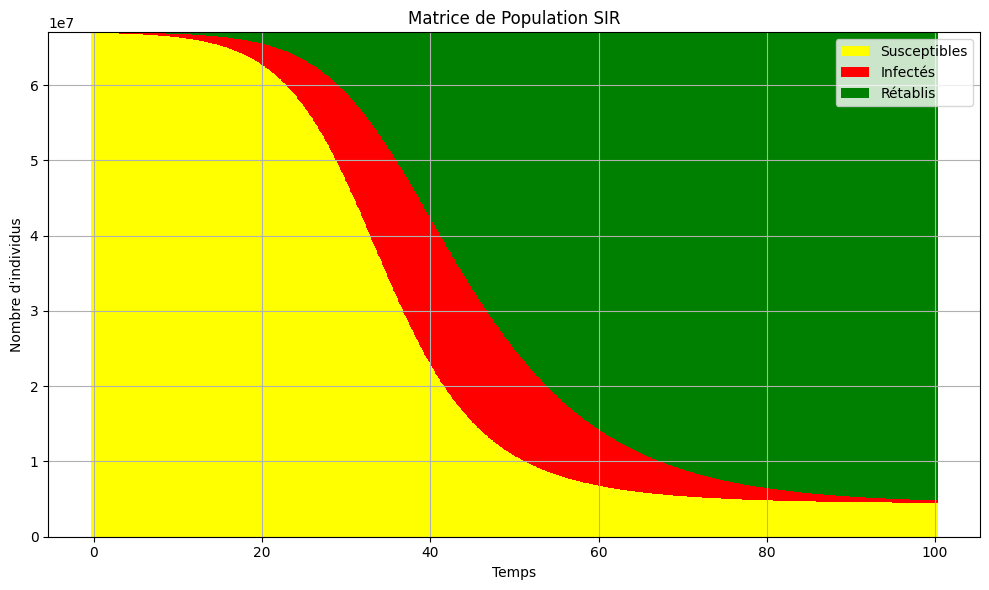

In [ ]:
## Notre matrice
def construire_matrice_population(S, I, R, times):
    """
    la fonction construit la matrice de population (S, I, R) où chaque colonne représente l'état à un instant t.
    """
    matrix = np.array([S, I, R]).T
    return matrix
## Affichage de la matrice
def plot_matrice_avec_couleurs(matrix, times):
    """
    Affiche la matrice de population avec des couleurs pour chaque groupe S, I, R.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Définition des couleurs pour chaque groupe
    color_map = ['yellow', 'red', 'green']
    labels = ['Susceptibles', 'Infectés', 'Rétablis']

    # Affichage de la matrice avec des couleurs pour chaque groupe
    for i in range(3):  # On a 3 groupes (S, I, R)
        ax.bar(times, matrix[:, i], bottom=np.sum(matrix[:, :i], axis=1), color=color_map[i], label=labels[i])

    ax.set_xlabel("Temps")
    ax.set_ylabel("Nombre d'individus")
    ax.set_title("Matrice de Population SIR")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

################################Simulation######################################
## Paramètres de la simulation
N = 67000000
gamma = 0.1
I0 = 67000
T= 100000
S0= 66933000
R0 = 0
beta = 0.29
T = 100
dt = 0.1
times = np.arange(0, T, dt)
temps,S, I, R = simulation_deterministe(S0, I0, R0, beta, gamma, N, times, dt)
l=100000
## Construire la matrice de population
matrix = construire_matrice_population(S[:l], I[:l], R[:l], times[:l])
## Visualisation de la matrice avec des couleurs
plot_matrice_avec_couleurs(matrix, times[:l])

# Influence de $R_0$

<ipython-input-5-23ce6939e90b>:14: RuntimeWarning: invalid value encountered in divide
  dS_unit = dS / norm
<ipython-input-5-23ce6939e90b>:15: RuntimeWarning: invalid value encountered in divide
  dI_unit = dI / norm


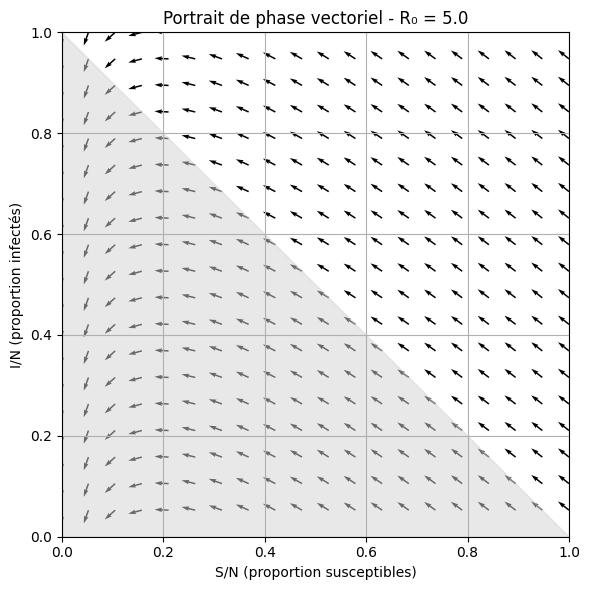

<ipython-input-5-23ce6939e90b>:48: RuntimeWarning: invalid value encountered in divide
  dS_unit = dS / norm
<ipython-input-5-23ce6939e90b>:49: RuntimeWarning: invalid value encountered in divide
  dI_unit = dI / norm


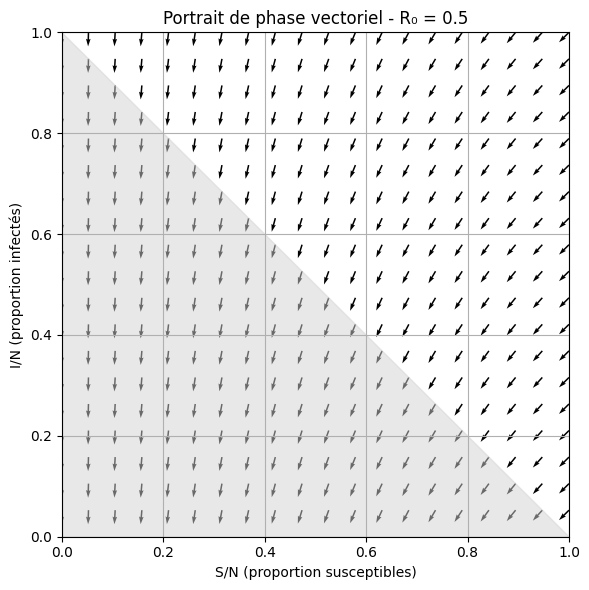

In [ ]:
############################################################################## Pour une valeur de R_0>1 ##################################################
# Paramètres
beta = 0.5
gamma = 0.1
N = 1000
############ Construction de la grille de points ################
s_vals = np.linspace(0, 1, 20)  # s = S / N
i_vals = np.linspace(0, 1, 20)  # i = I / N
S, I = np.meshgrid(s_vals, i_vals)
############ Ces équations viennent du modèle SIR continu  ######
dS = -beta * S * I
dI = beta * S * I - gamma * I
norm = np.sqrt(dS**2 + dI**2)
dS_unit = dS / norm
dI_unit = dI / norm

############################### Affichage #######################
plt.figure(figsize=(6, 6))
## Affichage du champ de vecteurs
plt.quiver(S, I, dS_unit, dI_unit, angles='xy')
plt.xlabel("S/N (proportion susceptibles)")
plt.ylabel("I/N (proportion infectés)")
plt.title(f"Portrait de phase vectoriel - R₀ = {beta / gamma:.1f}")
plt.grid()
## ON remplit la zone possible: Zone réalisable
plt.fill_between([0, 1], [1, 0], color='lightgray', alpha=0.5)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

############################## Pour une notre valeur de R_0 <1 ###################################

# Paramètres
beta = 0.05
gamma = 0.1
N = 1000
############ Construction de la grille de points ################
s_vals = np.linspace(0, 1, 20)  # s = S / N
i_vals = np.linspace(0, 1, 20)  # i = I / N
S, I = np.meshgrid(s_vals, i_vals)

############ Ces équations viennent du modèle SIR continu  ######
dS = -beta * S * I
dI = beta * S * I - gamma * I

norm = np.sqrt(dS**2 + dI**2)
dS_unit = dS / norm
dI_unit = dI / norm


############################### Affichage #######################
plt.figure(figsize=(6, 6))
## Affichage du champ de vecteurs
plt.quiver(S, I, dS_unit, dI_unit, angles='xy')
plt.xlabel("S/N (proportion susceptibles)")
plt.ylabel("I/N (proportion infectés)")
plt.title(f"Portrait de phase vectoriel - R₀ = {beta / gamma:.1f}")
plt.grid()

# ## ON remplit la zone possible: Zone réalisable
plt.fill_between([0, 1], [1, 0], color='lightgray', alpha=0.5)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


Les figures précédentes illustrent le portrait de phase du système différentiel réduit à deus dimensions dans le domaine admissible $ P = \{ (s, i) \in [0,1]^2 \mid s+i \leq 1 \} $,  avec $s=\frac{S}{N}$ et $ i=\frac{I}{N}$  pour les cas $ R_0 > 1 $ et $R_0 < 1$ respectivement. Ces figures permettent de visualiser l’influence du paramètre $ R_0 $ sur la dynamique épidémique.

La nullecline définie par $ \dot{i} = 0 $, soit $s = \frac{1}{R_0}$, est également représentée. Elle joue un rôle crucial dans la dynamique du système : elle sépare les zones où la population infectée croît ( $\dot{i} > 0 $) de celles où elle décroît ($\dot{i} < 0 $).


    

*   Pour $R_0 > 1 $, le point $(1,0)$ devient un point d'équilibre **instable**. Les trajectoires s'en éloignent, traduisant l'apparition d'une épidémie.
*   Pour $R_0 < 1 $, la nullecline sort du domaine admissible, ce qui implique ($\dot{i} < 0 $ partout dans $ P $. Le point $(1,0)$ devient alors un point d'équilibre **stable**, vers lequel toutes les trajectoires convergent : aucune épidémie ne se déclenche.


Ce comportement peut être confirmé par une analise linéaire au voisinage du point $(1,0)$. La matrice jacobienne évaluée en ce point est donnée par :
$
DJ(1, 0) = \begin{pmatrix}
0 & -\beta \\
0 & \beta - \gamma
\end{pmatrix}
$
Elle possède les valeurs propres $ 0 $ et $ \lambda = \beta - \gamma = \gamma(R_0 - 1) $. Ainsi :


*   si $ R_0 > 1 $, alors $ \lambda > 0$, l’état $(1,0)$ est instable, ce qui correspond à une dinamique épidémique croissante ;
*   si $ R_0 < 1 $, alors $ \lambda < 0 $, l’état $(1,0)$ est stable et l’épidémie s’éteint.

Le paramètre $R_0 $ apparaît donc comme un paramètre qui modifie qualitativement la nature du point d’équilibre \((1,0)\).

# Influence de $R_0 \cdot \frac{S_0}{N}$

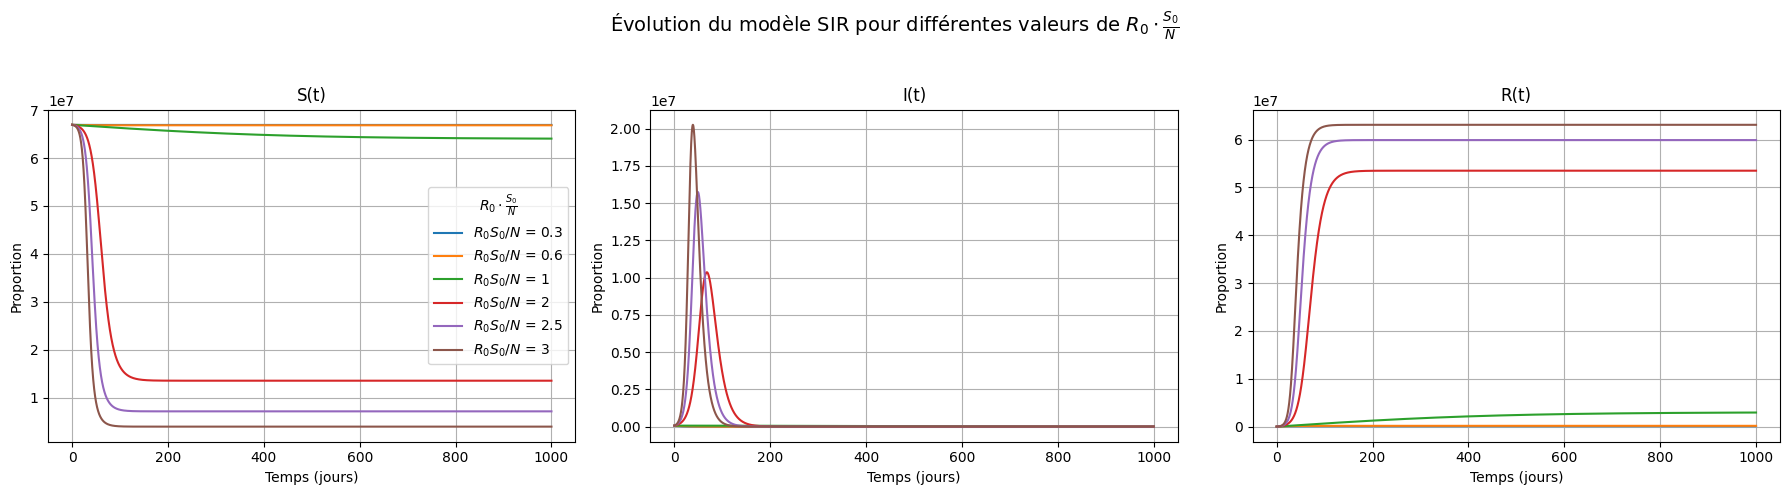

In [ ]:
#################### Paramètres globaux ########################################
N = 67_000_000
gamma = 0.1
I0 = 67_000
S0 = N - I0
R0_init = 0
T = 1000
dt = 0.1
times = np.arange(0, T + dt, dt)

### Liste de valeurs de R0*S0/N à tester
ratios = [0.3, 0.6, 1, 2, 2.5, 3]

colors = plt.get_cmap('tab10').colors

### Tracé
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

for ratio, color in zip(ratios, colors):
    beta = ratio * gamma * N / S0
    t, S, I, R = simulation_deterministe(S0, I0, R0_init, beta, gamma, N, times, dt)

    axes[0].plot(t, S, label=fr'$R_0 S_0/N$ = {round(ratio, 2)}', color=color)
    axes[1].plot(t, I, color=color)
    axes[2].plot(t, R, color=color)

### Légendes et titres
axes[0].set_title('S(t)')
axes[1].set_title('I(t)')
axes[2].set_title('R(t)')

for ax in axes:
    ax.set_xlabel('Temps (jours)')
    ax.set_ylabel('Proportion')
    ax.grid(True)

axes[0].legend(title=r'$R_0 \cdot \frac{S_0}{N}$', loc='best')
plt.suptitle("Évolution du modèle SIR pour différentes valeurs de " + r"$R_0 \cdot \frac{S_0}{N}$", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

On note l'apparition pour d'une autre valeur critique $\frac{\mathcal{R}_0⋅\mathcal{S}_0}{N}$ pour l'évolution de i(t):
* Si $\mathcal{R}_0 ⋅\frac{\mathcal{S}_0}{N}\leqslant 1$, le ratio de personnes infectées décroît vers $0$
* Si $\mathcal{R}_0 \cdot \frac{\mathcal{S}_0}{N}>1$, le ratio de personnes infectées croît vers $I_{\max} = N \left[1 - \frac{\gamma}{\beta} + \frac{\gamma}{\beta} \ln\left(\frac{\gamma N}{\beta S_0}\right)\right].$ puis décroît vers 0.

Dans la suite on notera ce paramètre  $\frac{\mathcal{R}_0⋅\mathcal{S}_0}{N}= \mathcal{R}_{eff} $

Quant à $S(t)$ et $R(t)$, leurs comportements se montre comme suit :

* $S(t)$ décroît strictement vers $S_{\infty}$ qui vérifie $S_\infty = S_0 \exp\left[ \frac{\beta}{\gamma} \left( \frac{S_\infty}{N} - 1 \right) \right]$

* $R(t)$ croît strictement vers $R_{\infty}=N-S_{\infty}$

# Evolution de $I_{max}$ en fonction de $R_0$

In [ ]:
### Fonction I_max
def I_max(N, S_0, R_0):
    if R_0 * S_0 / N <= 1:
        return I_0
    return N * (1 - 1/R_0 + (1/R_0) * np.log(N / (R_0 * S_0)))


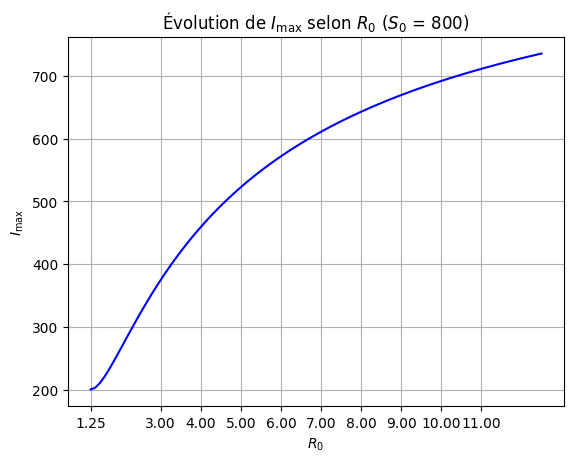

In [ ]:
### Paramètres non normalisés
N = 1000
S_0 = 800
I_0 = N - S_0


### Valeurs de R0 à tester
R0_values = np.linspace(N/S_0, 10*N/S_0, 100)
I_values = [I_max(N, S_0, R) for R in R0_values]

### Tracé
plt.plot(R0_values, I_values, 'b')
plt.title(r"Évolution de $I_{\max}$ selon $R_0$ ($S_0$ = " + str(S_0) + ")")
plt.xlabel(r"$R_0$")
plt.ylabel(r"$I_{\max}$")
plt.grid(True)
plt.xticks([round(N/S_0, 2)] + list(range(3, 12)))
plt.show()

## Interprétation:

On constate que  **$I_{max}$ croît avec $\mathcal{R}_0$** et cette remarque est très cohérente avec la logique du modèle. En effet, la croissance de $\mathcal{R}_0$ traduit que $\beta$ est plus grand que $\gamma$ et donc plus d'infection.


#L'évolution de $S_{\infty}$ en fonction de $\mathcal{R}_0$


In [ ]:
from scipy.optimize import fsolve
### Équation implicite pour S_inf
def equation_S_inf(S_inf, S_0, R_0, N):
    return S_inf - S_0 * np.exp(R_0 * (S_inf / N - 1))

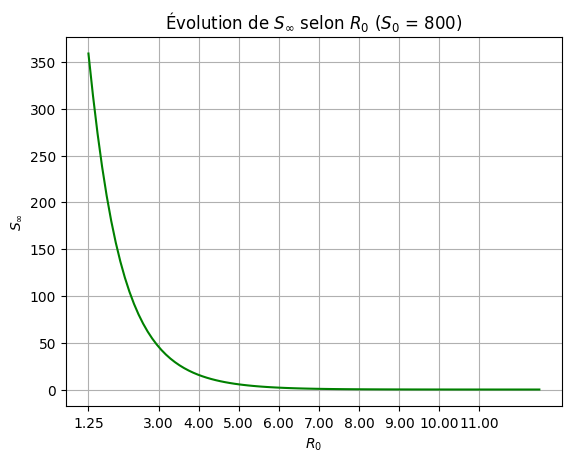

In [ ]:


### Paramètres
N = 1000
S_0 = 800



### Résolution pour plusieurs valeurs de R0
R0_values = np.linspace(N / S_0, 10 * N / S_0, 100)
S_inf_values = []

for R_0 in R0_values:
    ### Deviner une solution initiale raisonnable (entre 0 et S_0)
    guess = S_0 / 2
    S_inf_solution = fsolve(equation_S_inf, guess, args=(S_0, R_0, N))[0]
    S_inf_values.append(S_inf_solution)

### Tracé
plt.plot(R0_values, S_inf_values, 'g')
plt.title(r"Évolution de $S_{\infty}$ selon $R_0$ ($S_0$ = " + str(S_0) + ")")
plt.xlabel(r"$R_0$")
plt.ylabel(r"$S_{\infty}$")
plt.grid(True)
plt.xticks([round(N/S_0, 2)] + list(range(3, 12)))
plt.show()

## Interprétation:
On remarque bien une décroissance exponentielle, conforme à la logique théorique.



# Modèle stochastique

On modélise l'épidémie par une chaîne de Markov à temps continu définie par:
$$
(S, I, R) \mapsto
\begin{cases}
(S - 1, I + 1, R) & \text{à taux } \displaystyle\frac{\beta S I}{N} \\[1ex]
(S, I - 1, R + 1) & \text{à taux } \gamma I
\end{cases}
\quad \text{où le processus s'arrete lorsque } I(t) = 0.
$$


## Première méthode de simulation


> À partir d’un état $(S(t), I(t), R(t))$, pour déterminer l’état suivant dans un processus SIR stochastique, on peut simuler deux variables aléatoires indépendantes :



- Temps avant une infection  $$T_0 \sim \mathcal{E}\left(\dfrac{\beta S I}{N}\right)$$
- Temps avant une guérison $$T_1 \sim \mathcal{E}(\gamma I)$$

La chaîne reste alors dans l’état courant pendant un temps :

$$
T = \min(T_0, T_1)
$$

et effectue une transition déterminée par la comparaison $1(T_1 > T_0)$,c’est-à-dire :

- si $T_0 < T_1$, une infection se produit : $(S - 1, I + 1, R)$  
- sinon, une guérison : $(S, I - 1, R + 1)$




## Deuxième méthode de simulation
> On peut utiliser une deuxième méthode pour simuler notre chaîne de Markov, qui sera justifiée et prouvée par la suite :

- on simule un unique temps  
  $
  T \sim \mathcal{E}\left( \dfrac{\beta S I}{N} + \gamma I \right)
  $

- puis on simule une variable de Bernoulli  
  $
  S \sim \mathcal{B}\left( \dfrac{\frac{\beta S I}{N}}{\frac{\beta S I}{N} + \gamma I} \right)
  $

- si $S = 1$, on effectue une infection, sinon une guérison

Cette méthode, équivalente à la précédente, présente un avantage conceptuel important : il n’est pas nécessaire de connaître les instants exacts des sauts pour déterminer des propriétés globales du système (par exemple l’état final). Ainsi, l’ordre exact des événements dans le temps peut être ignoré.

---

On choisit la 2 ième méthode de simulation pour notre modélisation

In [ ]:
################################################# Nous avons choisi la 2 ième manière de simulation #############################
def simulation_stochastique(S_0, N, gamma, beta, R_0=0):
    ## Liste des temps de saut (initialement t=0)
    t_de_sauts = [0]
    ## Initialisation de l'état S, I, R
    S = S_0
    I = N - S_0 - R_0  # Nombre initial d'infectés
    R = R_0            # Nombre initial de retirés (par défaut 0)

    ## Liste pour stocker l'évolution des états (S, I, R)
    SIR = [[S, I, R]]

    ## Boucle jusqu'à extinction de l'épidémie (I = 0)
    while I > 0:
        ## Taux total de transition depuis l'état courant :
        taux_total = beta * I * S / N + gamma * I

        ## Tirage du temps avant la prochaine transition
        T = np.random.exponential(scale=1 / taux_total)
        t_de_sauts.append(T)

        ## Taux de transition infection seule (S→I)
        taux_infection = beta * I * S / N

        ## Probabilité que la prochaine transition soit une infection
        proba = taux_infection / taux_total

        ## Tirage aléatoire pour décider du type de transition (notre bernoulli)
        U = np.random.rand()
        if U <= proba:
            ## Infection
            S, I, R = S - 1, I + 1, R
        else:
            ## Guérison
            S, I, R = S, I - 1, R + 1

        SIR.append([S, I, R])

    t_de_sauts = np.cumsum(t_de_sauts)
    return t_de_sauts, np.array(SIR)

# Courbe de $I,S,R$ pour différentes valeurs de $R_0$

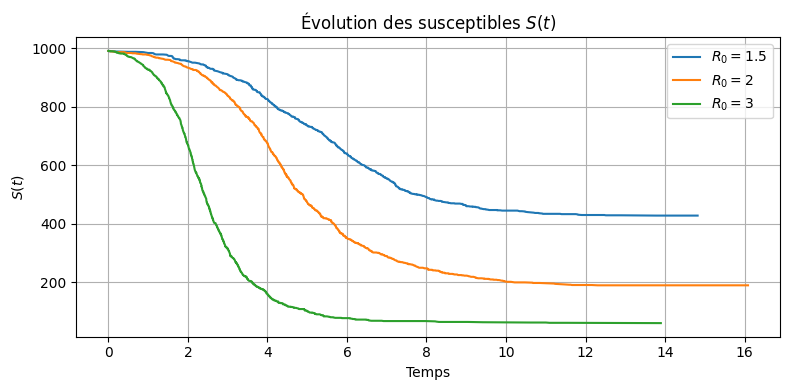

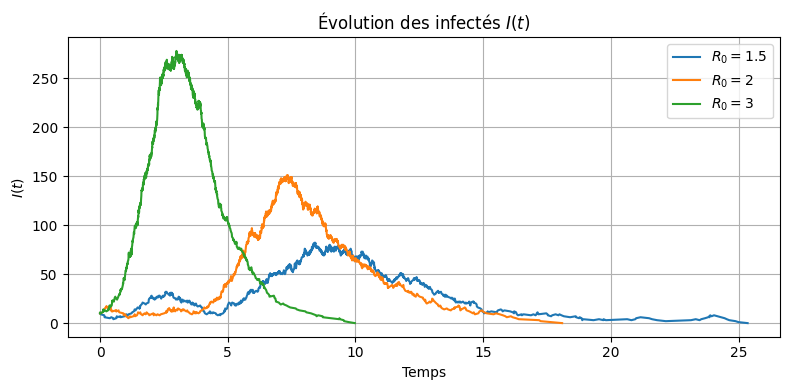

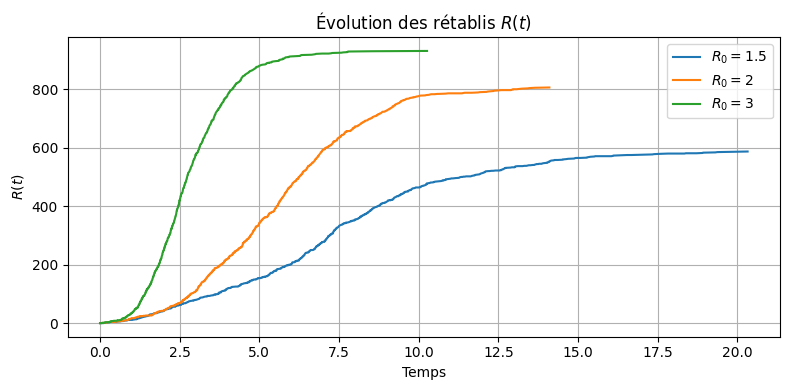

In [ ]:

## Paramètres
N = 1000
S_0 = 990
R_0_values = [1.5, 2, 3]
gamma = 1

############# Courbe des susceptibles: S ########################
plt.figure(figsize=(8, 4))
for R_0_val in R_0_values:
    beta = R_0_val * gamma
    t, sir = simulation_stochastique(S_0, N, gamma, beta)
    S = sir[:, 0]
    plt.plot(t, S, label=fr'$R_0 = {R_0_val}$')
plt.title('Évolution des susceptibles $S(t)$')
plt.xlabel('Temps')
plt.ylabel('$S(t)$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

################ Courbe des infectés: I ##########################
plt.figure(figsize=(8, 4))
for R_0_val in R_0_values:
    beta = R_0_val * gamma
    t, sir = simulation_stochastique(S_0, N, gamma, beta)
    I = sir[:, 1]
    plt.plot(t, I, label=fr'$R_0 = {R_0_val}$')
plt.title('Évolution des infectés $I(t)$')
plt.xlabel('Temps')
plt.ylabel('$I(t)$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##################### Courbe des rétablis: R ##################
plt.figure(figsize=(8, 4))
for R_0_val in R_0_values:
    beta = R_0_val * gamma
    t, sir = simulation_stochastique(S_0, N, gamma, beta)
    R = sir[:, 2]
    plt.plot(t, R, label=fr'$R_0 = {R_0_val}$')
plt.title('Évolution des rétablis $R(t)$')
plt.xlabel('Temps')
plt.ylabel('$R(t)$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Remarque:
Les courbes de la simulation stochastique sont en adéquation (en terme de forme des courbes) avec les courbes de la simulation déterministe.

## Courbe de $I,S,R$ pour différentes valeurs de $I_0$

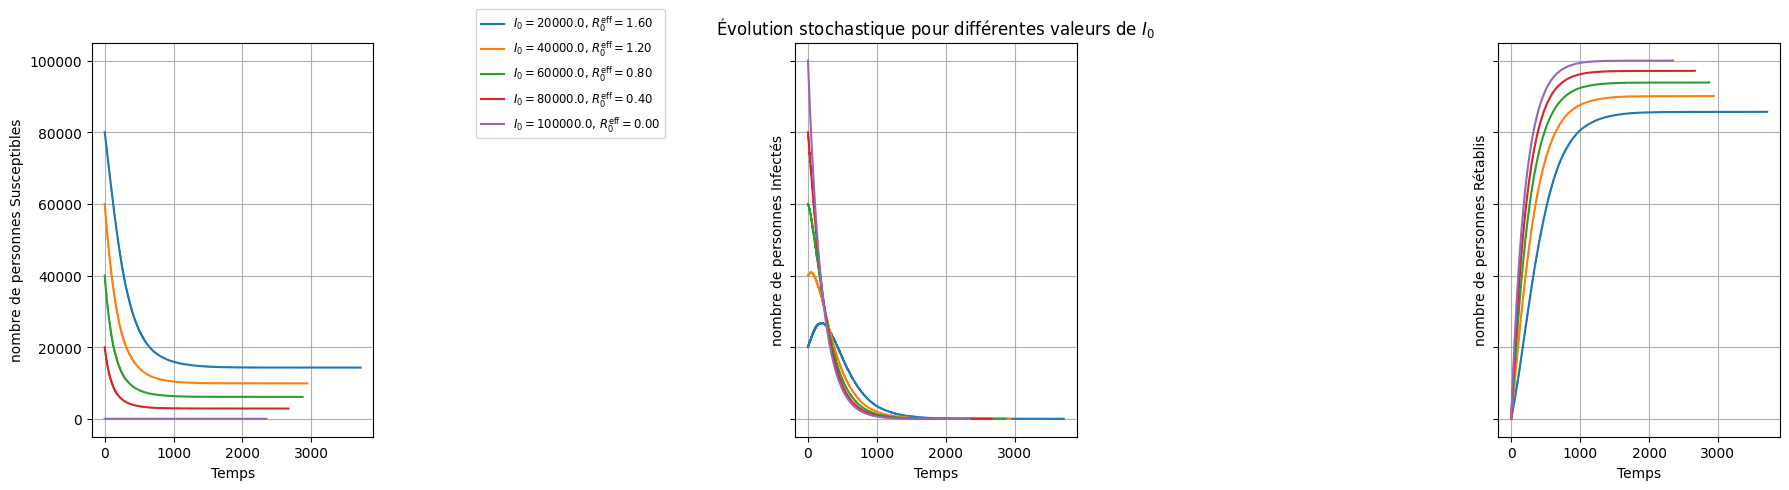

In [ ]:
### Paramètres
N = 100_000
gamma = 0.005
beta = 0.01
labels = ['Susceptibles', 'Infectés', 'Rétablis']
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

### On boucle sur différentes valeurs de I_0
for I_0 in range(N // 5, N + 1, N // 5):
    S_0 = N - I_0
    temps, SIR_sto = simulation_stochastique(S_0, N, gamma=gamma, beta=beta)
    R0_effectif = beta * S_0 / (gamma * N)

    for i in range(3):
        axes[i].step(temps, SIR_sto[:, i], where='post',
                     label=(f'$I_0={I_0:.1f}$, $R_0^\\mathrm{{eff}}={R0_effectif:.2f}$') if i == 0 else "")
        axes[i].set_xlabel('Temps')
        axes[i].set_ylabel(f'nombre de personnes {labels[i]}')
        axes[i].grid(True)

axes[1].set_title("Évolution stochastique pour différentes valeurs de $I_0$")
axes[0].legend(loc='upper center', bbox_to_anchor=(1.7, 1.1), ncol=1, fontsize='small')
plt.tight_layout()
plt.show()

# Courbe de $I,S,R$ pour différentes valeurs de beta

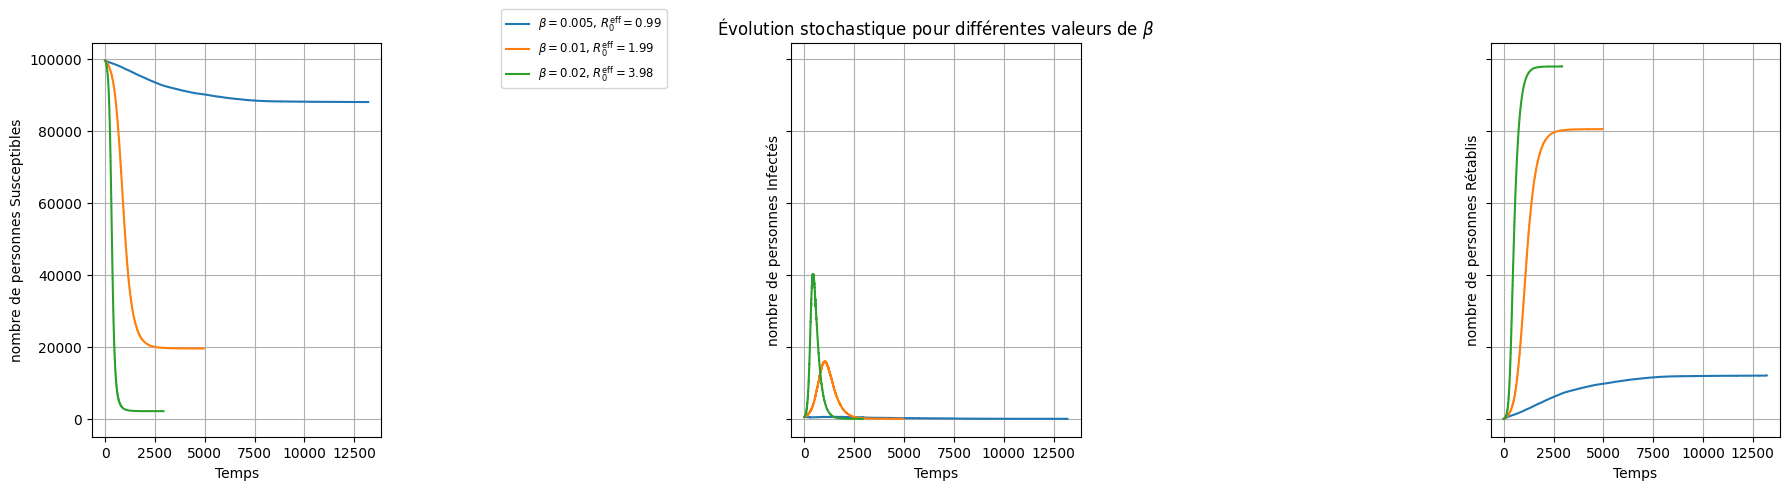

In [ ]:
N = 100000
gamma = 0.005
I_0 = 500
S_0 = N - I_0

### Valeurs de beta à tester
betas = [0.005, 0.01, 0.02]
labels = ['Susceptibles', 'Infectés', 'Rétablis']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

### Boucle sur les différentes valeurs de beta
for beta in betas:
    ### Vérification que la simulation renvoie des résultats corrects
    temps, SIR_sto = simulation_stochastique(S_0, N, gamma=gamma, beta=beta)

    ### Calcul du R0 effectif
    R0_effectif = beta * S_0 / (gamma * N)


    ### Tracer les résultats pour chaque compartiment S, I, R
    for i in range(3):
        ### Affichage des courbes
        label = f"$\\beta={beta}$, $R_0^{{\\mathrm{{eff}}}}={R0_effectif:.2f}$" if i == 0 else ""
        axes[i].step(temps, SIR_sto[:, i], where='post', label=label)
        axes[i].set_xlabel('Temps')
        axes[i].set_ylabel(f'nombre de personnes {labels[i]}')
        axes[i].grid(True)

axes[1].set_title("Évolution stochastique pour différentes valeurs de $\\beta$")
axes[0].legend(loc='upper center', bbox_to_anchor=(1.7, 1.1), ncol=1, fontsize='small')
plt.tight_layout()
plt.show()

# Courbe de $I,S,R$ pour différentes valeurs de gamma

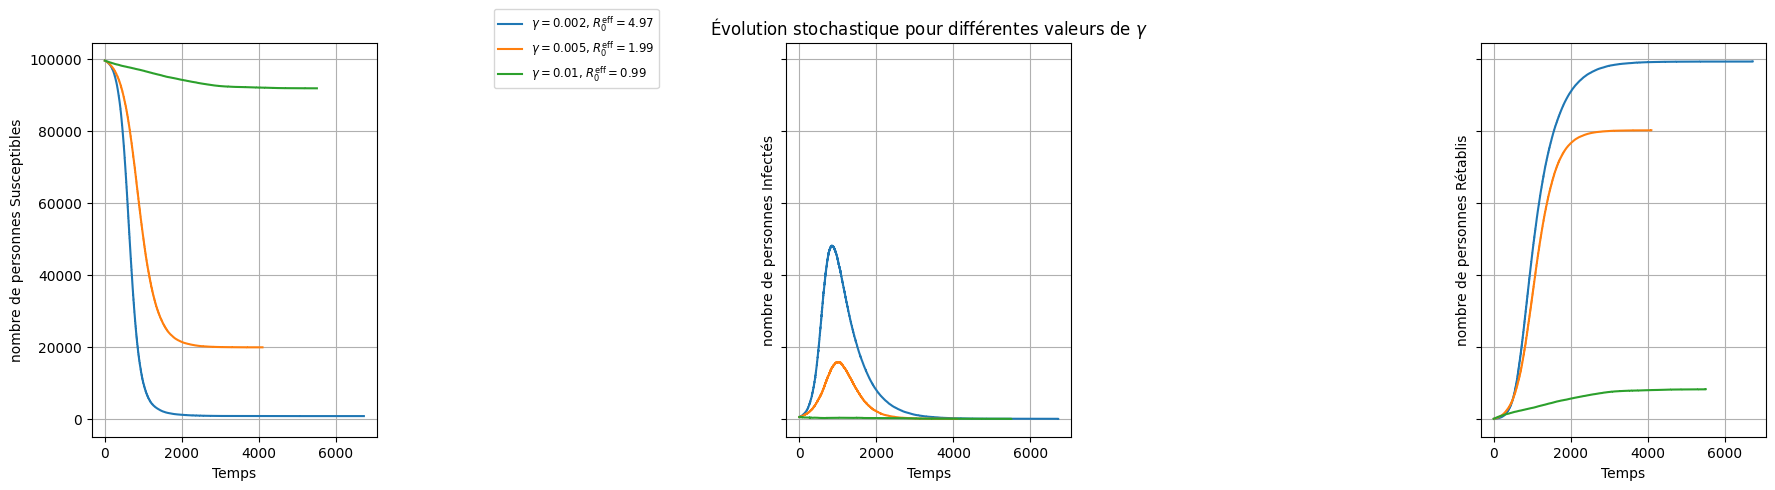

In [ ]:
### Paramètre
N = 100000
beta = 0.01
I_0 = 500
S_0 = N - I_0
### Valeurs de gamma à tester
gammas = [0.002, 0.005, 0.01]
labels = ['Susceptibles', 'Infectés', 'Rétablis']
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for gamma in gammas:
    ### Vérification que la simulation renvoie des résultats corrects
    temps, SIR_sto = simulation_stochastique(S_0, N, gamma=gamma, beta=beta)

    ### Calcul du R0 effectif
    R0_effectif = beta * S_0 / (gamma * N)

    ### Tracer les résultats pour chaque compartiment S, I, R
    for i in range(3):
        ### Affichage des courbes
        label = f"$\\gamma={gamma}$, $R_0^{{\\mathrm{{eff}}}}={R0_effectif:.2f}$" if i == 0 else ""
        axes[i].step(temps, SIR_sto[:, i], where='post', label=label)
        axes[i].set_xlabel('Temps')
        axes[i].set_ylabel(f'nombre de personnes {labels[i]}')
        axes[i].grid(True)

### Ajouter un titre et une légende
axes[1].set_title("Évolution stochastique pour différentes valeurs de $\\gamma$")
axes[0].legend(loc='upper center', bbox_to_anchor=(1.7, 1.1), ncol=1, fontsize='small')
plt.tight_layout()
plt.show()

## Interprétation
Différentes valeurs de $I_{0}$ signifie différentes valeurs de $S_{0}$, donc différentes valeur de $R_{eff}$ et par conséquent différents comportements de notre épidémie. Comme vu aupparavant avec l'interprétation de l'influence de $R_{eff}$. Meme chose avec gamma et beta.

# Comparaison entre la modélisation déterministe et stochastique


Notre but dans cette partie est d'illustrer visuellement la loi des grands nombres dans le modèle SIR, c’est-à-dire montrer que :

> Quand $𝑁$ devient grand, la simulation stochastique fluctue de moins en moins et se rapproche de la solution déterministe.

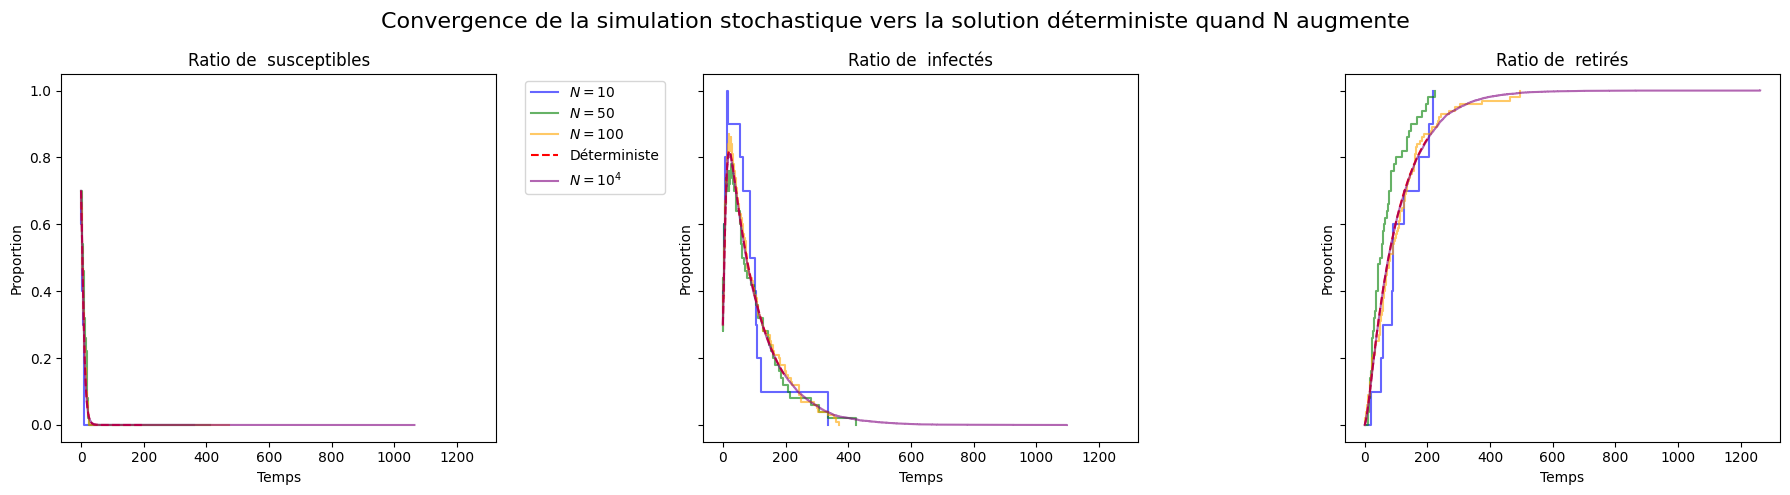

In [ ]:
Ns = [10, 50, 100, 10000]
colors = ['blue', 'green', 'orange', 'purple', 'black']
labels = [r'$N=10$', r'$N=50$', r'$N=100$', r'$N=10^4$']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
typ = [' susceptibles', ' infectés', ' retirés']

for i in range(3):  ## Pour S, I, R
    for idx, N in enumerate(Ns):
        I0 = int(0.3 * N)
        S0 = N - I0
        R0 = 0
        beta = 0.2
        gamma = 0.01
        dt = 0.1
        times = np.arange(0, 200, dt)

        ### Simulation déterministe seulement pour le plus grand N
        if N == max(Ns):
            t_det, S_det, I_det, R_det = simulation_deterministe(S0, I0, R0, beta, gamma, N, times, dt)
            if i == 0:
                y_det = S_det
            elif i == 1:
                y_det = I_det
            else:
                y_det = R_det
            axes[i].plot(t_det, y_det / N, linestyle='dashed', color='red', label='Déterministe')

        ### Simulation stochastique
        t_sto, SIR_sto = simulation_stochastique(S0, N, gamma, beta)
        axes[i].step(t_sto, SIR_sto[:, i] / N, where='post', alpha=0.6, color=colors[idx], label=labels[idx])

    axes[i].set_title(f'Ratio de {typ[i]}')
    axes[i].set_xlabel('Temps')
    axes[i].set_ylabel('Proportion')

axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
fig.suptitle('Convergence de la simulation stochastique vers la solution déterministe quand N augmente', fontsize=16)
plt.tight_layout()
plt.show()

### Interprétation:
* Pour petits **N** : les courbes stochastiques varient beaucoup, elles sont irrégulières.

* Pour grands **N** : elles sont proches de la courbe déterministe rouge en pointillés. On voit aussi visuellement que la fluctuation diminue, donc l’approximation s’améliore.

# Stochastique - déterministe= loi normale ?



> Cette partie a pour but de montrer expérimentalement que l'écart entre la solution stochastique et la solution déterministe à un temps donné suit (asymptotiquement) une loi normale lorsque la taille de la population est grande $N=10 000$ ici.



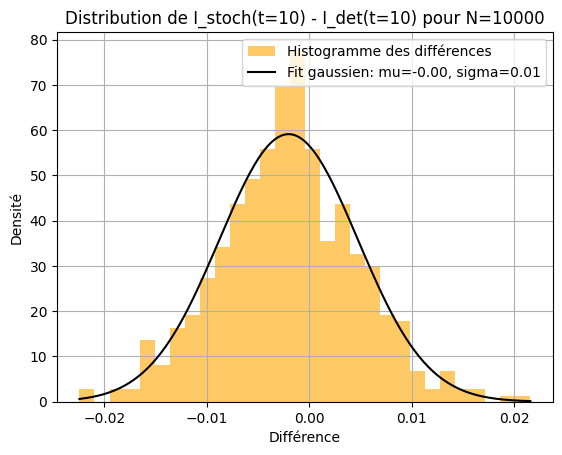

In [ ]:
from scipy.stats import norm
### Paramètres
N = 10000
I0 = int(0.2 * N)
S0 = N - I0
R0 = 0
beta = 0.3
gamma = 0.1
dt = 0.1
Tmax = 30
times = np.arange(0, Tmax, dt)
t_target = 10
nb_simus = 500
typ = ['sn et s', ' in et i']

### Solution déterministe
t_det, S_det, I_det, R_det = simulation_deterministe(S0, I0, R0, beta, gamma, N, times, dt)
I_det_at_t = np.interp(t_target, t_det, I_det)

# Liste pour stocker les différences
differences = []

for _ in range(nb_simus):
    t_sto, SIR_sto = simulation_stochastique(S0, N, gamma, beta, R0)
    I_sto = SIR_sto[:, 1]
    I_sto_at_t = np.interp(t_target, t_sto, I_sto)
    diff = I_sto_at_t - I_det_at_t
    differences.append(diff / N)

# Histogramme
plt.hist(differences, bins=30, density=True, alpha=0.6, color='orange', label='Histogramme des différences')

# Ajustement de la gaussienne (ajustement automatique)
mu, std = norm.fit(differences)
x = np.linspace(min(differences), max(differences), 200)
plt.plot(x, norm.pdf(x, mu, std), color='black', label=f'Fit gaussien: mu={mu:.2f}, sigma={std:.2f}')

plt.title(f"Distribution de I_stoch(t={t_target}) - I_det(t={t_target}) pour N={N}")
plt.xlabel("Différence")
plt.ylabel("Densité")
plt.legend()
plt.grid()
plt.show()


#Partie 2: Calcul numérique d'évènements *rares*  $\mathbb{P}(R(\infty) > K) $

Pour estimer cette probabilité, nous avons appliqué trois méthodes :

1. **Monte Carlo naïf** (MC)

2. **Méthodes de l’échantillonnage préférentiel (Importance Sampling)**

   - *Version discrète* :
     - Avec optimisation des paramètres via un algorithme d’entropie. ($IS_{CEdiscret}$)
     - Ou en utilisant les résultats issus de l’approche déterministe
(cf. équation de $R_∞$  ). ($IS_{discret}$)

   - *Version continue* :
     - Avec optimisation par entropie.($IS_{CEcontinue}$)
     - Ou selon les résultats déterministes
(cf. équation de $R_{\infty}$).($IS_{continue}$)

3. **Méthode IBPS**

##Implémentation Monte Carlo Naïf

In [ ]:
def proba_MonteCarlo(S_0,N,beta,gamma,Seuil,M) :
  R=[]
  ### Lance l'evolution stochastique M fois et calcule la moyenne
  for k in range (M):
    R_inf= simulation_stochastique(S_0,N,gamma,beta)[1][:,2][-1]
    R.append(R_inf)

  return np.mean(np.array(R)>Seuil)


# 2.) Evaluation par Importance Sampling


Dans des situations où des événements rares ont une probabilité extrêmement faible dans les conditions initiales, une simulation classique nécessiterait un grand nombre de répétitions pour observer ces événements de manière significative. L'IS résout ce problème en :

1. Modifiant la distribution de probabilité sous-jacente pour que les événements rares se produisent plus fréquemment avec de nouveaux paramétres  $ \beta_{new}$  et  $\gamma_{new} $.
2. Ajustant les résultats à l'aide d'un facteur de vraisemblance $\phi_i$ pour compenser cette modification et conserver la validité statistique .

La probabilité estimée est donnée par :

$$
P(R(\infty) > K) = \frac{1}{N_{\text{samples}}} \sum_{i=1}^{N_{\text{samples}}} \phi_i * 1(R>K)
$$

On rappelle que :

𝑆(𝑡)  décroît strictement vers  $𝑆_∞$  qui vérifie $ 𝑆_∞ =𝑆_0 *exp[𝛽𝛾(\frac{𝑆_∞}{𝑁}−1)] $

𝑅(𝑡)  croît strictement vers $ 𝑅∞=𝑁−𝑆∞ $

On choisit $\mathcal{R}_0 new $ de tel façon que $R_∞$ dépasse le seuil , par exemple  $R_\infty = Seuil $

On a : $ \mathcal{R}_0 = \frac {ln( \frac{N-R_\infty }{S_0} )}{\frac{𝑆∞}{𝑁}−1}$

Donc on prend : $ \mathcal{R}_0new = \frac {ln( \frac{N-Seuil}{S_0} )}{\frac{𝑆∞}{𝑁}−1}$




##Importance sampling cas discret
$$
ϕ_k = \prod_i
\frac{
     \beta_{\text{new}} \cdot \frac{I^i \cdot S^i}{N} + \gamma_{\text{new}} \cdot I^i
}{
     \beta \cdot \frac{I^i \cdot S^i}{N} + \gamma \cdot I^i
}
\left( \frac{\beta}{\beta_{\text{new}}} \right)^p
\cdot
\left( \frac{\gamma}{\gamma_{\text{new}}} \right)^q
$$



In [ ]:
def proba_IS_discret(S_0, I_0, N, beta, gamma, beta_new, gamma_new, Seuil, M):

    p = []  ### Liste pour stocker les résultats pondérés des simulations

    for i in range(M):  ### Effectuer M simulations
        S, I, R = S_0, I_0, 0  ### Initialisation des états S, I, R
        phi = 1  ### Poids initial (rapports de vraisemblance)

        while I > 0:  ### Boucle tant qu'il reste des infectés
            ### Calcul des "normes" pour le modèle ajusté (new) et initial
            norm_new = beta_new * I * S / N + gamma_new * I
            norm = beta * I * S / N + gamma * I

            ### Calcul de la probabilité de transition selon le modèle ajusté
            proba = (beta_new * I * S / N) / norm_new

            ### Temps d'attente dans l'état courant
            T = np.random.exponential(scale=1 / norm_new)

            ### Mise à jour du poids avec le rapport des vraisemblances
            phi *= norm_new / norm

            ### Génération d'un nombre aléatoire pour décider de la transition
            U = np.random.rand()
            if U <= proba:  ### Transition S -> I (nouvelle infection)
                S, I, R = S - 1, I + 1, R
                phi *= beta / beta_new  ### Ajustement du poids pour beta
            else:  ### Transition I -> R (guérison)
                S, I, R = S, I - 1, R + 1
                phi *= gamma / gamma_new  ### Ajustement du poids pour gamma

        ### Ajouter le résultat pondéré à la liste
        p.append((R > Seuil) * phi)

    ### Retourne la moyenne des pondérations (estimation de la probabilité)
    return np.mean(p)

## Importance Sampling cas continue


$$
\phi_i = \exp\left(-\int (\beta - \beta_{\text{new}}) \frac{SI}{N} \, dt - \int (\gamma - \gamma_{\text{new}}) I \, dt + \text{log}\left(\frac{\beta}{\beta_{\text{new}}}\right) \cdot \text{infections} + \text{log}\left(\frac{\gamma}{\gamma_{\text{new}}}\right) \cdot \text{recoveries}\right)
$$



In [ ]:
def proba_IS_continue(S_0, I_0, N, beta, gamma, beta_new, gamma_new, Seuil, M):
    p = []  ### Liste pour stocker les résultats pondérés des simulations

    for i in range(M):
        S, I, R = S_0, I_0, 0  ### Initialisation des états S, I, R
        phi = 1  ### Poids initial (rapports de vraisemblance)

        while I > 0:  ### Boucle tant qu'il reste des infectés
            ### Calcul de la "norme" pour le modèle ajusté (new)
            norm_new = beta_new * I * S / N + gamma_new * I

            ### Calcul de la probabilité de transition selon le modèle ajusté
            proba = beta_new * I * S / N / norm_new

            ### Temps d'attente dans l'état courant
            T = np.random.exponential(scale=1 / norm_new)

            ### Ajustement de la vraisemblance par rapport au temps écoulé
            phi *= np.exp(-T * ((beta - beta_new) * S * I / N + (gamma - gamma_new) * I))

            ### Génération d'un nombre aléatoire pour décider de la transition
            U = np.random.rand()
            if U <= proba:  # Transition S -> I (nouvelle infection)
                S, I, R = S - 1, I + 1, R
                phi *= beta / beta_new  # Ajustement du poids pour beta
            else:  # Transition I -> R (guérison)
                S, I, R = S, I - 1, R + 1
                phi *= gamma / gamma_new  # Ajustement du poids pour gamma

        ### Ajouter le résultat pondéré à la liste
        p.append((R > Seuil) * phi)

    ### Retourne la moyenne des pondérations (estimation de la probabilité)
    return np.mean(p)

##  Algorithme Cross-Entropy (CE): pour l'optimisation des paramètres

L’algorithme `proba_ce_IS` adapte progressivement les paramètres de proposition $\beta_{\text{prop}}, \gamma_{\text{prop}}$ pour améliorer l'efficacité de l'estimation.

### Étapes :

**1. Initialisation**  
On commence avec :
$$
\beta_{\text{prop}} = \beta, \quad \gamma_{\text{prop}} = \gamma
$$

**2. Génération de trajectoires**  
On simule $ M $ trajectoires à l’aide des paramètres de proposition.

**3. Sélection des élites**  
On conserve uniquement les trajectoires qui satisfont l’événement rare :  
$$
R > \text{seuil}
$$

**4. Mise à jour des paramètres**  
À partir des trajectoires élites, on met à jour les paramètres par maximum de vraisemblance pondéré :

$$
\beta_{\text{prop}}^{(k+1)} = \frac{\mathbb{E}[\text{nombre d'infections élites}]}{\mathbb{E}\left[\int \frac{SI}{N} \, dt\right]}
$$

$$
\gamma_{\text{prop}}^{(k+1)} = \frac{\mathbb{E}[\text{nombre de guérisons élites}]}{\mathbb{E}\left[\int I \, dt\right]}$$

**5. Répétition**  
On répète les étapes $ K $ fois pour affiner les paramètres.

**6. Estimation finale**  
On estime la probabilité de l’événement rare à l’aide de $ M_{\text{final}} $ trajectoires optimisées :

$$
\hat{p} = \frac{1}{M_{\text{final}}} \sum_{i=1}^{M_{\text{final}}} \mathbf{1}_{\text{succès}_i} \cdot \phi_i
$$

où $ \phi_i $ est le ratio de vraisemblance pour la trajectoire $ i $, et $ \mathbf{1}_{\text{succès}_i} $ indique si la trajectoire satisfait l’événement rare.


In [ ]:
def simuler_trajectoire_continue(S0, I0, N, beta_orig, gamma_orig, beta_prop, gamma_prop, Seuil):
    S, I, R = S0, I0, 0
    phi = 1.0
    infections = 0
    guerisons = 0
    integrale_beta = 0.0
    integrale_gamma = 0.0
    temps_precedent = 0.0

    while I > 0:
        S_I_sur_N = S * I / N
        I_courant = I
        taux_infection = beta_prop * S_I_sur_N
        taux_guerison = gamma_prop * I_courant
        taux_total = taux_infection + taux_guerison

        if taux_total <= 0:
            break  ### Éviter une division par zéro

        ### Temps jusqu'au prochain événement
        T = np.random.exponential(1 / taux_total)
        temps_courant = temps_precedent + T

        ### Mise à jour des intégrales pour beta et gamma
        integrale_beta += S_I_sur_N * T
        integrale_gamma += I_courant * T

        ### Ajuste le rapport de vraisemblance phi
        taux_infection_original = beta_orig * S_I_sur_N
        taux_guerison_original = gamma_orig * I_courant
        phi *= np.exp(-T * (taux_infection_original + taux_guerison_original - taux_infection - taux_guerison))

        ### Détermine le type d'événement
        if np.random.rand() < (taux_infection / taux_total):
            # Événement d'infection
            S -= 1
            I += 1
            infections += 1
            phi *= (beta_orig / beta_prop)
        else:
            ### Événement de guérison
            I -= 1
            R += 1
            guerisons += 1
            phi *= (gamma_orig / gamma_prop)

        temps_precedent = temps_courant

    succes = R > Seuil
    return {
        'succes': succes,
        'phi': phi,
        'infections': infections,
        'guerisons': guerisons,
        'integrale_beta': integrale_beta,
        'integrale_gamma': integrale_gamma
    }

def simuler_trajectoire_discret(S0, I0, N, beta_orig, gamma_orig, beta_prop, gamma_prop, Seuil):
    S, I, R = S0, I0, 0
    phi = 1.0
    infections = 0
    guerisons = 0
    integrale_beta = 0.0
    integrale_gamma = 0.0
    temps_precedent = 0.0

    while I > 0:

        taux_infection = beta_prop * S*I/N
        taux_guerison = gamma_prop * I
        taux_total = taux_infection + taux_guerison

        taux_tot_original = beta_orig * S*I/N + gamma_orig * I
        if taux_total <= 0:
            break  ### Évite une division par zéro

        ### Temps jusqu'au prochain événement
        T = np.random.exponential(1 / taux_total)
        temps_courant = temps_precedent + T

        ### Mise à jour des intégrales pour beta et gamma
        integrale_beta += T * S*I/N
        integrale_gamma += I * T

        ### Ajuste le rapport de vraisemblance phi
        taux_infection_original = beta_orig * S*I/N
        taux_guerison_original = gamma_orig * I
        phi *= taux_total/taux_tot_original

        ### Détermine le type d'événement
        if np.random.rand() < (taux_infection / taux_total):
            # Événement d'infection
            S -= 1
            I += 1
            infections += 1
            phi *= (beta_orig / beta_prop)
        else:
            # Événement de guérison
            I -= 1
            R += 1
            guerisons += 1
            phi *= (gamma_orig / gamma_prop)

        temps_precedent = temps_courant

    succes = R > Seuil
    return {
        'succes': succes,
        'phi': phi,
        'infections': infections,
        'guerisons': guerisons,
        'integrale_beta': integrale_beta,
        'integrale_gamma': integrale_gamma
    }


def proba_ce_IS(f,S0, I0, N, beta, gamma, Seuil, M=1000, K=10, M_final=1000, eps=1e-3 ):
    ### Initialisation des paramètres de proposition avec les valeurs originales
    beta_prop = beta
    gamma_prop = gamma

    for k in range(K):
        # Étape 1 : Génère M échantillons avec les paramètres de proposition actuels
        trajectoires = []
        for _ in range(M):
            traj = f(S0, I0, N, beta, gamma, beta_prop, gamma_prop, Seuil)
            trajectoires.append(traj)

        # Étape 2 : Sélectionne les échantillons élites (trajectoires réussies)
        élites = [t for t in trajectoires if t['succes']]
        if not élites:
            # Si aucun élite, perturbe légèrement les paramètres pour échapper aux minima locaux
            beta_prop = max(beta_prop * 1.1, eps)
            gamma_prop = max(gamma_prop * 0.9, eps)
            continue

        # Étape 3 : Calcule les poids (rapports de vraisemblance normalisés)
        poids = np.array([t['phi'] for t in élites])
        somme_poids = np.sum(poids)
        if somme_poids == 0:
            poids = np.ones(len(élites)) / len(élites)  # Poids uniformes si tous sont nuls
        else:
            poids /= somme_poids

        # Étape 4 : Met à jour les paramètres de proposition en utilisant le MLE pondéré
        total_infections = sum(t['infections'] * w for t, w in zip(élites, poids))
        total_guérisons = sum(t['guerisons'] * w for t, w in zip(élites, poids))
        total_int_beta = sum(t['integrale_beta'] * w for t, w in zip(élites, poids))
        total_int_gamma = sum(t['integrale_gamma'] * w for t, w in zip(élites, poids))

        # Pour éviter une division par zéro
        beta_prop = total_infections / total_int_beta if total_int_beta > 0 else beta_prop
        gamma_prop = total_guérisons / total_int_gamma if total_int_gamma > 0 else gamma_prop

        # Assurer que les paramètres sont positifs
        beta_prop = max(beta_prop, eps)
        gamma_prop = max(gamma_prop, eps)

    # Estimation finale par échantillonnage d'importance avec les paramètres optimisés
    total = 0.0
    for _ in range(M_final):
        traj = f(S0, I0, N, beta, gamma, beta_prop, gamma_prop, Seuil)
        total += traj['succes'] * traj['phi']
    return total / M_final

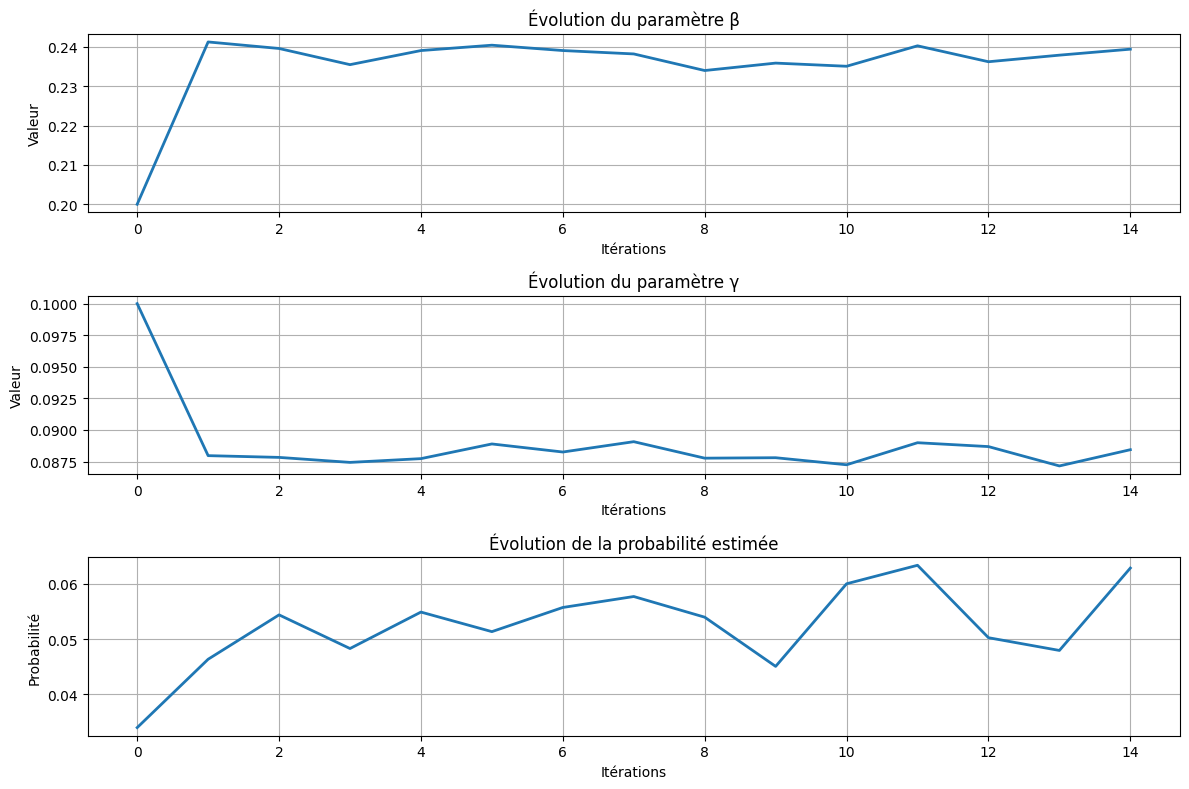

In [ ]:
def proba_ce_IS_historique(S0, I0, N, beta, gamma, seuil, M=1000, K=10, M_final=1000, eps=5e-3):
    beta_prop = beta
    gamma_prop = gamma
    historique = {
        'beta': [],
        'gamma': [],
        'estimations': []
    }

    for k in range(K):
        ### Génération des trajectoires
        trajectoires = []
        for _ in range(M):
            traj = simuler_trajectoire_continue(S0, I0, N, beta, gamma, beta_prop, gamma_prop, seuil)
            trajectoires.append(traj)

        ### Calcul estimation courante
        estimation = np.mean([t['succes'] * t['phi'] for t in trajectoires])
        historique['estimations'].append(estimation)
        historique['beta'].append(beta_prop)
        historique['gamma'].append(gamma_prop)

        ### Sélection des élites
        elites = [t for t in trajectoires if t['succes']]
        if not elites:
            beta_prop = max(beta_prop * 1.1, eps)
            gamma_prop = max(gamma_prop * 0.9, eps)
            continue

        ### Mise à jour des paramètres
        poids = np.array([t['phi'] for t in elites])
        poids /= np.sum(poids) if np.sum(poids) != 0 else 1.0/len(poids)

        total_infections = sum(t['infections'] * w for t, w in zip(elites, poids))
        total_guerisons = sum(t['guerisons'] * w for t, w in zip(elites, poids))
        total_int_beta = sum(t['integrale_beta'] * w for t, w in zip(elites, poids))
        total_int_gamma = sum(t['integrale_gamma'] * w for t, w in zip(elites, poids))

        beta_prop = total_infections / total_int_beta if total_int_beta > 0 else beta_prop
        gamma_prop = total_guerisons / total_int_gamma if total_int_gamma > 0 else gamma_prop
        beta_prop = max(beta_prop, eps)
        gamma_prop = max(gamma_prop, eps)

    ### Estimation finale
    final = np.mean([simuler_trajectoire_continue(S0, I0, N, beta, gamma, beta_prop, gamma_prop, seuil)['succes'] *
                    simuler_trajectoire_continue(S0, I0, N, beta, gamma, beta_prop, gamma_prop, seuil)['phi']
                    for _ in range(M_final)])
    historique['estimations'].append(final)

    return historique

######################################## Paramètres initiaux
S0 = 80
I0 = 10
N = 100
beta = 0.2
gamma = 0.1
seuil = 80

# Exécution de l'algorithme
historique = proba_ce_IS_historique(S0, I0, N, beta, gamma, seuil, M=500, K=15)

# Visualisation
plt.figure(figsize=(12, 8))

# Évolution de beta
plt.subplot(3, 1, 1)
plt.plot(historique['beta'], linewidth=2)
plt.title('Évolution du paramètre β')
plt.xlabel('Itérations')
plt.ylabel('Valeur')
plt.grid(True)

# Évolution de gamma
plt.subplot(3, 1, 2)
plt.plot(historique['gamma'], linewidth=2)
plt.title('Évolution du paramètre γ')
plt.xlabel('Itérations')
plt.ylabel('Valeur')
plt.grid(True)

# Évolution de la probabilité estimée
plt.subplot(3, 1, 3)
plt.plot(historique['estimations'][:-1], linewidth=2)
plt.title('Évolution de la probabilité estimée')
plt.xlabel('Itérations')
plt.ylabel('Probabilité')
plt.grid(True)

plt.tight_layout()
plt.show()

On remarque que le CE permet bien d'optimiser les paramètres de l'IS de façon à ce que la probabilité étimée converge .
On note qu'elle oscille toujourt avec un écart de 0.02 pour une probabilité de 0.055 mais donc il faut augmenter le paramètre M pour stabiliser les résultats.

# Implémentation IBPS

##  Algorithme IBPS (Interacting Branching Particle System)

L’algorithme `proba_IBPS` utilise un système de particules interagissantes pour estimer la probabilité de notre événement rare.

Chaque **particule** correspond à une trajectoire SIR simulée via la classe `Particule`.


###  Algorithme IBPS

L’algorithme `proba_IBPS` fonctionne selon les étapes suivantes :

### Étapes :

**1. Initialisation**  
On simule $ N $ trajectoires complètes indépendantes.

**2. Définition des seuils intermédiaires**  
On crée $ K + 1 $ seuils de l’état de guérison $ R $, uniformément espacés entre l’état initial et le seuil final :

$$
\text{Seuils} = \left\{ R_0, R_1, \ldots, R_K \right\}, \quad R_K = \text{seuil}
$$



**3. Pour chaque étape $k = 0, \ldots, K $** :

#### a. Sélection  
On garde les particules telles que $R \geq R_k $.  
Si aucune particule n’est sélectionnée, on relance l’algorithme (éviter probabilité nulle).
#### c. Mise à jour de la probabilité  
La probabilité de sélection est :

$$
p_k = \frac{\text{nombre de particules sélectionnées}}{\text{nombre total de particules}}
$$


#### b. Mutation  
Les particules non sélectionnées sont remplacées :

- On choisit une particule sélectionnée
- On trouve le moment où elle atteint $ R \geq R_k $
- On coupe sa trajectoire à cet instant
- On reprend la simulation à partir de ce point avec les mêmes paramètres

###  Estimation finale

L’estimation de la probabilité rare est :

$$
\hat{p} = \prod_{k=0}^{K} p_k
$$

où chaque $ p_k $ est la proportion de particules atteignant le seuil $ R_k $ à l’étape $ k $.





In [ ]:
class Particule:
    def __init__(self, S0, N, gamma, beta, R0=0):
        self.S = S0
        self.R = R0
        self.I = N - S0 - R0
        self.N = N
        self.gamma = gamma
        self.beta = beta
        self.trajectoire = [[self.S, self.I, self.R]]
        self.temps = [0.0]
        self.I_max = self.I

    def simuler_complet(self):

        while self.I > 0:
            t1 = (self.beta * self.S * self.I) / self.N
            t2 = self.gamma * self.I
            taux_total = t1 + t2

            if taux_total <= 0:
                break

            T = np.random.exponential(1 / taux_total)
            nouveau_temps = self.temps[-1] + T
            proba_infection = t1 / taux_total

            if np.random.rand() <= proba_infection:
                self.S -= 1
                self.I += 1
            else:
                self.I -= 1
                self.R += 1

            # Mettre à jour I_max si nécessaire
            if self.I > self.I_max:
                self.I_max = self.I

            self.trajectoire.append([self.S, self.I, self.R])
            self.temps.append(nouveau_temps)

        return self

    @classmethod
    def continuer_construction(cls, particule, index):
        ### Créer une nouvelle particule avec les états actuels
        S, I, R = particule.trajectoire[index]
        nouvelle_particule = cls(S, particule.N, particule.gamma, particule.beta, R0=R)

        ### Copier l'historique jusqu'au point spécifié
        nouvelle_particule.trajectoire = particule.trajectoire[:index+1].copy()
        nouvelle_particule.temps = particule.temps[:index+1].copy()
        nouvelle_particule.I = I
        nouvelle_particule.I_max = max([traj[1] for traj in nouvelle_particule.trajectoire])

        return nouvelle_particule

def proba_IBPS(S0, I0, N, beta, gamma, seuil, nbr_trajectoires=1000, K=40):
    # Initialiser les particules
    particules = []
    for _ in range(nbr_trajectoires):
        p = Particule(S0, N, gamma, beta, R0=0)
        p.simuler_complet()
        particules.append(p)

    seuils = np.linspace(I0, seuil, K + 1)
    proba_selection = [1.0]  ### Probabilité de sélection initiale

    for k in range(K + 1):
        seuil_courant = seuils[k]

        # Étape 1 : Sélection
        indices_selectionnés = []
        for i, p in enumerate(particules):
            if p.trajectoire[-1][2] >= seuil_courant:
                indices_selectionnés.append(i)

        if not indices_selectionnés:
            # Relancer si aucune particule n’est sélectionnée
            return proba_IBPS(S0, I0, N, beta, gamma, seuil, nbr_trajectoires, K)

        # Étape 2 : Mutation
        non_selectionnés = [i for i in range(nbr_trajectoires) if i not in indices_selectionnés]
        for i in non_selectionnés:
            idx_sel = np.random.choice(indices_selectionnés)
            particule_sel = particules[idx_sel]

            crossing_idx = None
            for idx, etat in enumerate(particule_sel.trajectoire):
                if etat[2] >= seuil_courant:
                    crossing_idx = idx
                    break

            if crossing_idx is None:
                crossing_idx = -1

            nouvelle_particule = Particule.continuer_construction(
    particule_sel,
    crossing_idx
)
            nouvelle_particule.simuler_complet()

            ### Remplacer la particule non sélectionnée
            particules[i] = nouvelle_particule

        # Étape 3 : Mise à jour des probabilités
        proba_selection.append(len(indices_selectionnés) / nbr_trajectoires)

    return np.prod(proba_selection)


##1.b) Comparaison des trois méthodes

In [ ]:
from scipy.optimize import fsolve
### Équation implicite pour S_inf
def equation_S_inf(S_inf, S_0, R_0, N):
    return S_inf - S_0 * np.exp(R_0 * (S_inf / N - 1))

In [ ]:
################################################  Paramètre #############################
N = 100
S_0 = 97
I_0 = 3
gamma = 0.1
beta = 0.2
R_0 = beta/gamma
guess = S_0 / 2
S_inf_solution = fsolve(equation_S_inf, guess, args=(S_0, R_0, N))[0]
R_inf = (N-S_inf_solution)
Seuil = R_inf+ 5

print('Les paramètres'+'N = '+str(100)+',S_0 = '+str(S_0)+',I_0 = '+str(I_0)+',R_0 ='+str(beta/gamma)+',gamma = '+str(gamma)+',beta = '+str(beta)+',Seuil='+str(Seuil))

### Calcul du nouveau rapport beta/gamma pour que Rinfini dépasse le seuil

R0_new = np.log((N - Seuil ) / S_0) / ((S_inf_solution / N) - 1)


Les paramètresN = 100,S_0 = 97,I_0 = 3,R_0 =2.0,gamma = 0.1,beta = 0.2,Seuil=85.68093983795364


## Probabilité de $10^{-1}$

Calcul des probabilités: 100%|██████████| 100/100 [27:13<00:00, 16.34s/it]
<ipython-input-26-b8af14c4f196>:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(Stock, positions=range(1, 6),


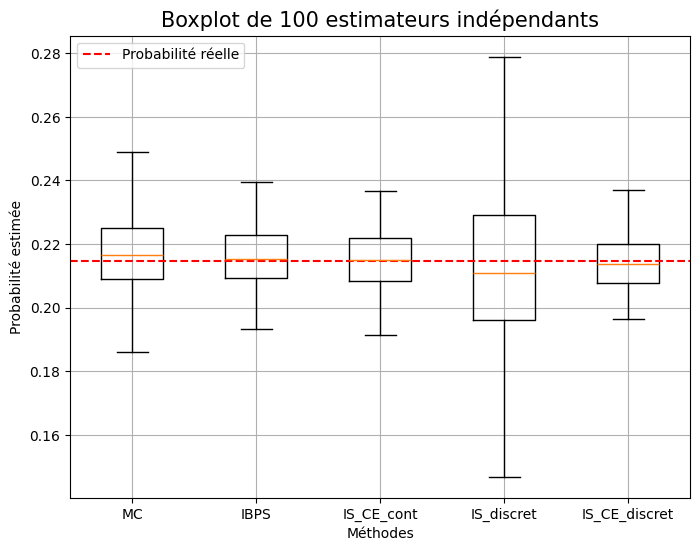

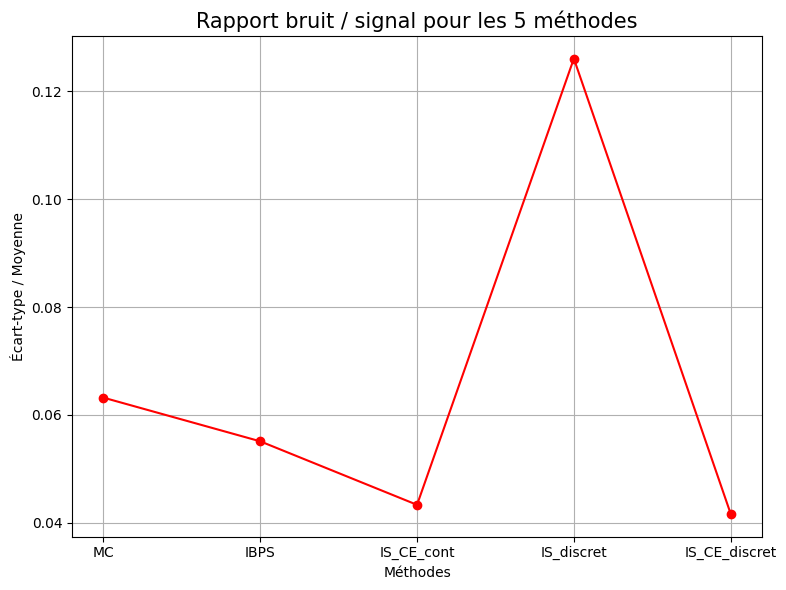

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

NbrIter = 100
Stock = np.zeros((NbrIter, 5))  # 5 estimateurs
M = 100

for nn in tqdm(range(NbrIter), desc="Calcul des probabilités"):
    Stock[nn, 0] = proba_MonteCarlo(S_0, N, beta, gamma, Seuil, 10*M)
    Stock[nn, 1] = proba_IBPS(S_0, I_0, N, beta, gamma, Seuil, 10*M, K=80)
    Stock[nn, 2] = proba_ce_IS(simuler_trajectoire_continue, S_0, I_0, N, beta, gamma, Seuil)
    Stock[nn, 3] = proba_IS_discret(S_0, I_0, N, beta, gamma, gamma*R0_new, gamma, Seuil, M)
    Stock[nn, 4] = proba_ce_IS(simuler_trajectoire_discret, S_0, I_0, N, beta, gamma, Seuil)

Proba = proba_MonteCarlo(S_0, N, beta, gamma, Seuil, 1_000_000)
# Boxplot des estimateurs
plt.figure(figsize=(8, 6))
plt.boxplot(Stock, positions=range(1, 6),
            labels=['MC', 'IBPS', 'IS_CE_cont', 'IS_discret', 'IS_CE_discret'],
            showfliers=False)
plt.title(f"Boxplot de {NbrIter} estimateurs indépendants", fontsize=15)
plt.axhline(y=Proba, color='r', linestyle='--', label='Probabilité réelle')
plt.legend()
plt.ylabel("Probabilité estimée")
plt.xlabel("Méthodes")
plt.grid()

# Rapport bruit / signal
mean_stock = Proba
st_dev = np.std(Stock, axis=0)
bruit_signal = st_dev / mean_stock

plt.figure(figsize=(8, 6))
plt.plot(range(1, 6), bruit_signal, 'r-o')
plt.xticks(range(1, 6), ['MC', 'IBPS', 'IS_CE_cont', 'IS_discret', 'IS_CE_discret'])
plt.title("Rapport bruit / signal pour les 5 méthodes", fontsize=15)
plt.ylabel("Écart-type / Moyenne")
plt.xlabel("Méthodes")
plt.grid()
plt.tight_layout()
plt.show()

Pour l'odre $10^{-1}$, les trois méthodes marchent parfaitement, l'IS sans tuning de paramétre à sinon une grande variance ce qui justifie l'imporatance de la méthode Cross-Entropy



## Probabilité de $10^{-2}$

In [ ]:
######################## Paramètres ###########################################
N = 100
S_0 = 80
I_0 = 20
gamma = 0.1
beta = 0.1
guess = S_0 / 2
R_0 = beta/gamma
S_inf_solution = fsolve(equation_S_inf, guess, args=(S_0, R_0, N))[0]
NbrIter = 100
#  definition du seuil
M=100
R_inf = N-S_inf_solution
Seuil = R_inf + 20
print(f'Seuil: {Seuil}')
Stock = np.zeros((NbrIter, 5))
R0_new = np.log((N - Seuil ) / S_0) / ((S_inf_solution / N) - 1)

Seuil: 72.83280902564783


Calcul des probabilités: 100%|██████████| 100/100 [18:24<00:00, 11.04s/it]
<ipython-input-28-c2a04903614f>:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(Stock[:, 0:5], positions=[1,2,3,4,5],


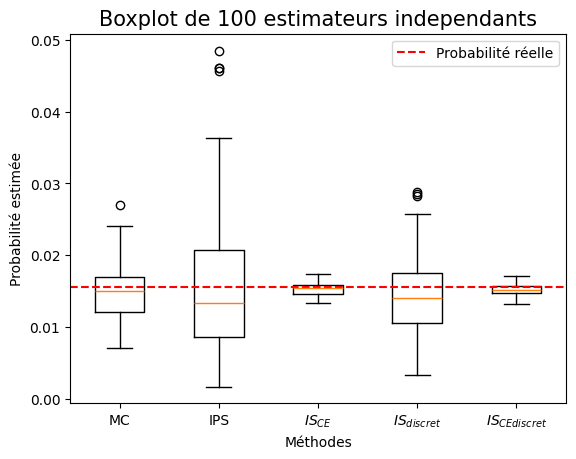

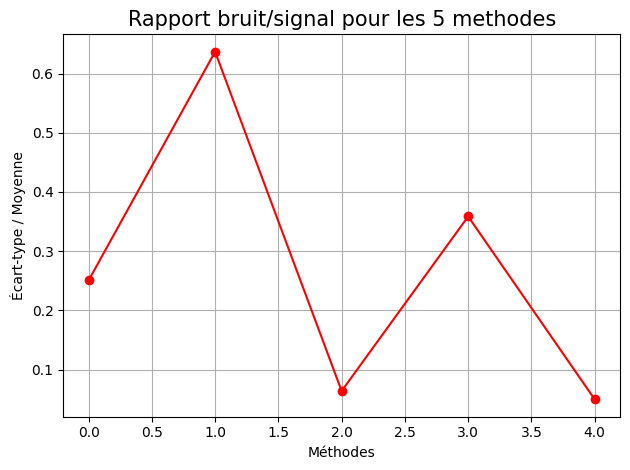

In [ ]:


for nn in tqdm(range(NbrIter), desc="Calcul des probabilités"):

    Stock[nn, 0] = proba_MonteCarlo(S_0,N,beta,gamma,Seuil,10*M)
    Stock[nn, 1] = proba_IBPS(S_0,I_0,N,beta,gamma,Seuil,M,K=80)
    Stock[nn, 2] = proba_ce_IS(simuler_trajectoire_continue,S_0 ,I_0,N,beta, gamma,Seuil)
    Stock[nn, 3] = proba_IS_discret(S_0,I_0,N,beta,gamma,gamma*R0_new,gamma,Seuil,M)
    Stock[nn, 4] = proba_ce_IS(simuler_trajectoire_discret,S_0 ,I_0,N,beta, gamma,Seuil)

Proba = proba_MonteCarlo(S_0,N,beta,gamma,Seuil,1_000_000)

# Boxplot des estimateurs
# Tracer les boxplots de chaque estimateur
plt.title("Boxplot de " + str(NbrIter) +" estimateurs independants", fontsize=15)
plt.boxplot(Stock[:, 0:5], positions=[1,2,3,4,5],
            labels = ['MC','IPS','$IS_{CE}$' ,'$IS_{discret}$', '$IS_{CE discret}$'])
plt.axhline(y=Proba, color='r', linestyle='--', label='Probabilité réelle')
plt.legend()
plt.ylabel("Probabilité estimée")
plt.xlabel("Méthodes")
plt.figure()

# Comparer l' "ecart-type / valeur moyenne" des trois estimateurs
mean_stock = Proba


st_dev = np.std(Stock, axis=0)

plt.plot(st_dev/mean_stock,'r-o')
plt.title("Rapport bruit/signal pour les 5 methodes", fontsize=15)
plt.ylabel("Écart-type / Moyenne")
plt.xlabel("Méthodes")
plt.grid()
plt.tight_layout()
plt.show()

Pour l'odre $10^{-2}$, les trois méthodes marchent parfaitement, l'IBPS par contre a sinon une grande variance, réduisant donc son efficacité.



## Probabilité de $10^{-4}$

In [ ]:
########################### Paramètre de l'épidémie ################################
N = 100
S_0 = 80
I_0 = 20
gamma = 0.1
beta = 0.1


def s_inf(s_0,R_0):
  i_0=1-s_0
  def f(x):
    return (i_0 + s_0 - x + np.log(x/s_0)/R_0)
  return fsolve(f,1/(2*R_0))[0]

#Paramètre de l'épidémie
N = 100
S_0 = 80
I_0 = 20
gamma = 0.1
beta = 0.1
print('Les paramètres'+'N = '+str(100)+',S_0 = '+str(80)+',I_0 = '+str(20)+',R_0 ='+str(beta/gamma)+',gamma = '+str(0.1)+',beta = '+str(0.1))


#  definition du seuil
delta = 0.25*N
R_inf = (1-s_inf(S_0/N,beta/gamma))*N
Seuil = R_inf + delta+6
print(f'Seuil: {Seuil}')

NbrIter = 100
Stock = np.zeros((NbrIter, 4))
M = 100
R0_new = np.log((N - Seuil) / S_0) / ((S_inf_solution / N) - 1)

Les paramètresN = 100,S_0 = 80,I_0 = 20,R_0 =1.0,gamma = 0.1,beta = 0.1
Seuil: 83.83280902564782


Calcul des probabilités: 100%|██████████| 100/100 [14:01<00:00,  8.41s/it]
<ipython-input-30-38a5641737bf>:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(Stock[:, 0:4], positions=[1,2,3,4],


<Figure size 640x480 with 0 Axes>

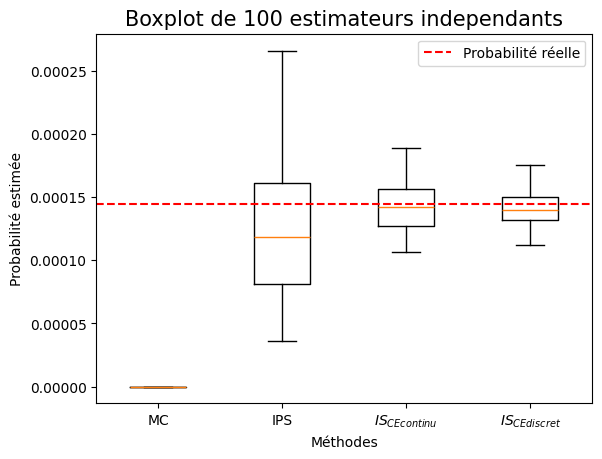

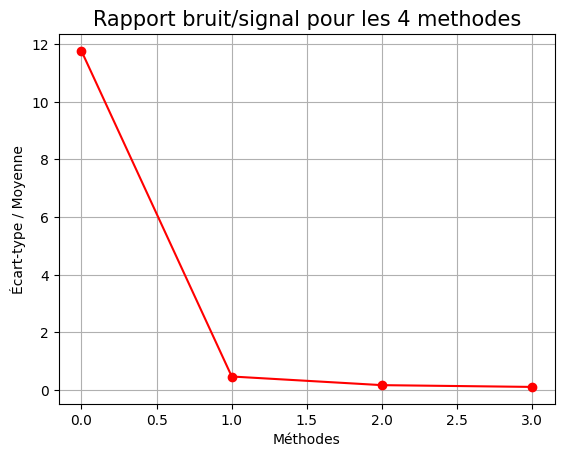

<Figure size 640x480 with 0 Axes>

In [ ]:
for nn in tqdm(range(NbrIter), desc="Calcul des probabilités"):
    Stock[nn, 0] = proba_MonteCarlo(S_0,N,beta,gamma,Seuil,M)
    Stock[nn, 1] = proba_IBPS(S_0,I_0,N,beta,gamma, Seuil, 2000,K=80)
    Stock[nn, 2] = proba_ce_IS(simuler_trajectoire_continue,S_0 ,I_0,N,beta, gamma,Seuil,M)
    Stock[nn, 3] = proba_ce_IS(simuler_trajectoire_discret,S_0 ,I_0,N,beta, gamma,Seuil,M)



Proba = proba_MonteCarlo(S_0,N,beta,gamma,Seuil,1_000_000)

# Boxplot des estimateurs
# Tracer les boxplots de chaque estimateur
plt.title("Boxplot de " + str(NbrIter) +" estimateurs independants", fontsize=15)
plt.boxplot(Stock[:, 0:4], positions=[1,2,3,4],
            labels = ['MC','IPS','$IS_{CE continu}$' , '$IS_{CE discret}$'],
            showfliers= False
            )
plt.axhline(y=Proba, color='r', linestyle='--', label='Probabilité réelle')
plt.legend()
plt.ylabel("Probabilité estimée")
plt.xlabel("Méthodes")
plt.figure()

# Comparer l' "ecart-type / valeur moyenne" des trois estimateurs
mean_stock = Proba


st_dev = np.std(Stock, axis=0)

plt.plot(st_dev/mean_stock,'r-o')
plt.title("Rapport bruit/signal pour les 4 methodes", fontsize=15)
plt.ylabel("Écart-type / Moyenne")
plt.xlabel("Méthodes")
plt.grid()
plt.figure()

Pour l'odre $10^{-1}$, les trois méthodes marchent parfaitement, l'$IS_{CE}$ se démarque par sa précision par rapport à l'IBPS.



## La vrai probabilité pour vérification

## Probabilité de $10^{-6}$

In [ ]:
#Paramètre de l'épidémie
N = 100
S_0 = 80
I_0 = 20
gamma = 0.1
beta = 0.1


def s_inf(s_0,R_0):
  i_0=1-s_0
  def f(x):
    return (i_0 + s_0 - x + np.log(x/s_0)/R_0)
  return fsolve(f,1/(2*R_0))[0]

#Paramètre de l'épidémie
N = 100
S_0 = 80
I_0 = 20
gamma = 0.1
beta = 0.1

print('Les paramètres'+'N = '+str(100)+',S_0 = '+str(80)+',I_0 = '+str(20)+',R_0 ='+str(beta/gamma)+',gamma = '+str(0.1)+',beta = '+str(0.1))
#  definition du seuil
#  definition du seuil
delta = 0.25*N
R_inf = (1-s_inf(S_0/N,beta/gamma))*N
Seuil = R_inf + delta+12
print(f'Seuil: {Seuil}')

NbrIter = 30
Stock = np.zeros((NbrIter, 6))
M =100


Les paramètresN = 100,S_0 = 80,I_0 = 20,R_0 =1.0,gamma = 0.1,beta = 0.1
Seuil: 89.83280902564782


In [ ]:
for nn in range(NbrIter):
    Stock[nn, 0] = proba_MonteCarlo(S_0,N,beta,gamma,Seuil,M)
    Stock[nn, 1] = proba_IBPS(S_0,I_0,N,beta,gamma, Seuil, 100,K=20)
    Stock[nn, 2] = proba_IS_continue(S_0,I_0,N,beta,gamma,gamma*R0_new,gamma,Seuil,M)
    Stock[nn, 3] = proba_ce_IS(simuler_trajectoire_continue,S_0 ,I_0,N,beta, gamma,Seuil,M)
    Stock[nn, 4] = proba_IS_discret(S_0,I_0,N,beta,gamma,gamma*R0_new,gamma,Seuil,M)
    Stock[nn, 5] = proba_ce_IS(simuler_trajectoire_discret,S_0 ,I_0,N,beta, gamma,Seuil,M)


Proba = proba_MonteCarlo(S_0,N,beta,gamma,Seuil,100_000_000)

# Boxplot des estimateurs

# Tracer les boxplots de chaque estimateur
plt.title("Boxplot de " + str(NbrIter) +" estimateurs independants", fontsize=15)
plt.boxplot(Stock[:, 0:6], positions=[1,2,3,4,5,6],
            labels = ['MC','IPS','$IS_{continue}$','$IS_{CE}$' ,'$IS_{discret}$', '$IS_{CE discret}$'],)
plt.axhline(y=Proba, color='r', linestyle='--', label='Probabilité réelle')
plt.legend()
plt.ylabel("Probabilité estimée")
plt.xlabel("Méthodes")
plt.figure()

# Comparer l' "ecart-type / valeur moyenne" des trois estimateurs
mean_stock = Proba


st_dev = np.std(Stock, axis=0)

plt.plot(st_dev/mean_stock,'r-o')
plt.title("Rapport bruit/signal pour les 3 methodes", fontsize=15)
plt.grid()
plt.figure()

<ipython-input-33-2443dd5b28d5>:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(Stock[:, 0:6], positions=[1,2,3,4,5,6],


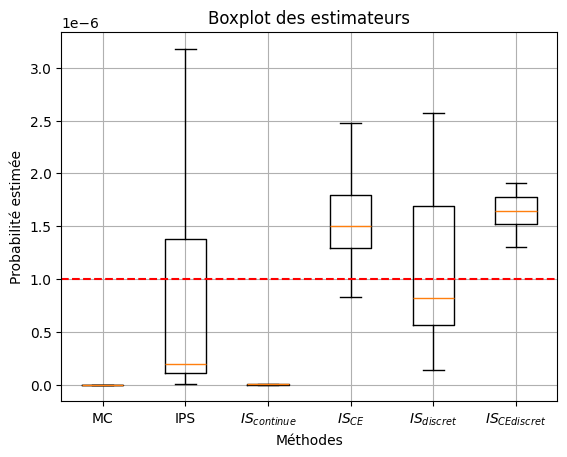

In [ ]:
plt.boxplot(Stock[:, 0:6], positions=[1,2,3,4,5,6],
            labels=['MC','IPS','$IS_{continue}$','$IS_{CE}$' ,'$IS_{discret}$', '$IS_{CE discret}$'],
            showfliers=False)  # Supprimer les outliers visuellement
plt.axhline(y=Proba, color='r', linestyle='--', label='Probabilité réelle')
plt.xlabel("Méthodes")
plt.ylabel("Probabilité estimée")
plt.title("Boxplot des estimateurs")
plt.yscale('linear')  # Tu peux aussi essayer 'log' ici si les valeurs sont très petites
plt.grid(True)
plt.show()

À $10^{-6}$ on remarque que seul l'IS reste performant.

## La vraie probabilité pour vérification

In [ ]:
p=proba_MonteCarlo(S_0,N,beta,gamma,Seuil,1000000)
print(p)

2e-06


### $10^{-8}$

In [ ]:
#Paramètre de l'épidémie
N = 100
S_0 = 80
I_0 = 20
gamma = 0.1
beta = 0.1

print('Les paramètres'+'N = '+str(100)+',S_0 = '+str(80)+',I_0 = '+str(20)+',R_0 ='+str(beta/gamma)+',gamma = '+str(0.1)+',beta = '+str(0.1))
#  definition du seuil
#  definition du seuil
delta = 0.25*N
R_inf = (1-s_inf(S_0/N,beta/gamma))*N
Seuil = R_inf + delta+12
print(f'Seuil: {Seuil}')

NbrIter = 30
Stock = np.zeros((NbrIter, 6))
M =100

In [ ]:
for nn in range(NbrIter):
    Stock[nn, 0] = proba_MonteCarlo(S_0,N,beta,gamma,Seuil,M)
    Stock[nn, 1] = proba_IBPS(S_0,I_0,N,beta,gamma, Seuil, 100,K=20)
    Stock[nn, 2] = proba_IS_continue(S_0,I_0,N,beta,gamma,gamma*R0_new,gamma,Seuil,M)
    Stock[nn, 3] = proba_ce_IS(simuler_trajectoire_continue,S_0 ,I_0,N,beta, gamma,Seuil,M)
    Stock[nn, 4] = proba_IS_discret(S_0,I_0,N,beta,gamma,gamma*R0_new,gamma,Seuil,M)
    Stock[nn, 5] = proba_ce_IS(simuler_trajectoire_discret,S_0 ,I_0,N,beta, gamma,Seuil,M)


Proba = proba_MonteCarlo(S_0,N,beta,gamma,Seuil,100_000_000)

# Boxplot des estimateurs

# Tracer les boxplots de chaque estimateur
plt.title("Boxplot de " + str(NbrIter) +" estimateurs independants", fontsize=15)
plt.boxplot(Stock[:, 0:6], positions=[1,2,3,4,5,6],
            labels = ['MC','IPS','$IS_{continue}$','$IS_{CE}$' ,'$IS_{discret}$', '$IS_{CE discret}$'],)
plt.axhline(y=Proba, color='r', linestyle='--', label='Probabilité réelle')
plt.legend()
plt.ylabel("Probabilité estimée")
plt.xlabel("Méthodes")
plt.figure()

# Comparer l' "ecart-type / valeur moyenne" des trois estimateurs
mean_stock = Proba


st_dev = np.std(Stock, axis=0)

plt.plot(st_dev/mean_stock,'r-o')
plt.title("Rapport bruit/signal pour les 3 methodes", fontsize=15)
plt.grid()
plt.figure()

<ipython-input-35-20f84ea39919>:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(Stock[:, 0:6], positions=[1,2,3,4,5,6],


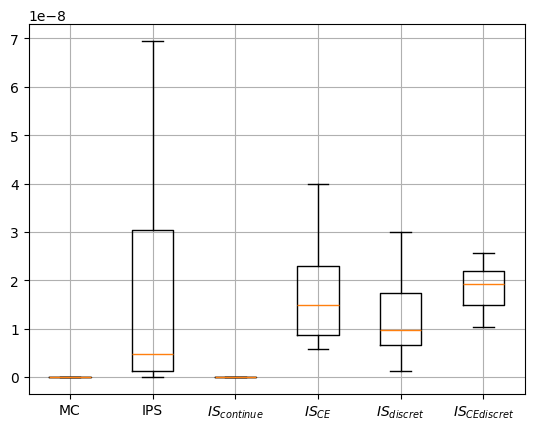

In [ ]:
plt.boxplot(Stock[:, 0:6], positions=[1,2,3,4,5,6],
            labels=['MC','IPS','$IS_{continue}$','$IS_{CE}$' ,'$IS_{discret}$', '$IS_{CE discret}$'],
            showfliers=False)  # Supprimer les outliers visuellement
plt.yscale('linear')  # Tu peux aussi essayer 'log' ici si les valeurs sont très petites
plt.grid(True)
plt.show()

Même remarque ici.

## Probabilité de $10^{-6}$ pour comparaison des meilleures méthodes à savoir les IS avec CE pour le choix des paramètres

In [ ]:
#Paramètre de l'épidémie
N = 100
S_0 = 80
I_0 = 20
gamma = 0.1
beta = 0.1


def s_inf(s_0,R_0):
  i_0=1-s_0
  def f(x):
    return (i_0 + s_0 - x + np.log(x/s_0)/R_0)
  return fsolve(f,1/(2*R_0))[0]

#Paramètre de l'épidémie
N = 100
S_0 = 80
I_0 = 20
gamma = 0.1
beta = 0.1

print('Les paramètres'+'N = '+str(100)+',S_0 = '+str(80)+',I_0 = '+str(20)+',R_0 ='+str(beta/gamma)+',gamma = '+str(0.1)+',beta = '+str(0.1))
#  definition du seuil
delta = 0.25*N
R_inf = (1-s_inf(S_0/N,beta/gamma))*N
Seuil = R_inf + delta+12
print(f'Seuil: {Seuil}')

####################### Paramètres pour les simulations ########################
NbrIter = 100
M = 100
Stock = np.zeros((NbrIter, 3))

Les paramètresN = 100,S_0 = 80,I_0 = 20,R_0 =1.0,gamma = 0.1,beta = 0.1
Seuil: 89.83280902564782


Calcul des probabilités: 100%|██████████| 100/100 [05:32<00:00,  3.32s/it]
<ipython-input-27-c018574aeb52>:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(Stock[:, :3], positions=[1, 2, 3],
<ipython-input-27-c018574aeb52>:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


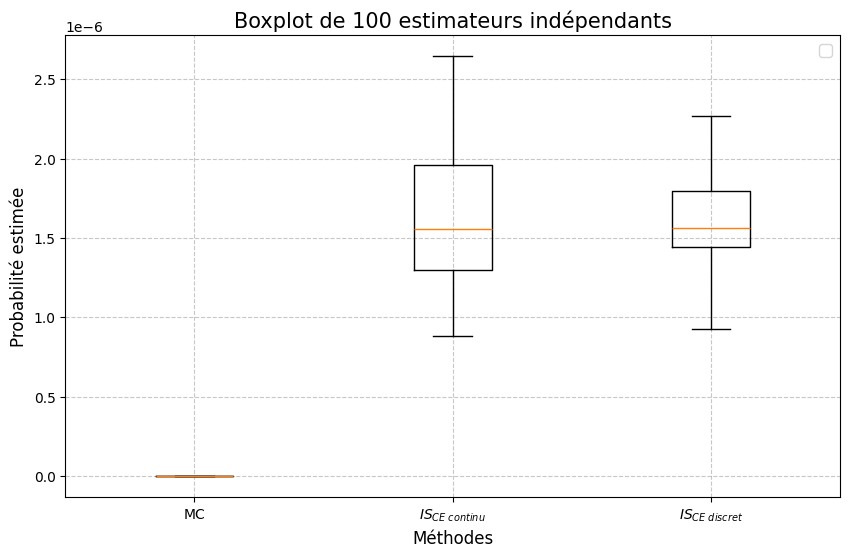

<ipython-input-27-c018574aeb52>:27: RuntimeWarning: invalid value encountered in divide
  plt.plot([1, 2, 3], st_dev / mean_estimates, 'r-o', markersize=8)


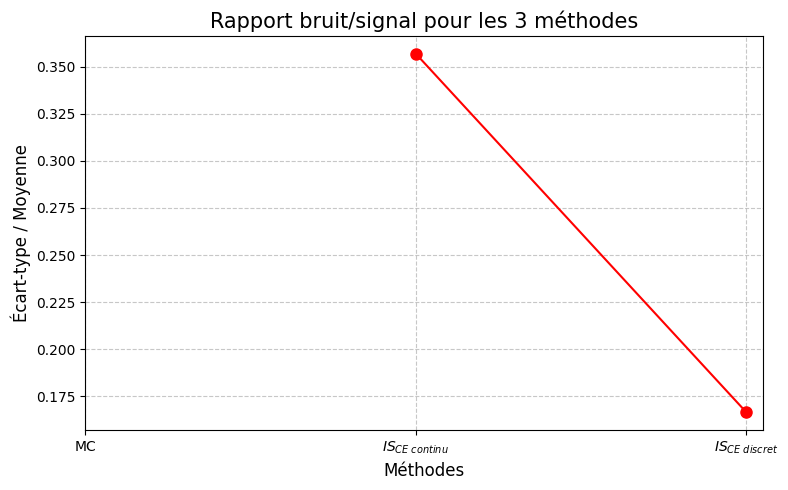

In [ ]:
# Simulation
for nn in tqdm(range(NbrIter), desc="Calcul des probabilités"):
    Stock[nn, 0] = proba_MonteCarlo(S_0, N, beta, gamma, Seuil, M)
    Stock[nn, 1] = proba_ce_IS(simuler_trajectoire_continue, S_0, I_0, N, beta, gamma, Seuil, M)
    Stock[nn, 2] = proba_ce_IS(simuler_trajectoire_discret, S_0, I_0, N, beta, gamma, Seuil, M)

# Calcul de la probabilité réelle avec une grande précision
Proba = proba_MonteCarlo(S_0, N, beta, gamma, Seuil, 1_000_000)

# Tracer les boxplots des estimateurs
plt.figure(figsize=(10, 6))
plt.boxplot(Stock[:, :3], positions=[1, 2, 3],
            labels=['MC', '$IS_{CE\\ continu}$', '$IS_{CE\\ discret}$'],
            showfliers=False)
plt.legend(fontsize=12)
plt.title(f"Boxplot de {NbrIter} estimateurs indépendants", fontsize=15)
plt.ylabel("Probabilité estimée", fontsize=12)
plt.xlabel("Méthodes", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Comparer le rapport écart-type / moyenne des estimateurs
mean_estimates = np.mean(Stock, axis=0)[:3]
st_dev = np.std(Stock, axis=0)[:3]

plt.figure(figsize=(8, 5))
plt.plot([1, 2, 3], st_dev / mean_estimates, 'r-o', markersize=8)
plt.title("Rapport bruit/signal pour les 3 méthodes", fontsize=15)
plt.ylabel("Écart-type / Moyenne", fontsize=12)
plt.xticks([1, 2, 3], ['MC', '$IS_{CE\\ continu}$', '$IS_{CE\\ discret}$'], fontsize=10)
plt.xlabel("Méthodes", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Conclusions:

*    Parmi l’ensemble des méthodes testées, la version discrète de l’Importance Sampling couplée à l’algorithme de \textit{Cross-Entropy} s’est révélée être la plus performante. Elle a permis d’obtenir les estimations les plus précises, même dans le cadre de probabilités très faibles.

*    Cette étude nous a également permis de prendre conscience que l’efficacité des méthodes de simulation repose avant tout sur la qualité de la modélisation et le choix judicieux des paramètres. L’idée de discrétiser le processus et d’optimiser les paramètres via l’algorithme de **Cross-Entropy** s’est révélée particulièrement efficace. À l’inverse, dans les méthodes de type Splitting, l’utilisation de niveaux équidistants, bien que simple à implémenter, nous a semblé moins adaptée et pourrait être améliorée par des stratégies de sélection plus fines et adaptées à la dynamique du processus.




#Partie 3: Extensions de notre project N°1:
##Étude de: $$ P(I_{max} > K) $$


##Implémentation Monte Carlo Naïf

In [ ]:
def proba_MonteCarlo_v2(S_0,N,beta,gamma,Seuil,M) :
  I=[]
  # Lance l'evolution stochastique M fois et calcule la moyenne
  for k in range (M):
    I_max= np.max(simulation_stochastique(S_0,N,gamma,beta)[1][:,1])
    I.append(I_max)

  return np.mean(np.array(I)>Seuil)


In [ ]:
def simul_traject_Imax(S0, I0, N, beta_orig, gamma_orig, beta_prop, gamma_prop, Seuil):
    S, I, R = S0, I0, 0
    I_max = I0  # Valeur initiale du maximum d'infectés
    phi = 1.0   # Rapport de vraisemblance (original / proposition)
    infections = 0
    guerisons = 0
    integrale_beta = 0.0   # Intégrale de S*I/N au fil du temps
    integrale_gamma = 0.0  # Intégrale de I au fil du temps
    temps_precedent = 0.0

    while I > 0:
        S_I_sur_N = S * I / N
        I_courant = I
        taux_infection = beta_prop * S_I_sur_N
        taux_guerison = gamma_prop * I_courant
        taux_total = taux_infection + taux_guerison

        if taux_total <= 0:
            break  # Éviter une division par zéro

        # Temps jusqu'au prochain événement
        T = np.random.exponential(1 / taux_total)
        temps_courant = temps_precedent + T

        # Mise à jour des intégrales pour beta et gamma
        integrale_beta += S_I_sur_N * T
        integrale_gamma += I_courant * T

        # Ajuste le rapport de vraisemblance phi
        taux_infection_original = beta_orig * S_I_sur_N
        taux_guerison_original = gamma_orig * I_courant
        phi *= np.exp(-T * (taux_infection_original + taux_guerison_original - taux_infection - taux_guerison))

        # Détermine le type d'événement
        if np.random.rand() < (taux_infection / taux_total):
            # Événement d'infection
            S -= 1
            I += 1
            infections += 1
            phi *= (beta_orig / beta_prop)
            # Met à jour I_max si nécessaire
            I_max = max(I_max, I)
        else:
            # Événement de guérison
            I -= 1
            R += 1
            guerisons += 1
            phi *= (gamma_orig / gamma_prop)

        temps_precedent = temps_courant

    succes = I_max > Seuil
    return {
        'succes': succes,
        'phi': phi,
        'infections': infections,
        'guerisons': guerisons,
        'integrale_beta': integrale_beta,
        'integrale_gamma': integrale_gamma,
        'I_max': I_max
    }

def proba_ce_IS_Imax(S0, I0, N, beta, gamma, Seuil, M=1000, K=10):

    # Initialisation des paramètres de proposition avec les valeurs originales
    beta_prop = beta
    gamma_prop = gamma

    for k in range(K):

        # Étape 1 : Génère M échantillons avec les paramètres de proposition actuels
        trajectoires = []
        for _ in range(M):
            traj = simul_traject_Imax(S0, I0, N, beta, gamma, beta_prop, gamma_prop, Seuil)
            trajectoires.append(traj)

        # Étape 2 : Sélectionne les échantillons élites (trajectoires réussies)
        elites = [t for t in trajectoires if t['succes']]
        nombre_succes = len(elites)

        if nombre_succes < 10:  # Trop peu d'élites pour une optimisation fiable
            # Augmente beta et/ou diminue gamma pour favoriser plus d'infections
            beta_prop = min(beta_prop * 1.2, 10 * beta)  # Limite l'augmentation
            gamma_prop = max(gamma_prop * 0.8, 0.1 * gamma)  # Limite la diminution

            continue

        # Étape 3 : Calcule les poids (rapports de vraisemblance normalisés)
        poids = np.array([t['phi'] for t in elites])
        somme_poids = np.sum(poids)
        if somme_poids == 0:
            poids = np.ones(len(elites)) / len(elites)  # Poids uniformes si tous sont nuls
        else:
            poids /= somme_poids

        # Étape 4 : Met à jour les paramètres de proposition en utilisant le MLE pondéré
        total_infections = sum(t['infections'] * w for t, w in zip(elites, poids))
        total_guerisons = sum(t['guerisons'] * w for t, w in zip(elites, poids))
        total_int_beta = sum(t['integrale_beta'] * w for t, w in zip(elites, poids))
        total_int_gamma = sum(t['integrale_gamma'] * w for t, w in zip(elites, poids))

        # Évite une division par zéro
        if total_int_beta > 0:
            beta_prop = total_infections / total_int_beta
        if total_int_gamma > 0:
            gamma_prop = total_guerisons / total_int_gamma

        # Assure que les paramètres sont positifs et raisonnables
        beta_prop = min(beta_prop, 10 * beta)
        gamma_prop = min(gamma_prop, 10 * gamma)



    # Estimation finale par échantillonnage d'importance avec les paramètres optimisés
    succes_pondere = 0.0
    poids_carres = 0.0  # Pour calculer la variance


    for _ in range(M):
        traj = simul_traject_Imax(S0, I0, N, beta, gamma, beta_prop, gamma_prop, Seuil)
        if traj['succes']:
            succes_pondere += traj['phi']
            poids_carres += traj['phi'] ** 2

    proba_estimee = succes_pondere / M

    # Calcule la variance empirique de l'estimateur
    variance = (poids_carres / M - (succes_pondere / M) ** 2) / M
    ecart_type = np.sqrt(variance)


    return proba_estimee, ecart_type


In [ ]:
def ibps_imax(susceptibles_initiaux, infectes_initiaux, population_totale, taux_transmission, taux_recuperation, seuil_infection_max, nb_particules=100, nb_niveaux=5):
    ########################## Définition des seuils intermédiaires pour le resampling
    seuils = np.linspace(infectes_initiaux, seuil_infection_max, nb_niveaux + 1)

    ########################## Initialisation des particules
    particules = []
    for _ in range(nb_particules):
        p = Particule(susceptibles_initiaux, population_totale, taux_recuperation, taux_transmission, R0=0)
        p.I = infectes_initiaux
        p.S = population_totale - infectes_initiaux - p.R
        p.trajectoire = [[p.S, p.I, p.R]]
        p.simuler_complet()
        particules.append(p)

    ############################ Liste pour stocker les probabilités conditionnelles à chaque niveau
    probabilites_niveaux = []

    ############################ Boucle sur les niveaux
    for niveau in range(nb_niveaux + 1):
        seuil_courant = seuils[niveau]
        particules_reussies = []

        ######################## Sélection des particules ayant atteint le seuil courant
        for particule in particules:
            if particule.I_max >= seuil_courant:
                particules_reussies.append(particule)

        ######################## Calcul de la probabilité conditionnelle pour le niveau courant
        p_niveau = len(particules_reussies) / nb_particules
        probabilites_niveaux.append(p_niveau)

        ######################## Si aucune particule n'a réussi, les niveaux suivants sont inaccessibles
        if not particules_reussies:
            probabilites_niveaux.extend([0.0] * (nb_niveaux - niveau))
            break

        ######################## clonage des particules réussies pour le niveau suivant
        if niveau < nb_niveaux:
            nouvelles_particules = []
            for _ in range(nb_particules):
                particule_source = np.random.choice(particules_reussies)

                ################ Trouver l'indice où le seuil est atteint pour la première fois
                idx_passage = -1
                for idx, (_, I, _) in enumerate(particule_source.trajectoire):
                    if I >= seuil_courant:
                        idx_passage = idx
                        break

                if idx_passage >= 0:
                    ############ Créer une nouvelle particule à partir de ce point
                    nouvelle_particule = Particule.continuer_construction(particule_source, idx_passage)
                    nouvelle_particule.simuler_complet()
                    nouvelles_particules.append(nouvelle_particule)
                else:
                    ############ Si aucun passage n'est trouvé, cloner la particule entière
                    nouvelles_particules.append(particule_source)

            particules = nouvelles_particules

    ############################ Calcul final de la probabilité estimée
    probabilite_finale = np.prod(probabilites_niveaux)
    return probabilite_finale

R0 = 2.0
I_max théorique (déterministe) ≈ 15.3
Seuil pour l'événement rare: I_max > 30


Calcul des probabilités: 100%|██████████| 100/100 [15:40<00:00,  9.40s/it]
<ipython-input-32-219ff0a31e67>:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(Stock[:, 0:3], positions=[1,2,3],


<Figure size 640x480 with 0 Axes>

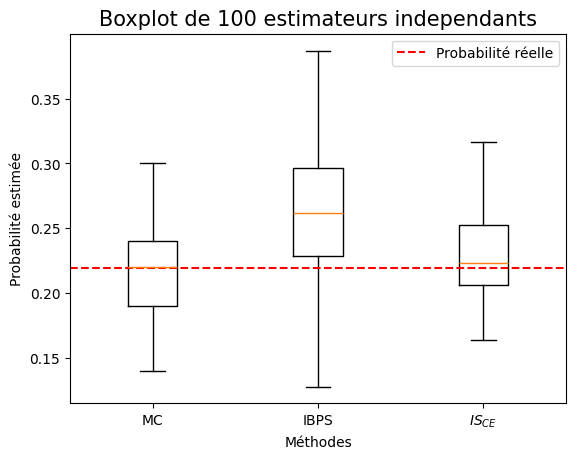

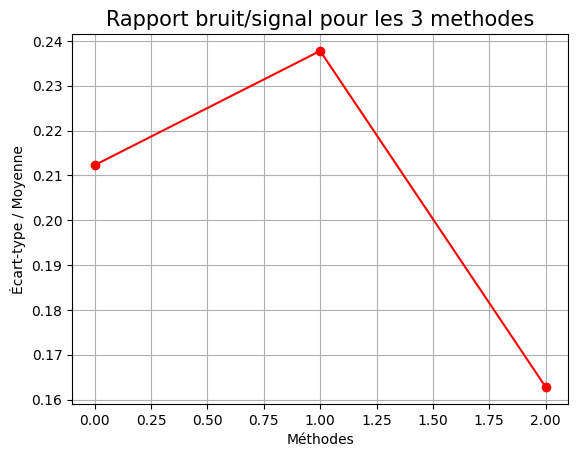

<Figure size 640x480 with 0 Axes>

In [ ]:
##################################### Paramètres
N = 100             #### Taille de la population
S0 = N - 10         ### Susceptibles initiaux
I0 = 10             ### Infectés initiaux
beta = 0.2          ### Taux de transmission
gamma = 0.1         ### Taux de guérison
R0 = beta / gamma   ### Nombre de reproduction de base

### Valeur théorique approximative de I_max dans le modèle déterministe
I_max_deterministe = N * (1 - 1/R0 - (1/R0) * np.log(R0))
print(f"R0 = {R0}")
print(f"I_max théorique (déterministe) ≈ {I_max_deterministe:.1f}")

### Définition du seuil pour l'événement rare (ex: 20% au-dessus de la valeur déterministe)
Seuil = int(2* I_max_deterministe)
print(f"Seuil pour l'événement rare: I_max > {Seuil}")

NbrIter = 100
Stock = np.zeros((NbrIter, 3))
M = 100

for nn in tqdm(range(NbrIter), desc="Calcul des probabilités"):

    Stock[nn, 0] = proba_MonteCarlo_v2(S0,N,beta,gamma,Seuil,M )
    Stock[nn, 1] = ibps_imax(S0,I0,N,beta,gamma,Seuil,200, 45)
    Stock[nn, 2] = proba_ce_IS_Imax(S0, I0, N, beta, gamma, Seuil, M, K=15)[0]
Proba= proba_MonteCarlo_v2(S0,N,beta,gamma,Seuil,1000000)

### Tracer les boxplots de chaque estimateur
plt.title("Boxplot de " + str(NbrIter) +" estimateurs independants", fontsize=15)
plt.boxplot(Stock[:, 0:3], positions=[1,2,3],
            labels = ['MC','IBPS','$IS_{CE}$'],
            showfliers=False )
plt.axhline(y=Proba, color='r', linestyle='--', label='Probabilité réelle')
plt.legend()
plt.ylabel("Probabilité estimée")
plt.xlabel("Méthodes")

plt.figure()



### Comparer l' "ecart-type / valeur moyenne" des trois estimateurs
mean_stock = Proba


st_dev = np.std(Stock, axis=0)

plt.plot(st_dev/mean_stock,'r-o')
plt.title("Rapport bruit/signal pour les 3 methodes", fontsize=15)
plt.ylabel("Écart-type / Moyenne")
plt.xlabel("Méthodes")
plt.grid()
plt.figure()

Encore une fois l'$IS_{CE}$ montre une bonne performance par rapport à L'IBPS

#Partie 4: Extensions de notre project N°2: Modèle SEIR


Le modèle $SEIR$ est une extension du modèle SIR qui ajoute une phase d’incubation dans la dynamique d’une épidémie.


-$S (Susceptible) $: individus sains, susceptibles d’être infectés.

-$E (Exposed) $: individus exposés (infectés mais pas encore infectieux, période d’incubation).

-$I (Infectious)$ : individus infectés et capables de transmettre la maladie.

-$R (Recovered/Removed)$ : individus guéris ou décédés, ne participent plus à la transmission.

##Modèle détérministe



Le système d’équations est :

$$\frac{dS}{dt} = -\beta \frac{S I}{N}$$

$$\frac{dE}{dt} = \beta \frac{S I}{N} - \sigma E$$

$$\frac{dI}{dt} = \sigma E - \gamma I$$

$$\frac{dR}{dt} = \gamma I$$



Avec :

$β$: taux de transmission.

$σ$ : taux de passage de E à I.

$γ$ : taux de guérison.

In [ ]:
def Modele_deterministe(S0,E0, I0,R0, N, beta ,sigma , gamma):
  def seir_model(y, t, N, beta, sigma, gamma):
      S, E, I, R = y
      dSdt = -beta * S * I / N
      dEdt = beta * S * I / N - sigma * E
      dIdt = sigma * E - gamma * I
      dRdt = gamma * I
      return dSdt, dEdt, dIdt, dRdt
  t = np.linspace(0, 125, 125)
  y0 = S0, E0, I0, R0

  sol = odeint(seir_model, y0, t, args=(N, beta, sigma, gamma))
  S,E,I,R = sol.T
  return t,S,E,I,R



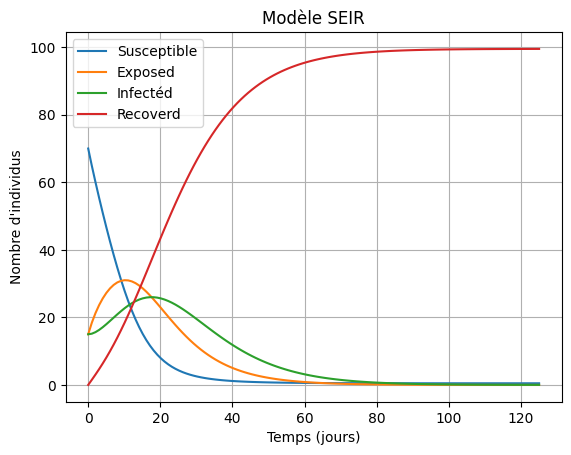

In [ ]:
N = 100
beta = 0.5
sigma = 0.1
gamma = 0.1
E0, I0, R0 = 15, 15, 0
S0 = N - E0 - I0 - R0


t,S,E,I,R = Modele_deterministe(S0,E0, I0,R0, N, beta, sigma, gamma)


# Plot
plt.plot(t, S, label='Susceptible')
plt.plot(t, E, label='Exposed')
plt.plot(t, I, label='Infectéd')
plt.plot(t, R, label='Recoverd')
plt.xlabel("Temps (jours)")
plt.ylabel("Nombre d'individus")
plt.title("Modèle SEIR")
plt.legend()
plt.grid(True)
plt.show()

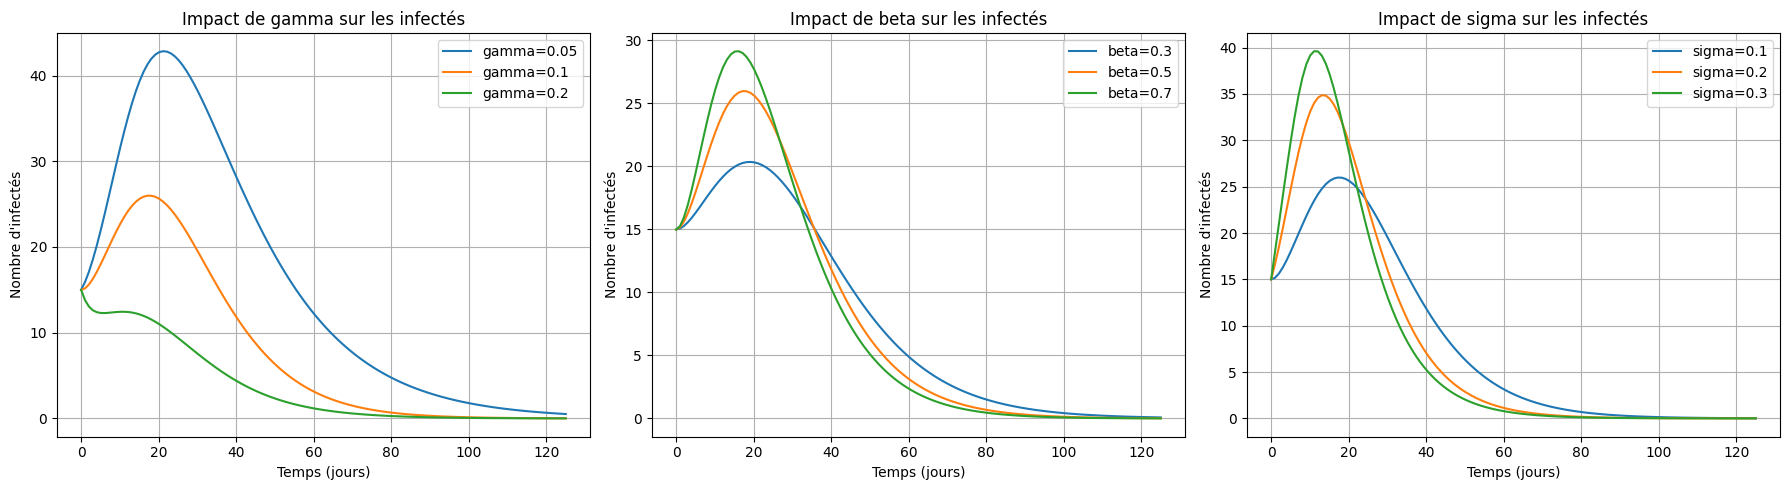

In [ ]:
# Différentes valeurs des paramètres
beta_values = [0.3, 0.5, 0.7]
sigma_values = [0.1, 0.2, 0.3]
gamma_values = [0.05, 0.1, 0.2]

### Initialisation de la figure
plt.figure(figsize=(18, 5))

### Graphe pour différentes valeurs de gamma
plt.subplot(1, 3, 1)
for gamma in gamma_values:
    t, S, E, I, R = Modele_deterministe(S0, E0, I0, R0, N, beta=0.5, sigma=0.1, gamma=gamma)
    plt.plot(t, I, label=f"gamma={gamma}")
plt.title("Impact de gamma sur les infectés")
plt.xlabel("Temps (jours)")
plt.ylabel("Nombre d'infectés")
plt.legend()
plt.grid(True)

### Graphe pour différentes valeurs de beta
plt.subplot(1, 3, 2)
for beta in beta_values:
    t, S, E, I, R = Modele_deterministe(S0, E0, I0, R0, N, beta=beta, sigma=0.1, gamma=0.1)
    plt.plot(t, I, label=f"beta={beta}")
plt.title("Impact de beta sur les infectés")
plt.xlabel("Temps (jours)")
plt.ylabel("Nombre d'infectés")
plt.legend()
plt.grid(True)

### Graphe pour différentes valeurs de sigma
plt.subplot(1, 3, 3)
for sigma in sigma_values:
    t, S, E, I, R = Modele_deterministe(S0, E0, I0, R0, N, beta=0.5, sigma=sigma, gamma=0.1)
    plt.plot(t, I, label=f"sigma={sigma}")
plt.title("Impact de sigma sur les infectés")
plt.xlabel("Temps (jours)")
plt.ylabel("Nombre d'infectés")
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()


#Intérét de l'ajout des Exposés ( $\sigma$) par rapport à l'SIR
Bien que σ n'apparaisse pas dans la formule de R₀, il joue un rôle important dans la dynamique temporelle de l'épidémie :

Plus σ est petit (longue incubation), plus l'épidémie met du temps à démarrer, même si R₀ > 1.
σ agit comme un ralentisseur ou un délai : il déphase le pic de contagion, sans forcément l'atténuer.

(Voir la courbe ci dessous)

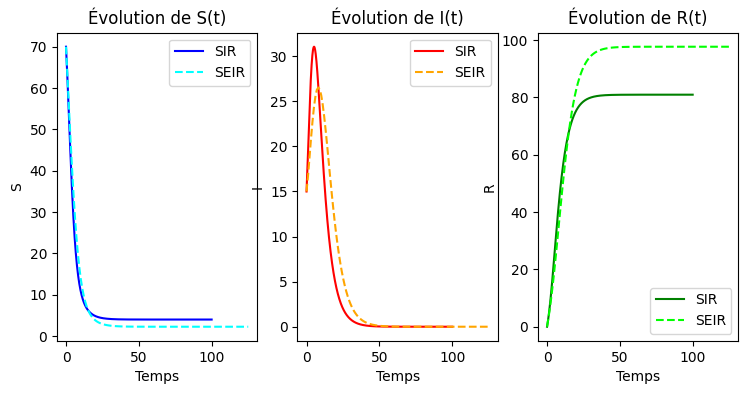

In [ ]:
########################################## Simulation ############################
times = np.linspace(0, 1000, 1000)

t_seir, S_seir, E_seir, I_seir, R_seir = Modele_deterministe(S0, E0, I0, R0, N, beta, sigma, gamma)
t_sir, S_sir, I_sir, R_sir = simulation_deterministe(S0, I0, R0, beta, gamma, N, times, dt)

# Comparaison : S(t)
plt.figure(figsize=(20, 4))
plt.subplot(1, 5, 1)
plt.plot(t_sir, S_sir, label='SIR', color='blue')
plt.plot(t_seir, S_seir, label='SEIR', color='cyan', linestyle='--')
plt.title("Évolution de S(t)")
plt.xlabel("Temps")
plt.ylabel("S")
plt.legend()


#  Comparaison : I(t)
plt.subplot(1, 5, 2)
plt.plot(t_sir, I_sir, label='SIR', color='red')
plt.plot(t_seir, I_seir, label='SEIR', color='orange', linestyle='--')
plt.title("Évolution de I(t)")
plt.xlabel("Temps")
plt.ylabel("I")
plt.legend()


#  Comparaison : R(t)
plt.subplot(1, 5, 3)
plt.plot(t_sir, R_sir, label='SIR', color='green')
plt.plot(t_seir, R_seir, label='SEIR', color='lime', linestyle='--')
plt.title("Évolution de R(t)")
plt.xlabel("Temps")
plt.ylabel("R")
plt.legend()



##Modèle Stochastique

Lorsque la population reste bornée,
On peut s'intérésser à un modèle SEIR stochastique qui tient compte
de l'aléa des interactions entre individus.

Pour cela, on considère la chaîne de Markov à temps continu $(S(t),E(t),I(t),R$(t),t ≥0),

partant initialement de $(S(0) = N−i0,I(0) = i0,R(0) = 0) $ et avec les  transitions suivants :

$$ (S,E,I,R ) → (S-1 ,E+1,I,R ) \text{  avec un taux de  } \beta * \frac{S*I}{N} $$

$$ (S,E,I,R ) → (S ,E-1,I+1,R ) \text{  avec un taux de  } \sigma *E $$

$$ (S,E,I,R ) → (S ,E,I+1,R-1 ) \text{  avec un taux de  } \gamma * I $$

In [ ]:
def simul_SEIR_stoch(S0, E0, I0, R0, N, beta, sigma, gamma):
    S, E, I, R = S0, E0, I0, R0
    t = 0.0
    times = [t]
    traj_S = [S]
    traj_E = [E]
    traj_I = [I]
    traj_R = [R]

    while I > 0 or E > 0:
        taux_SE = beta * S * I / N
        taux_EI = sigma * E
        taux_IR = gamma * I
        total = taux_SE + taux_EI + taux_IR

        # Temps jusqu'au prochain événement
        dt = np.random.exponential(1 / total)
        t += dt

        # Type d'événement
        r = np.random.rand()
        if r < taux_SE / total:
            # Infection (S → E)
            S -= 1
            E += 1
        elif r < (taux_SE + taux_EI) / total:
            # Fin d'incubation (E → I)
            E -= 1
            I += 1
        else:
            # Guérison (I → R)
            I -= 1
            R += 1

        times.append(t)
        traj_S.append(S)
        traj_E.append(E)
        traj_I.append(I)
        traj_R.append(R)

    return np.array(times), np.array(traj_S), np.array(traj_E), np.array(traj_I), np.array(traj_R)


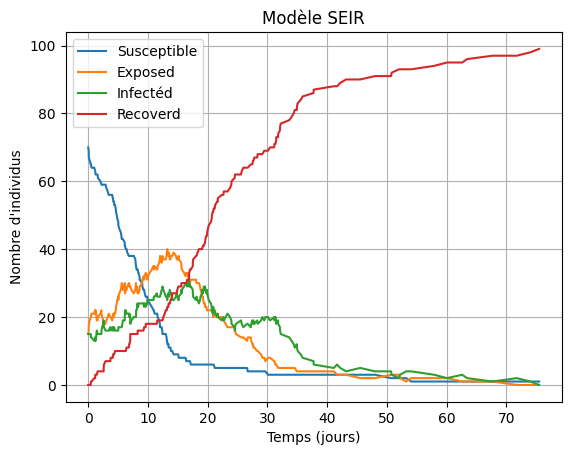

In [ ]:
N = 100
beta = 0.5
sigma = 0.1
gamma = 0.1
E0, I0, R0 = 15, 15, 0
S0 = N - E0 - I0 - R0


t,S, E, I, R = simul_SEIR_stoch(S0,E0, I0,R0, N, beta, sigma, gamma)

# Plot
plt.plot(t, S, label='Susceptible')
plt.plot(t, E, label='Exposed')
plt.plot(t, I, label='Infectéd')
plt.plot(t, R, label='Recoverd')
plt.xlabel("Temps (jours)")
plt.ylabel("Nombre d'individus")
plt.title("Modèle SEIR")
plt.legend()
plt.grid(True)
plt.show()

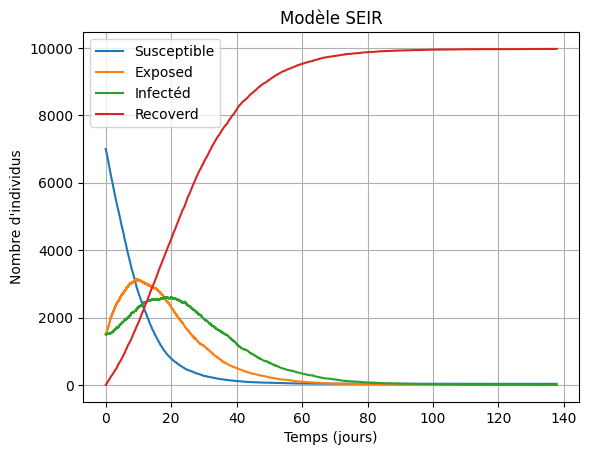

In [ ]:
N = 10000
beta = 0.5
sigma = 0.1
gamma = 0.1
E0, I0, R0 = 1500, 1500, 0
S0 = N - E0 - I0 - R0


t,S, E, I, R = simul_SEIR_stoch(S0,E0, I0,R0, N, beta, sigma, gamma)

# Plot
plt.plot(t, S, label='Susceptible')
plt.plot(t, E, label='Exposed')
plt.plot(t, I, label='Infectéd')
plt.plot(t, R, label='Recoverd')
plt.xlabel("Temps (jours)")
plt.ylabel("Nombre d'individus")
plt.title("Modèle SEIR")
plt.legend()
plt.grid(True)
plt.show()

#Partie 5: Contrôle optimal d'une épidémie

## Modèle Mathématique

### Équations du Modèle SIR

Le modèle décrit l'évolution d'une épidémie avec un contrôle de vaccination :

$$
\begin{cases}
\dot{S}(t) = -\alpha S(t)I(t) + u(t) \\
\dot{I}(t) = \alpha S(t)I(t) - \beta I(t) - u(t) \\
\dot{R}(t) = \beta I(t)
\end{cases}
$$

Avec les contraintes :
- $0 \leq u(t) \leq m$
- $\alpha > 0$ : taux d'infection
- $\beta > 0$ : taux de guérison



### Problème d'Optimisation

On cherche à minimiser la fonctionnelle :

$$J(u) = \gamma I(T) + \frac{1}{2} \int_0^T u(t)^2 dt$$

avec $u \in L^2([0,T]; [0,m])$ et $\gamma > 0$

## Analyse Préliminaire

### Lemme sur l'Existence de la Solution

**Propriétés :**
- Si $u(t) = 0$, alors $S(t) \geq 0$, $I(t) \geq 0$, $R(t) \geq 0$
- La solution est unique et existe pour tout temps

### Conditions Initiales

Données initiales : $S_0 \geq 0$, $I_0 \geq 0$, $R_0 \geq 0$ avec $S_0 + I_0 + R_0 = N$

## Détermination de l'Adjoint

### Définition des Matrices

Soit $x = (S, I, R)^T$ et $f(x,u)$ le système d'équations :

$$f(x,u) = \begin{pmatrix} -\alpha SI + u \\ \alpha SI - \beta I - u \\ \beta I \end{pmatrix}$$

Matrice jacobienne $\frac{\partial f}{\partial x}(x,u)$ :

$$\frac{\partial f}{\partial x}(x,u) = \begin{pmatrix} -\alpha I & -\alpha S & 0 \\ \alpha I & \alpha S - \beta & 0 \\ 0 & \beta & 0 \end{pmatrix}$$

### Équation de l'Adjoint

L'adjoint $p = (p_S, p_I, p_R)^T$ vérifie :

$$\dot{p}(t) = -\frac{\partial f}{\partial x}(x,u)^T p(t), \quad p(T) = (0, \gamma, 0)^T$$

## Contrôle Optimal

### Hamiltonien

L'Hamiltonien est :

$$H(x,p,u) = p_S(-\alpha SI + u) + p_I(\alpha SI - \beta I - u) + p_R \beta I + \frac{1}{2}u^2$$

### Calcul du Contrôle Optimal

Le contrôle optimal $u(t)$ est donné par :

$$u(t) = \begin{cases}
0 & \text{si } p_I(t) - p_S(t) \leq 0 \\
\min(m, p_I(t) - p_S(t)) & \text{sinon}
\end{cases}$$

**Note :** Au temps final, on vaccine au maximum si possible.



In [ ]:
# Paramètres du modèle
alpha = 0.3  # taux d'infection
beta = 0.1   # taux de guérison
gamma = 1.0  # poids pour I(T) dans la fonction coût
m = 0.2      # contrôle maximal (réduit pour plus de stabilité)
T = 50       # temps final (réduit)
N = 1        # population totale (normalisée)

# Conditions initiales
S0 = 0.99
I0 = 0.01
R0 = 0.0

# Nombre de points de discrétisation
n_points = 50
t_eval = np.linspace(0, T, n_points)


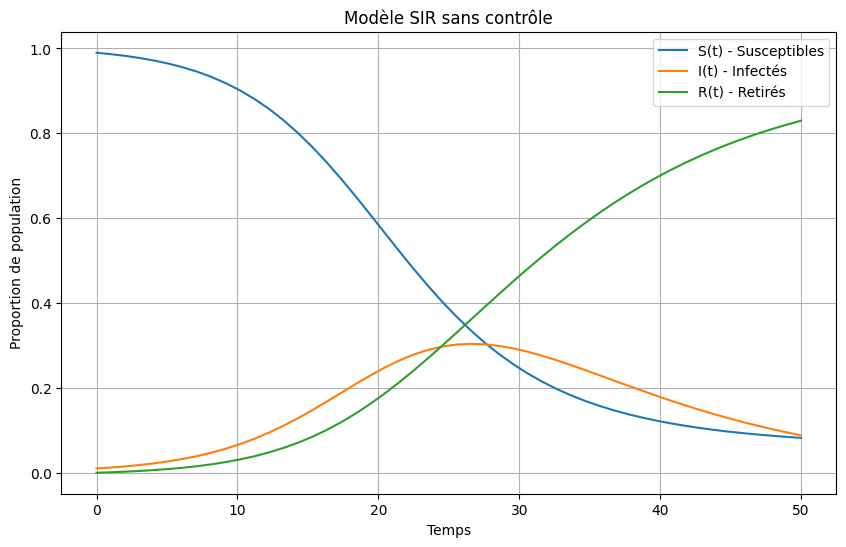

In [ ]:
# ======================================================================
# Solution sans contrôle (u=0)
# ======================================================================

# Définition du système SIR sans contrôle
def sir_ode_no_control(t, y):
    S, I, R = y
    S = max(S, 0)
    I = max(I, 0)
    R = max(R, 0)

    dSdt = -alpha * S * I
    dIdt = alpha * S * I - beta * I
    dRdt = beta * I

    if I < 1e-10 and dIdt < 0:
        dIdt = 0
    if S < 1e-10 and dSdt < 0:
        dSdt = 0

    return [dSdt, dIdt, dRdt]

# Résolution sans contrôle
sol_no_control = solve_ivp(sir_ode_no_control, [0, T], [S0, I0, R0],
                          t_eval=t_eval, method='LSODA', rtol=1e-6, atol=1e-8)
sol_no_control.y[0] = np.maximum(sol_no_control.y[0], 0)
sol_no_control.y[1] = np.maximum(sol_no_control.y[1], 0)
sol_no_control.y[2] = np.maximum(sol_no_control.y[2], 0)

# Affichage sans contrôle
plt.figure(figsize=(10, 6))
plt.plot(sol_no_control.t, sol_no_control.y[0], label='S(t) - Susceptibles')
plt.plot(sol_no_control.t, sol_no_control.y[1], label='I(t) - Infectés')
plt.plot(sol_no_control.t, sol_no_control.y[2], label='R(t) - Retirés')
plt.xlabel('Temps')
plt.ylabel('Proportion de population')
plt.title('Modèle SIR sans contrôle')
plt.legend()
plt.grid()
plt.show()

Itération 1, différence: 0.2000
Itération 2, différence: 0.1000
Itération 3, différence: 0.0526


<ipython-input-33-f6cb27e74995>:20: RuntimeWarning: overflow encountered in scalar multiply
  dSdt = -alpha * S * I + u
<ipython-input-33-f6cb27e74995>:21: RuntimeWarning: overflow encountered in scalar multiply
  dIdt = alpha * S * I - beta * I - u
<ipython-input-33-f6cb27e74995>:21: RuntimeWarning: invalid value encountered in scalar subtract
  dIdt = alpha * S * I - beta * I - u
/usr/local/lib/python3.11/dist-packages/scipy/integrate/_ivp/lsoda.py:161: UserWarning: lsoda: Excess accuracy requested (tolerances too small).
  solver._y, solver.t = integrator.run(


Itération 4, différence: 0.0659
Itération 5, différence: 0.0797


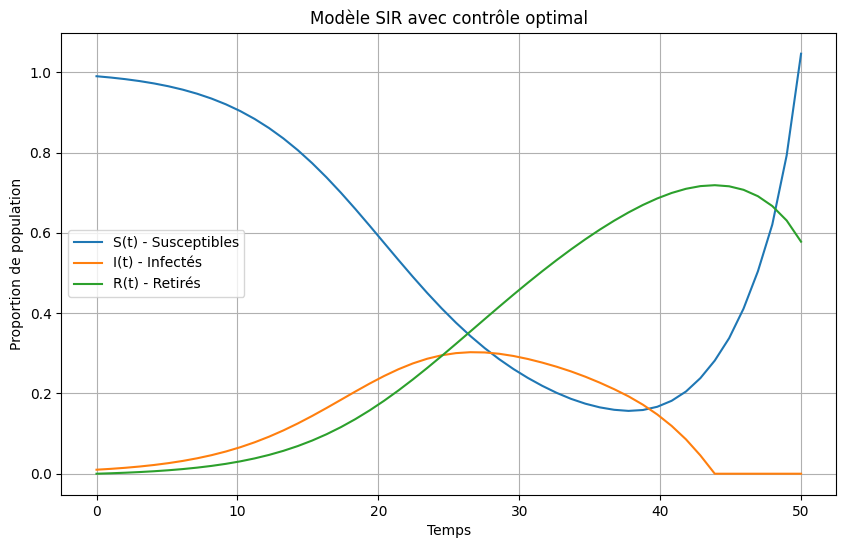

In [ ]:
# ======================================================================
# Solution avec contrôle optimal
# ======================================================================

# Initialisation du contrôle
u_prev = np.zeros(n_points)
S_prev = np.ones(n_points) * S0
I_prev = np.ones(n_points) * I0
R_prev = np.ones(n_points) * R0

max_iter = 5
tol = 1e-3

# Résolution finale avec contrôle optimal
def sir_ode_with_control(t, y):
    S, I, R = y
    idx = min(int(t / T * (n_points-1)), n_points-1)
    u = min(max(u_prev[idx], 0), m)

    dSdt = -alpha * S * I + u
    dIdt = alpha * S * I - beta * I - u
    dRdt = beta * I

    return [dSdt, dIdt, dRdt]


for iteration in range(max_iter):

    sol = solve_ivp(sir_ode_with_control, [0, T], [S0, I0, R0],
                   t_eval=t_eval, method='LSODA', rtol=1e-6, atol=1e-8)

    # Interpolation sur la grille fixe
    S = np.interp(t_eval, sol.t, np.maximum(sol.y[0], 0))
    I = np.interp(t_eval, sol.t, np.maximum(sol.y[1], 0))
    R = np.interp(t_eval, sol.t, np.maximum(sol.y[2], 0))

    # Étape backward: résolution du système adjoint
    pS = np.zeros(n_points)
    pI = np.zeros(n_points)
    pR = np.zeros(n_points)

    # Condition terminale
    pS[-1] = 0
    pI[-1] = gamma
    pR[-1] = 0

    # Intégration backward
    dt = T / (n_points - 1)
    for i in range(n_points-2, -1, -1):
        dpS = alpha * I[i] * (pS[i+1] - pI[i+1])
        dpI = -alpha * S[i] * (pS[i+1] - pI[i+1]) + beta * pI[i+1]

        pS[i] = pS[i+1] - dpS * dt
        pI[i] = pI[i+1] - dpI * dt
        pR[i] = 0

    # Calcul du nouveau contrôle
    u_new = np.clip(pI - pS, 0, m)

    # Lissage
    if iteration > 0:
        u_new = 0.5 * u_new + 0.5 * u_prev

    # Critère de convergence
    diff = np.max(np.abs(u_new - u_prev))
    print(f"Itération {iteration + 1}, différence: {diff:.4f}")

    if diff < tol:
        print("Convergence atteinte!")
        break

    u_prev = u_new


sol_optimal = solve_ivp(sir_ode_with_control, [0, T], [S0, I0, R0],
                       t_eval=t_eval, method='LSODA', rtol=1e-6, atol=1e-8)
sol_optimal.y[0] = np.maximum(sol_optimal.y[0], 0)
sol_optimal.y[1] = np.maximum(sol_optimal.y[1], 0)
sol_optimal.y[2] = np.maximum(sol_optimal.y[2], 0)

# Affichage avec contrôle optimal
plt.figure(figsize=(10, 6))
plt.plot(sol_optimal.t, sol_optimal.y[0], label='S(t) - Susceptibles')
plt.plot(sol_optimal.t, sol_optimal.y[1], label='I(t) - Infectés')
plt.plot(sol_optimal.t, sol_optimal.y[2], label='R(t) - Retirés')
plt.xlabel('Temps')
plt.ylabel('Proportion de population')
plt.title('Modèle SIR avec contrôle optimal')
plt.legend()
plt.grid()
plt.show()

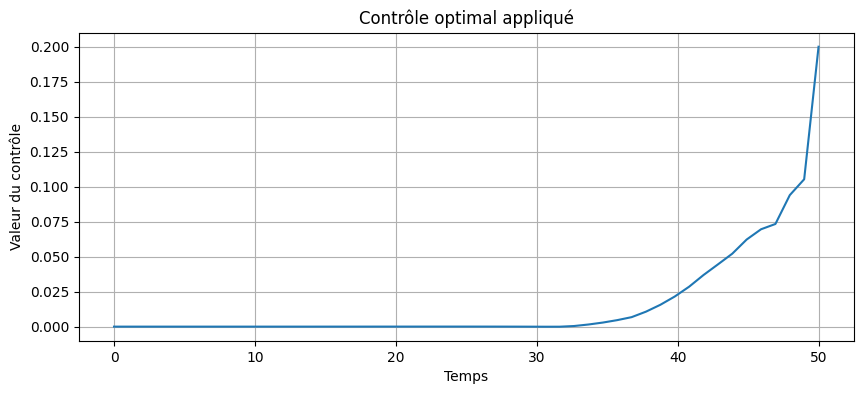

In [ ]:
# Affichage du contrôle optimal
plt.figure(figsize=(10, 4))
plt.plot(t_eval, u_prev, label='Contrôle optimal u(t)')
plt.xlabel('Temps')
plt.ylabel('Valeur du contrôle')
plt.title('Contrôle optimal appliqué')
plt.grid()
plt.show()

In [ ]:
# Calcul des indicateurs d'efficacité
S_no_control = np.interp(t_eval, sol_no_control.t, np.maximum(sol_no_control.y[0], 0))
I_no_control = np.interp(t_eval, sol_no_control.t, np.maximum(sol_no_control.y[1], 0))
R_no_control = np.interp(t_eval, sol_no_control.t, np.maximum(sol_no_control.y[2], 0))

S_optimal = np.interp(t_eval, sol_optimal.t, np.maximum(sol_optimal.y[0], 0))
I_optimal = np.interp(t_eval, sol_optimal.t, np.maximum(sol_optimal.y[1], 0))
R_optimal = np.interp(t_eval, sol_optimal.t, np.maximum(sol_optimal.y[2], 0))

peak_no_control = np.max(I_no_control)
peak_optimal = np.max(I_optimal)
reduction_peak = (peak_no_control - peak_optimal) / peak_no_control * 100

total_infected_no_control = np.trapezoid(I_no_control, t_eval)
total_infected_optimal = np.trapezoid(I_optimal, t_eval)
reduction_total = (total_infected_no_control - total_infected_optimal) / total_infected_no_control * 100

# Calcul du coût final
cost = gamma * I_optimal[-1] + 0.5 * np.trapezoid(u_prev**2, t_eval)

print("\n=== Efficacité du contrôle optimal ===")
print(f"Pic d'infection sans contrôle: {peak_no_control:.2%}")
print(f"Pic d'infection avec contrôle: {peak_optimal:.2%}")
print(f"Réduction du pic: {reduction_peak:.1f}%")
print(f"Nombre total d'infections (intégrale de I) sans contrôle: {total_infected_no_control:.2f}")
print(f"Nombre total d'infections avec contrôle: {total_infected_optimal:.2f}")
print(f"Réduction du nombre total d'infections: {reduction_total:.1f}%")
print(f"Coût final: {cost:.4f}")


=== Efficacité du contrôle optimal ===
Pic d'infection sans contrôle: 30.38%
Pic d'infection avec contrôle: 30.27%
Réduction du pic: 0.4%
Nombre total d'infections (intégrale de I) sans contrôle: 8.30
Nombre total d'infections avec contrôle: 7.19
Réduction du nombre total d'infections: 13.4%
Coût final: 0.0315


#Partie 6: Graphes

In [ ]:
##Loi théorique du nombre d'infecté et Espérance théorique
def I(n,alpha,rho) :
  if n==1 :
    return rho/(2*alpha+rho)
  else :
    x=alpha/(alpha+rho)
    return (n-1)*(x**(n-2))*((1-x)**2)*(2*alpha/(2*alpha+rho))


def EI(alpha,rho) :

  return  1+2(alpha/rho)

## Loi théorique de la durée de l'épidemie : la densité
def f_T(s, alpha, rho):
    """
    - Cas rho = 2*alpha : formule limite.
    - Sinon : formule générale pour 2*alpha != rho.
    """
    s = np.asarray(s, float)
    if np.isclose(rho, 2*alpha):
        # Cas particulier rho = 2*alpha
        return 4*alpha * np.exp(-2*alpha * s) + \
               2*alpha * (-1 - 4*alpha * s) * np.exp(-4*alpha * s)
    # Cas général
    term1 = 2 * rho * np.exp(-rho * s)
    term2 = - (4 * alpha * rho) / (2*alpha - rho) * np.exp(-2 * rho * s)
    term3 = (rho * (2*alpha + rho)) / (2*alpha - rho) * np.exp(-(2*alpha + rho) * s)
    return term1 + term2 + term3

<>:12: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<>:12: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<ipython-input-2-4c6b841c4c84>:12: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
  return  1+2(alpha/rho)


### Pour la simulation numérique on va définir une classe noeud

In [ ]:
import numpy as np
import random

class Noeud:
    def __init__(self, x, y, status='I'):
        self.x = x
        self.y = y
        self.status = status

    def copy(self):
        return Noeud(self.x, self.y, self.status)

def epidemie_z1(rho, alpha):
    """
    Simule une épidémie sur ℤ à partir de l'origine avec deux fronts.
    """
    # Initialisation
    gauche  = Noeud(0, 0, 'I')
    droite  = Noeud(0, 0, 'I')
    infectes = {0: 'I'}
    nbr_infec = 1
    Temps_tot = 0.0

    # --- Première transition ---
    rate0 = 2*alpha + rho
    T0 = np.random.exponential(1/rate0)
    Temps_tot += T0
    U0 = random.random() * rate0

    front = 2
    if U0 < 2*alpha:
        nbr_infec += 1
        if U0 < alpha:
            gauche = Noeud(gauche.x - 1, 0, 'I')
            infectes[gauche.x] = 'I'
        else:
            droite = Noeud(droite.x + 1, 0, 'I')
            infectes[droite.x] = 'I'
    else:
        front -= 1
        if random.random() < 0.5:
            gauche.status = 'R'
        else:
            droite.status = 'R'

    # --- Suites des transitions ---
    while front > 0:
        n_inf = len(infectes)
        rate = n_inf * rho + front * alpha
        Dt = np.random.exponential(1/rate)
        Temps_tot += Dt
        U = random.random() * rate

        if U < front * alpha:
            nbr_infec += 1
            if front == 2:
                cible = 'gauche' if random.random() < 0.5 else 'droite'
            else:
                cible = 'gauche' if gauche.status == 'I' else 'droite'

            if cible == 'gauche':
                new_x = gauche.x - 1
                gauche = Noeud(new_x, 0, 'I')
                infectes[new_x] = 'I'
            else:
                new_x = droite.x + 1
                droite = Noeud(new_x, 0, 'I')
                infectes[new_x] = 'I'
        else:
            pos = random.choice(list(infectes.keys()))
            infectes.pop(pos)
            if pos == gauche.x and gauche.status == 'I':
                front -= 1
                gauche.status = 'R'
            elif pos == droite.x and droite.status == 'I':
                front -= 1
                droite.status = 'R'
            # sinon, un individu intérieur guérit

    return Temps_tot, nbr_infec, gauche.x, droite.x

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

## Classe Noeud pour faciliter l'implémentation de la dynamique dans notre graphe
class Noeud:
    def __init__(self, x, y, status, voisins_infectes=None, voisins_rec=None):
        """
        x, y : coordonnées
        status : 'S', 'I' ou 'R'
        voisins_infectes : liste de hashes des voisins infectés
        voisins_rec : liste de hashes des voisins immunisés
        """
        self.x = x
        self.y = y
        self.status = status
        self.voisins_infectes = voisins_infectes if voisins_infectes is not None else []
        self.voisins_rec = voisins_rec if voisins_rec is not None else []

    def __str__(self):
        inf = '|'.join(str(h) for h in self.voisins_infectes)
        rec = '|'.join(str(h) for h in self.voisins_rec)
        return (f"x={self.x} y={self.y} status={self.status} ; "
                f"INF=[{inf}] ; REC=[{rec}]")

    def hash(self):
        """Hash unique du noeud (coordonnées)."""
        return f"{self.x},{self.y}"

    def copy(self):
        """Renvoie une copie indépendante du noeud."""
        return Noeud(
            self.x,
            self.y,
            self.status,
            voisins_infectes=self.voisins_infectes[:],
            voisins_rec=self.voisins_rec[:]
        )

def epidemie_z1(rho,alpha) :
  droite=Noeud(0,0,'I')   #front droit
  gauche=Noeud(0,0,'I')   #front gauche
  liste_infect={'0':1}    #Stocke la liste des personnes infectées

  nbr_infec=1     #Stocke le nombre de personnes infectés au total au cours de l'épidémie
  Temps_tot=0     #Stocke la durée de l'épidémie

  ##Première itération
  T=np.random.exponential(1/(2*alpha+rho))
  Temps_tot+=T
  U=np.random.rand()*(2*alpha+rho)
  front=2
  if U< alpha*2 :   #Si il s'agit d'une infection
      nbr_infec+=1
      if (U<alpha):
          gauche=Noeud(gauche.x-1,0,'I').copy()
          liste_infect[str(gauche.x)]=1
      else :
          droite=Noeud(droite.x+1,0,'I').copy()
          liste_infect[str(droite.x)]=1
  else :  #Si il s'agit d'une guérison
     front=0

  ##Itération jusqu'à extinction des fronts
  while front>0 :
    infecte_inter=len(liste_infect)

    scale=(infecte_inter)*rho+front*alpha
    T=np.random.exponential(1/scale)
    Temps_tot+=T

    U=np.random.rand()*scale

    if U< alpha*front : ##Infection d'un voisin des fronts
      nbr_infec+=1
      if (front==2 and U<alpha) or (droite.status=='R') :
          gauche=Noeud(gauche.x-1,0,'I').copy()
          liste_infect[str(gauche.x)]=1
      else :
          droite=Noeud(droite.x+1,0,'I').copy()
          liste_infect[str(droite.x)]=1
    else :  #Guérison d'un Noeud
      choix=int(np.random.choice(list(liste_infect.keys())))
      if choix==gauche.x :
        front-=1
        gauche.status='R'
      elif choix==droite.x :
        front-=1
        droite.status='R'
      del liste_infect[str(choix)]
  return Temps_tot, nbr_infec, gauche.x,droite.x


In [ ]:

# Loi théorique du nombre d'infectés finaux
def I(n, alpha, rho):
    if n == 1:
        return rho / (2*alpha + rho)
    x = alpha / (alpha + rho)
    return (n-1) * x**(n-2) * (1-x)**2 * (2*alpha/(2*alpha+rho))

# Densité théorique de la durée de l'épidémie
def f_T(s, alpha, rho):
    s = np.asarray(s, float)
    if np.isclose(rho, 2*alpha):
        # cas ρ = 2α
        return 4*alpha * np.exp(-2*alpha*s) + 2*alpha * (-1-4*alpha*s) * np.exp(-4*alpha*s)
    term1 = 2*rho * np.exp(-rho*s)
    term2 = - (4*alpha*rho)/(2*alpha-rho) * np.exp(-2*rho*s)
    term3 = (rho*(2*alpha+rho))/(2*alpha-rho) * np.exp(-(2*alpha+rho)*s)
    return term1 + term2 + term3


## Comparaison théorie et numérique

In [ ]:

# Paramètres et simulation
nbr_traj = 150000
alpha = 0.5
rho   = 1.0

temps = []
nombre_final = []

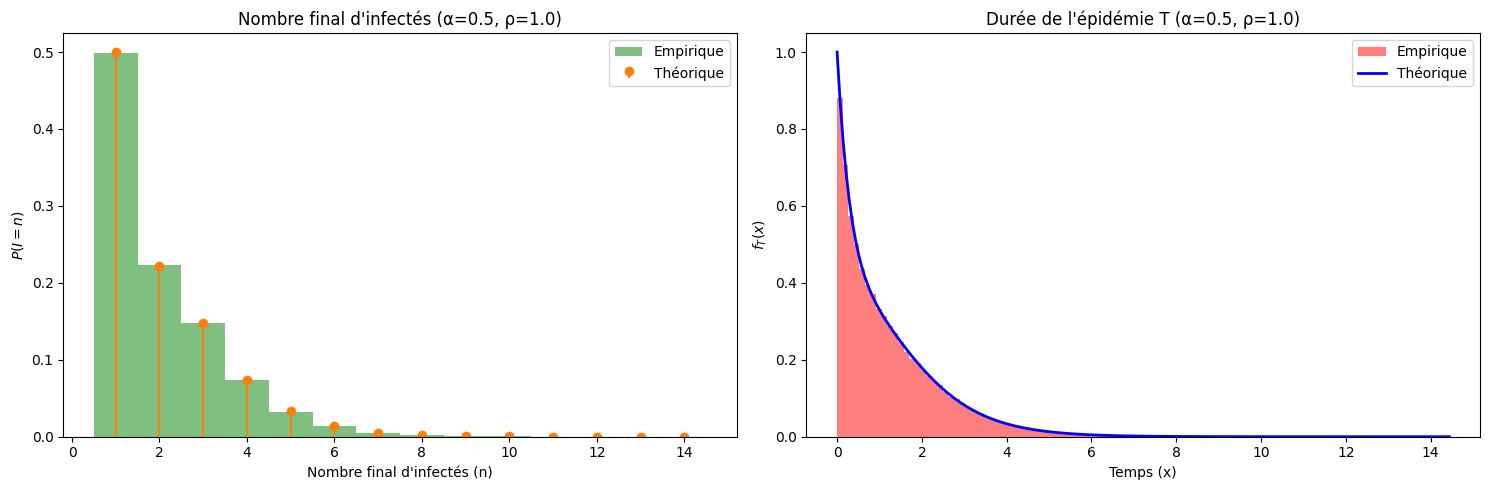

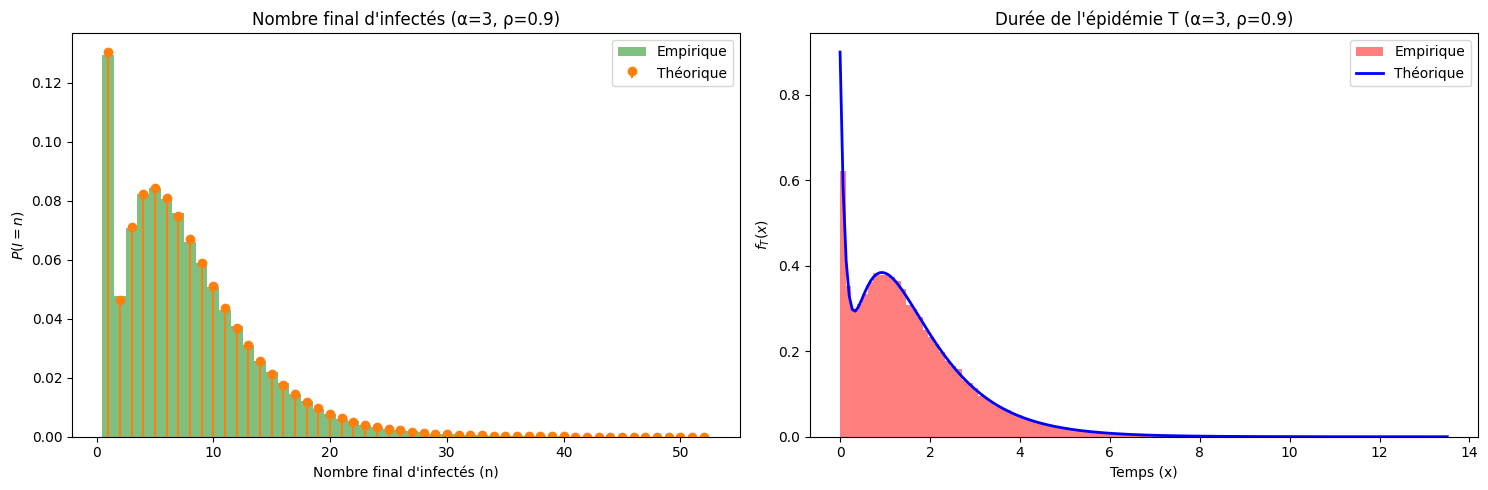

In [ ]:


# Première simulation avec rho = alpha
temps = []
nombre_final = []

for _ in range(nbr_traj):
    t, n, _, _ = epidemie_z1(rho, alpha)
    temps.append(t)
    nombre_final.append(n)

# Tracé des résultats
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogramme du nombre final d'infectés vs loi théorique
bins_nf = np.arange(1, max(nombre_final)+2) - 0.5
axes[0].hist(nombre_final, density=True, bins=bins_nf,
             alpha=0.5, color='green', label='Empirique')
ns = np.arange(1, len(bins_nf))
axes[0].stem(ns, [I(n, alpha, rho) for n in ns],
             linefmt='C1-', markerfmt='C1o', basefmt=" ", label='Théorique')
axes[0].set_title(f"Nombre final d'infectés (α={alpha}, ρ={rho})")
axes[0].set_xlabel('Nombre final d\'infectés (n)')
axes[0].set_ylabel('$P(I=n)$')
axes[0].legend()

# Histogramme de la durée T vs densité théorique
axes[1].hist(temps, density=True, bins=100, alpha=0.5,
             color='red', label='Empirique')
s_vals = np.linspace(0, max(temps)*1.1, 200)
axes[1].plot(s_vals, f_T(s_vals, alpha, rho), 'b-', lw=2, label='Théorique')
axes[1].set_title(f"Durée de l'épidémie T (α={alpha}, ρ={rho})")
axes[1].set_xlabel('Temps (x)')
axes[1].set_ylabel('$f_T(x)$')
axes[1].legend()

plt.tight_layout()
plt.show()


# Simulation avec rho ≠ alpha
alpha = 3
rho = 0.9

temps = []
nombre_final = []

for _ in range(nbr_traj):
    t, n, _, _ = epidemie_z1(rho, alpha)
    temps.append(t)
    nombre_final.append(n)

# Tracé des résultats
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogramme du nombre final d'infectés vs loi théorique
bins_nf = np.arange(1, max(nombre_final)+2) - 0.5
axes[0].hist(nombre_final, density=True, bins=bins_nf,
             alpha=0.5, color='green', label='Empirique')
ns = np.arange(1, len(bins_nf))
axes[0].stem(ns, [I(n, alpha, rho) for n in ns],
             linefmt='C1-', markerfmt='C1o', basefmt=" ", label='Théorique')
axes[0].set_title(f"Nombre final d'infectés (α={alpha}, ρ={rho})")
axes[0].set_xlabel('Nombre final d\'infectés (n)')
axes[0].set_ylabel('$P(I=n)$')
axes[0].legend()

# Histogramme de la durée T vs densité théorique
axes[1].hist(temps, density=True, bins=100, alpha=0.5,
             color='red', label='Empirique')
s_vals = np.linspace(0, max(temps)*1.1, 200)
axes[1].plot(s_vals, f_T(s_vals, alpha, rho), 'b-', lw=2, label='Théorique')
axes[1].set_title(f"Durée de l'épidémie T (α={alpha}, ρ={rho})")
axes[1].set_xlabel('Temps (x)')
axes[1].set_ylabel('$f_T(x)$')
axes[1].legend()

plt.tight_layout()
plt.show()

### Commentaire



```
On voit très bien que les lois théoriques collent parfaitement avec les résultats numériques
```



## Simulation de la loi de la durée de l'épidémie : méthodes vues en cours et comparaison avec la théorie

Dans cette section, nous comparons la distribution théorique de la durée de l’épidémie avec des lois simulées à l’aide de deux méthodes classiques étudiées en cours :

*  la simulation par inversion de la fonction de répartition ;

*   la simulation par la méthode de rejet.

---



Cette étape permet de vérifier empiriquement la validité des résultats théoriques vus en cours, en comparant les lois simulées à la loi théorique de la durée de l’épidémie. Et aussi pour la suite de l'AMS , nous aurons besoin de
 tirer des variables suivant la loi de densité νf. Or, la densité de νf étant manifestement pas usuelle, on essaie de faire la simulation en utilisant d’autres moyens comme ces deux méthodes enoncée.


## Simulation par inversion de la fonction de répartition

On utilise ce théorème du cours:

> Soient $F$ la fonction de répartition d’une variable aléatoire $X$ et $Q$ sa fonction quantile. Si $U \sim \mathcal{U}[0,1]$, alors la variable $Q(U)$ suit la même loi que $X$.





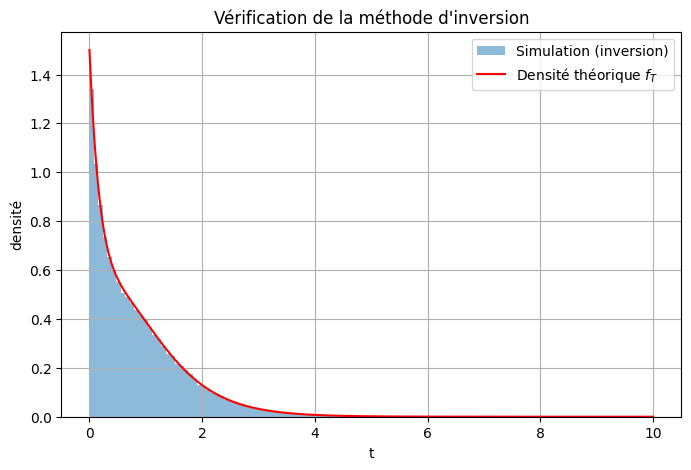

In [ ]:
from scipy.integrate import cumulative_trapezoid as cumtrapz

from scipy.interpolate import interp1d
alpha = 1
rho = 1.5  # changer selon les cas
s_vals = np.linspace(0, 10, 1000)

# Densité
f_vals = f_T(s_vals, alpha, rho)

# Fonction de répartition F_T via quadrature
F_vals = cumtrapz(f_vals, s_vals, initial=0)
F_vals /= F_vals[-1]  # normalisation

# Fonction quantile Q(u) = F^{-1}(u)
Q = interp1d(F_vals, s_vals, bounds_error=False, fill_value=(s_vals[0], s_vals[-1]))

# Simulation via inversion
n = 100000
U = np.random.uniform(0, 1, size=n)
T_samples = Q(U)

# Histogramme vs densité
plt.figure(figsize=(8, 5))
plt.hist(T_samples, bins=100, density=True, alpha=0.5, label='Simulation (inversion)')
plt.plot(s_vals, f_vals, label='Densité théorique $f_T$', color='red')
plt.xlabel("t")
plt.ylabel("densité")
plt.title("Vérification de la méthode d'inversion")
plt.legend()
plt.grid()
plt.show()

### Simulation par méthode de rejet

Soient $f$ et $g$ deux densités sur $\mathbb{R}^d$ vérifiant $\exists c > 0$ tel que $f(x) \leq c g(x)$ pour $\nu$-presque tout $x$. On simule une variable aléatoire de densité $f$ selon les étapes suivantes :


*   Répéter les étapes suivantes :

    1.   Simuler $Y_n \sim g$ ;
    2.   $U_n \sim \mathcal{U}[0,1]$ ;
*  Tant que  $c  U_n g(Y_n) < f(Y_n)$, rejeter $Y_n$ ;
*  Retourner $Y_n$ dès que l'inégalité est satisfaite.



> Nous avons choisi comme densité propositionnelle \(g\) une densité exponentielle de paramètre \(\lambda > 0\), définie par
$$
g(s) = \lambda e^{-\lambda s} \mathbf{1}_{s \geq 0}.
$$

Le paramètre $\lambda$ a été sélectionné en regard de la forme analytique de la densité cible $f_T$, qui est une combinaison de termes exponentiels décroissants avec des taux $\rho$, $2\rho$, et $2\alpha + \rho$. Pour garantir que $g$ majorera $f_T$ sur $\mathbb{R}^+$, nous avons choisi
$
\lambda = \min\{\rho, 2\rho, 2\alpha + \rho\}.
$




Nous avons estimé numériquement cette constante \(c\) en calculant le supremum de $\frac{f_T(s)}{g(s)}$ sur un intervalle suffisamment large, ce qui nous a conduit à la valeur approximative
$
c = 2.
$





In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Densité proposition g : loi exponentielle avec lambda = min des taux dans f_T
def g(s, lam):
    return lam * np.exp(-lam * s) * (s >= 0)

def sample_g(lam):
    return np.random.exponential(1/lam)

# Constante c
def find_c(alpha, rho, lam):
    # On cherche max f_T(s)/(c * g(s)) <=> max f_T(s)/g(s), donc c >= ce max
    s_vals = np.linspace(0, 10, 1000)
    f_vals = f_T(s_vals, alpha, rho)
    g_vals = g(s_vals, lam)
    ratios = np.divide(f_vals, g_vals, out=np.zeros_like(f_vals), where=g_vals>0)
    return np.max(ratios)

# Rejet
def rejection_sampler(f, g, sample_g, c, alpha, rho, lam, n_samples):
    samples = []
    while len(samples) < n_samples:
        y = sample_g(lam)
        u = np.random.uniform(0,1)
        if u < f(y, alpha, rho) / (c * g(y, lam)):
            samples.append(y)
    return np.array(samples)

In [ ]:
# Paramètres
alpha = 1.0
rho = 1.5
lam = min(rho, 2*rho, 2*alpha + rho)  # Ex: 1.5 ici

# Trouver c
c = find_c(alpha, rho, lam)
print(f"Constante c trouvée = {c:.2f}")

# Simuler
n_samples = 100000

Constante c trouvée = 2.00


Constante c trouvée = 2.00


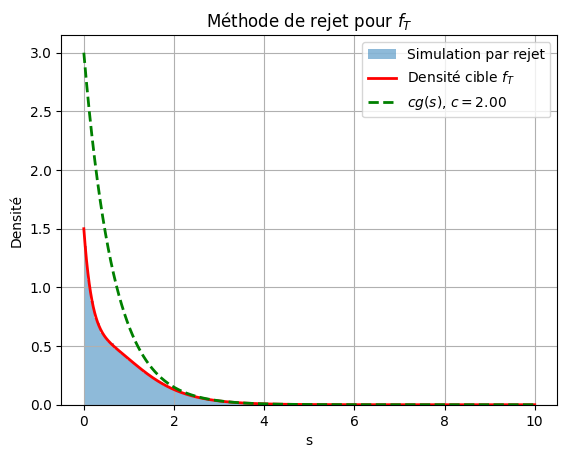

In [ ]:

samples = rejection_sampler(f_T, g, sample_g, c, alpha, rho, lam, n_samples)

# Affichage
s_vals = np.linspace(0, 10, 1000)
plt.hist(samples, bins=100, density=True, alpha=0.5, label="Simulation par rejet")
plt.plot(s_vals, f_T(s_vals, alpha, rho), 'r-', lw=2, label="Densité cible $f_T$")
plt.plot(s_vals, c * g(s_vals, lam), 'g--', lw=2, label=f"$c g(s)$, $c={c:.2f}$")
plt.xlabel("s")
plt.ylabel("Densité")
plt.title("Méthode de rejet pour $f_T$")
plt.legend()
plt.grid()
plt.show()

In [ ]:
import numpy as np

s_vals = np.linspace(0, 10, 10000)  # maillage très fin
f_vals = f_T(s_vals, alpha, rho)
g_vals = g(s_vals, lam)

ratios = np.divide(f_vals, g_vals, out=np.zeros_like(f_vals), where=g_vals>0)
c = np.max(ratios)
print(f"Valeur maximale du ratio f/g : {c}")

Valeur maximale du ratio f/g : 1.9999975672095114


## Simulation de la loi conditionnelle: Metropolis Hasting

In [ ]:
def metropolis_hastings_restricted(alpha, rho, N, x0, sigma, A_cond=lambda x: True):
    samples = []
    x = x0
    for _ in range(N):
        x_prop = np.random.normal(x, sigma)
        if x_prop <= 0:
            samples.append(x)
            continue
        alpha_ratio = min(1, f_T(x_prop, alpha, rho) / f_T(x, alpha, rho))
        if np.random.rand() < alpha_ratio and A_cond(x_prop):
            x = x_prop
        samples.append(x)
    return np.array(samples)

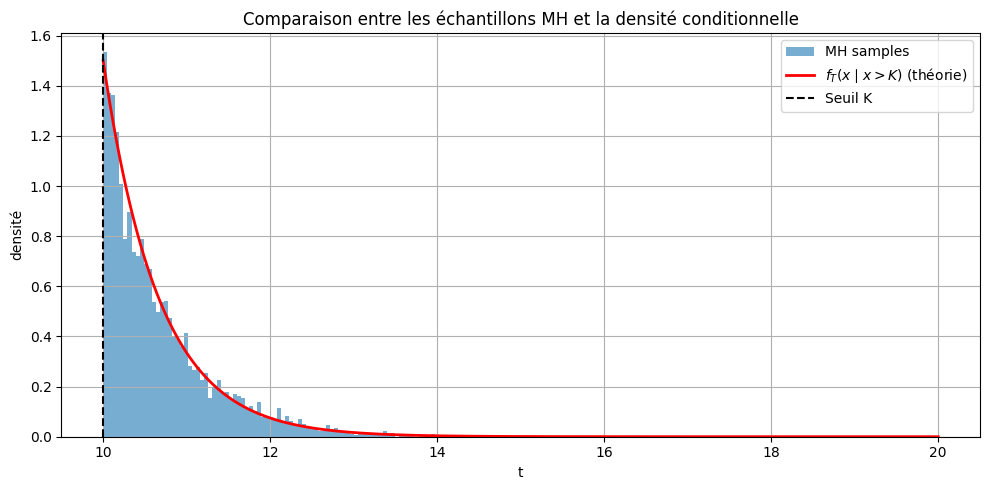

In [ ]:
# Paramètres
alpha, rho = 1, 1.5
K = 10
x0 = K + 1
from scipy.integrate import quad
# Échantillons MH
samples = metropolis_hastings_restricted(
    alpha=alpha,
    rho=rho,
    N=10000,
    x0=x0,
    sigma=1.0,
    A_cond=lambda x: x > K
)

# -----------------------------
# Densité conditionnelle théorique f_T(x | x > K)
x_vals = np.linspace(K, max(samples.max(), K + 10), 500)
numerator = f_T(x_vals, alpha, rho)
normalizing_constant, _ = quad(lambda x: f_T(x, alpha, rho), K, np.inf)
conditional_density = numerator / normalizing_constant

# -----------------------------
# Tracé
plt.figure(figsize=(10, 5))
plt.hist(samples, bins=100, density=True, alpha=0.6, label="MH samples")
plt.plot(x_vals, conditional_density, 'r-', lw=2, label=r"$f_T(x \mid x > K)$ (théorie)")
plt.axvline(K, color='black', linestyle='--', label='Seuil K')
plt.xlabel("t")
plt.ylabel("densité")
plt.title("Comparaison entre les échantillons MH et la densité conditionnelle")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## Evénements rares

### Premier evénement : $P(I>K)$

# l'Importance Sampling vs Monte Carlo pour event rare


L'idée est de modifier la loi de simulation pour suréchantillonner les événements rares, puis corriger le biais via une pondération.  

### **Formulation mathématique :**  
On veut estimer :  
$$
\mathbb{E}_P[\mathbf{1}_{I > k}] = \int \mathbf{1}_{I > k} \, dP
$$
On introduit une loi de proposition $ Q $ (par exemple, une loi géométrique modifiée) et on réécrit :  
$$
\mathbb{E}_P[\mathbf{1}_{I > k}] = \mathbb{E}_Q\left[\mathbf{1}_{I > k} \cdot \frac{dP}{dQ}\right]
$$  


### (A) Loi théorique $ P(I = n) $
La fonction `theoretical_prob_I(n, rho, alpha)` calcule :  
$$
P(I = n) =
\begin{cases}
\frac{\alpha}{2\rho + \alpha} & \text{si } n=1, \\
(n-1) \left(\frac{\rho}{\rho + \alpha}\right)^{n-2} \left(\frac{\alpha}{\rho + \alpha}\right)^2 \frac{2\rho}{2\rho + \alpha} & \text{si } n \geq 2.
\end{cases}
$$
Cela découle d'un processus de branchement modifié où :  
- $ a = \frac{\rho}{\rho + \alpha} $ est la probabilité qu’un individu infectieux guérisse avant de contaminer.  
- $1 - a $ est la probabilité qu’il infecte un voisin.  

### (B) Loi de proposition \( Q \)
Pour favoriser les grandes valeurs de \( I \), on choisit :  
$$
Q(n) = (1 - \tilde{a}) \tilde{a}^{n-1}, \quad \tilde{a} > a
$$
où $ \tilde{a} $ est choisi pour augmenter artificiellement les grandes épidémies.  

### (C) Calcul des poids $ \frac{P}{Q} $
Pour chaque échantillon $n \sim Q $, on calcule :  
$$
w(n) = \frac{P(n)}{Q(n)}
$$  
où \( P(n) \) est donné par `theoretical_prob_I`.  

### (D) Estimateur IS
L'estimateur final est :  
$$
\widehat{P(I > k)} = \frac{1}{N} \sum_{i=1}^N \mathbf{1}_{n_i > k} \cdot w(n_i)
$$





## Pourquoi cette loi et c'est quoi la valeur optimale de ce a_tilde

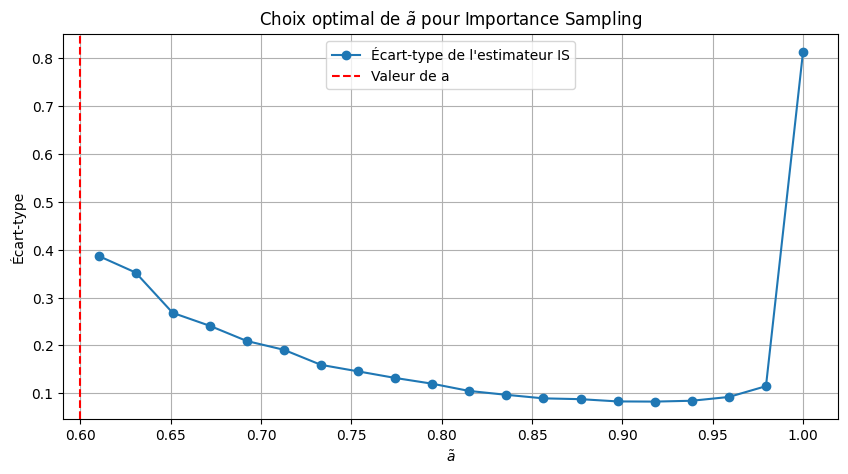

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

###################### Fonction P(n) théorique (comme dans la fonction theoretical_prob_I en bas) ##############################################
def P(n, alpha, rho):
    if n == 1:
        return alpha / (2*rho + alpha)
    else:
        a = rho / (rho + alpha)
        return (n - 1) * (a**(n - 2)) * ((1 - a)**2) * (2*rho / (2*rho + alpha))

######################### Q(n) : loi géométrique modifiée avec paramètre a_tilde ##########################################################
def Q(n, a_tilde):
    return (1 - a_tilde) * a_tilde**(n - 1)

# Poids IS
def w(n, alpha, rho, a_tilde):
    return P(n, alpha, rho) / Q(n, a_tilde)

#################### Simulation importance sampling #########################################################################################
def estimate_IS(alpha, rho, a_tilde, k, N=5000):
    samples = np.random.geometric(p=1 - a_tilde, size=N)
    weights = np.array([w(n, alpha, rho, a_tilde) for n in samples])
    indicators = (samples > k).astype(float)
    estimates = indicators * weights
    return estimates.mean(), estimates.std()

########################################### Paramètres ####################################################################################
alpha, rho = 1.0, 1.5
k = 10
a = rho / (rho + alpha)

#################################### Balayage de plusieurs a_tilde pour Q #################################################################
a_tildes = np.linspace(a + 0.01, 0.99999, 20)  # Q favorise + grandes valeurs
means, stds = [], []

for a_tilde in a_tildes:
    mean, std = estimate_IS(alpha, rho, a_tilde, k)
    means.append(mean)
    stds.append(std)

# Affichage
plt.figure(figsize=(10,5))
plt.plot(a_tildes, stds, 'o-', label='Écart-type de l\'estimateur IS')
plt.axvline(a, color='r', linestyle='--', label='Valeur de a')
plt.xlabel(r'$\tilde{a}$')
plt.ylabel('Écart-type')
plt.title(r'Choix optimal de $\tilde{a}$ pour Importance Sampling')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

def theoretical_prob_I(n, rho, alpha):
    """Calcule P(I = n) selon la loi théorique donnée."""
    a = rho / (rho + alpha)
    if n == 1:
        return alpha / (2 * rho + alpha)
    else:
        return (n - 1) * (a ** (n - 2)) * ((1 - a) ** 2) * (2 * rho / (2 * rho + alpha))

def importance_sampling_estimate(rho, alpha, k,N=100000, tilde_a=0.8):
    """Estime P(I > 15) via Importance Sampling."""
    a = rho / (rho + alpha)
    P_SRS = alpha / (2 * rho + alpha)
    P_infection = 2 * rho / (2 * rho + alpha)

    # Loi de proposition Q : Géométrique modifiée (tilde_a > a)
    Q = lambda n: (1 - tilde_a) * (tilde_a ** (n - 1))  # Q(I = n)

    # Simulation
    samples = np.random.geometric(p=1 - tilde_a, size=N)  # I ~ Q
    weights = np.zeros(N)

    for i in range(N):
        n = samples[i]
        if n == 1:
            P_n = P_SRS
        else:
            P_n = (n - 1) * (a ** (n - 2)) * ((1 - a) ** 2) * P_infection
        weights[i] = P_n / Q(n)

    # Estimateur
    indicator = (samples > k)
    P_estimate = np.mean(indicator * weights)

    return P_estimate



In [ ]:
nbr_traj = 10000
alpha = 3
rho = 0.9
k = 40 # Seuil à choisir

count = 0
for _ in range(nbr_traj):
    _, n, _, _ = epidemie_z1(rho, alpha)
    if n > k:
        count += 1

prob_estimee = count / nbr_traj
print(f"P(I > {k}) estimée = {prob_estimee}")

P(I > 40) estimée = 0.0005


In [ ]:


###################################################### Paramètres ######################################################
rho = 1
alpha = 1
a = rho / (rho + alpha)
tilde_a = 0.91  ### Paramètre de la loi de proposition Q
k=10
#### Estimation
N = 1000  ### Nombre de simulations
P_gt = importance_sampling_estimate(rho, alpha,k, N, tilde_a)

print(f"Estimation de P(I > {k}) = {P_gt:.6f}")

count = 0
for _ in range(nbr_traj):
    _, n, _, _ = epidemie_z1(rho, alpha)
    if n > k:
        count += 1

prob_estimee = count / nbr_traj
print(f"Monte carlo : P(I > {k}) estimée = {prob_estimee}")

Estimation de P(I > 10) = 0.006273
Monte carlo : P(I > 10) estimée = 0.0067


<ipython-input-35-d7d4c8bb33c2>:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([is_estimates, mc_estimates], labels=['Importance Sampling', 'Monte Carlo'])
<ipython-input-35-d7d4c8bb33c2>:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


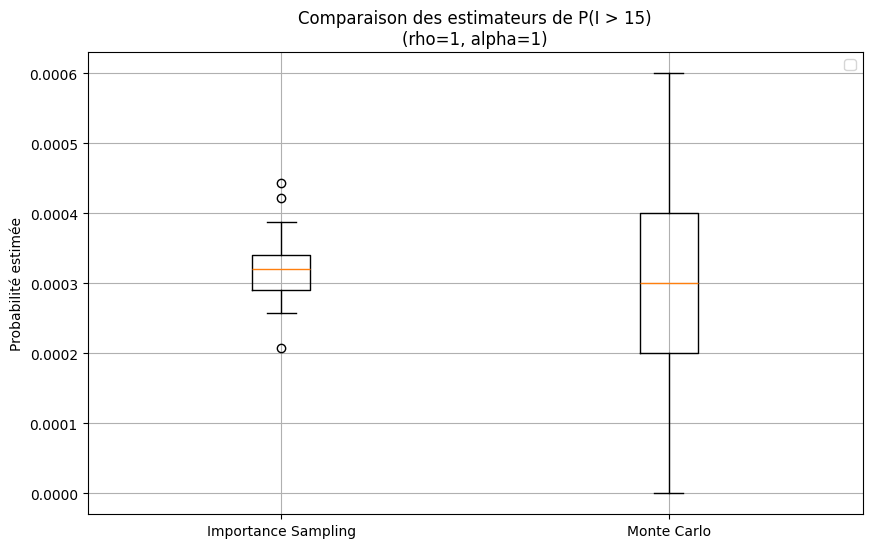

In [ ]:
################### Stockage des résultats
is_estimates = []
mc_estimates = []
n_estimators=100
k=15

for _ in range(n_estimators):
    #### Importance Sampling
    is_est = importance_sampling_estimate(rho, alpha, k, N, tilde_a)
    is_estimates.append(is_est)

    ##### Monte Carlo
    count = 0
    for __ in range(nbr_traj):
        _, n, _, _ = epidemie_z1(rho, alpha)
        if n > k:
            count += 1
    mc_est = count / nbr_traj
    mc_estimates.append(mc_est)
#### Création du boxplot
plt.figure(figsize=(10, 6))
plt.boxplot([is_estimates, mc_estimates], labels=['Importance Sampling', 'Monte Carlo'])
plt.title(f'Comparaison des estimateurs de P(I > {k})\n(rho={rho}, alpha={alpha})')
plt.ylabel('Probabilité estimée')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
# Moyennes
mean_is = np.mean(is_estimates)
mean_mc = np.mean(mc_estimates)

# Écarts-types
std_is = np.std(is_estimates, ddof=1)
std_mc = np.std(mc_estimates, ddof=1)

# Taille de l'échantillon
n = len(is_estimates)

############### Fonction théorique ########################################################################
def proba_theorique_I_superieur_a_k(k, rho, alpha, max_n=1000):
    prob_sum = sum(theoretical_prob_I(n, rho, alpha) for n in range(1, k+1))
    total_prob = sum(theoretical_prob_I(n, rho, alpha) for n in range(1, max_n+1))
    if abs(total_prob - 1) > 1e-6:
        print(f"Attention : somme des proba jusqu'à {max_n} = {total_prob:.6f} (devrait être proche de 1)")
    return 1 - prob_sum

# Calcul valeur théorique
valeur_theorique = proba_theorique_I_superieur_a_k(k, rho, alpha)

# Création du tableau résumé
df_resultats = pd.DataFrame({
    'Méthode': ['Théorique', 'Importance Sampling', 'Monte Carlo'],
    'Estimation': [valeur_theorique, mean_is, mean_mc],
})

print(df_resultats)

               Méthode  Estimation
0            Théorique    0.000326
1  Importance Sampling    0.000320
2          Monte Carlo    0.000278


<ipython-input-29-31e75b7d6ce1>:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([is_estimates, mc_estimates], labels=['Importance Sampling', 'Monte Carlo'])
<ipython-input-29-31e75b7d6ce1>:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


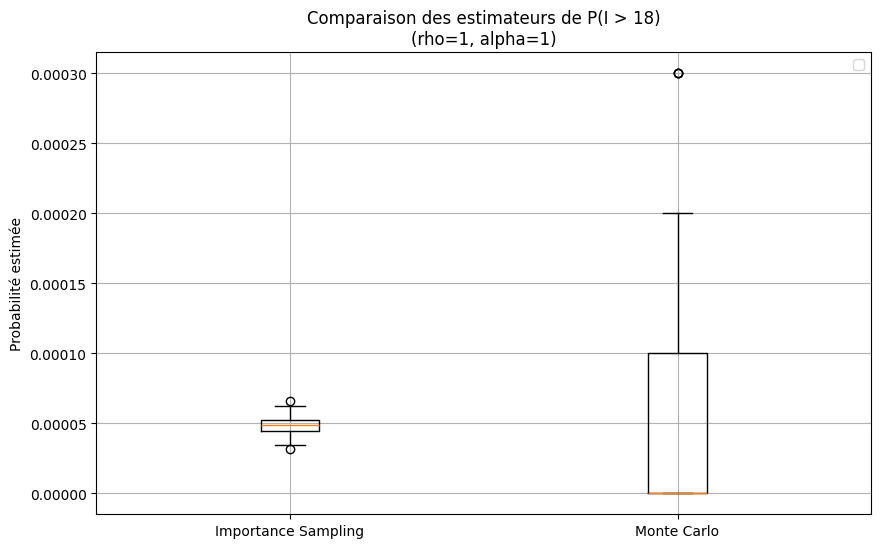

Importance Sampling : Estimation=0.00005, IC95%=(np.float64(4.7219759156972924e-05), np.float64(4.9665138663980105e-05)), Erreur relative=12.88%
Monte Carlo : Estimation=0.00004, IC95%=(np.float64(2.7476535826152815e-05), np.float64(5.6523464173847194e-05)), Erreur relative=176.43%


In [ ]:
## Stockage des résultats
is_estimates = []
mc_estimates = []
n_estimators=100
k=18

for _ in range(n_estimators):
    ## Importance Sampling
    is_est = importance_sampling_estimate(rho, alpha, k, N, tilde_a)
    is_estimates.append(is_est)

    ## Monte Carlo
    count = 0
    for __ in range(nbr_traj):
        _, n, _, _ = epidemie_z1(rho, alpha)
        if n > k:
            count += 1
    mc_est = count / nbr_traj
    mc_estimates.append(mc_est)
## Création du boxplot
plt.figure(figsize=(10, 6))
plt.boxplot([is_estimates, mc_estimates], labels=['Importance Sampling', 'Monte Carlo'])
plt.title(f'Comparaison des estimateurs de P(I > {k})\n(rho={rho}, alpha={alpha})')
plt.ylabel('Probabilité estimée')
plt.legend()
plt.grid(True)
plt.show()

## Moyennes
mean_is = np.mean(is_estimates)
mean_mc = np.mean(mc_estimates)

## Écarts-types
std_is = np.std(is_estimates, ddof=1)
std_mc = np.std(mc_estimates, ddof=1)

## Taille de l'échantillon
n = len(is_estimates)


print(f"Importance Sampling : Estimation={mean_is:.5f}, IC95%={ci_is}, Erreur relative={rel_error_is:.2f}%")
print(f"Monte Carlo : Estimation={mean_mc:.5f}, IC95%={ci_mc}, Erreur relative={rel_error_mc:.2f}%")

### Vérification théorique

In [ ]:
import pandas as pd

############################ Fonction théorique ###############################################
def proba_theorique_I_superieur_a_k(k, rho, alpha, max_n=1000):
    prob_sum = sum(theoretical_prob_I(n, rho, alpha) for n in range(1, k+1))
    total_prob = sum(theoretical_prob_I(n, rho, alpha) for n in range(1, max_n+1))
    if abs(total_prob - 1) > 1e-6:
        print(f"Attention : somme des proba jusqu'à {max_n} = {total_prob:.6f} (devrait être proche de 1)")
    return 1 - prob_sum

### Calcul valeur théorique
valeur_theorique = proba_theorique_I_superieur_a_k(k, rho, alpha)

############################ Création du tableau ##############################################
df_resultats = pd.DataFrame({
    'Méthode': ['Théorique', 'Importance Sampling', 'Monte Carlo'],
    'Estimation': [valeur_theorique, mean_is, mean_mc],
})

print(df_resultats)

               Méthode  Estimation
0            Théorique    0.000048
1  Importance Sampling    0.000048
2          Monte Carlo    0.000042




> ces les valeurs retournées Montre la performance de l'IS





## Détermination de $P(T>q)$

### AMS




**Entrée :**  
$$~ n \text{ (nombre de particules)};~ q \text{ (seuil)}$$

**Initialisation :**  
$$X_1, \dots, X_n \sim f_T ~\text{i.i.d.}$$  
$$J \leftarrow 0$$

**Boucle : tant que**  
$$\min(X_1, \dots, X_n) \leq q$$  
faire :  
$$J \leftarrow J + 1$$  
$$L_J \leftarrow \min(X_1, \dots, X_n)$$  
$$m \leftarrow \arg\min_i X_i$$  
$$X_m \sim f_T(T \mid T > L_J) \quad \text{(conditionnel)}$$  
(Les autres $X_i$ restent inchangés)

**Sortie :**  
$$\hat{p} = \left(1 - \frac{1}{n} \right)^J \approx \mathbb{P}(T > q)$$  
Retourner \((\hat{p}, J)\)

In [ ]:
import numpy as np
from scipy.integrate import quad

################################################################################
# Ta densité cible f_T
def f_T(s, alpha, rho):
    s = np.asarray(s, float)
    if np.isclose(rho, 2 * alpha):
        return (4 * alpha * np.exp(-2 * alpha * s) +
                2 * alpha * (-1 - 4 * alpha * s) * np.exp(-4 * alpha * s))
    t1 = 2 * rho * np.exp(-rho * s)
    t2 = - (4 * alpha * rho) / (2*alpha - rho) * np.exp(-2 * rho * s)
    t3 = (rho * (2*alpha + rho)) / (2*alpha - rho) * np.exp(-(2*alpha + rho)*s)
    return t1 + t2 + t3

################################################################################
#
#  On réutilise g exponentielle pour la mise en enveloppe
def rejection_sample_fT(alpha, rho, lam):
    while True:
        y = np.random.exponential(1/lam)
        u = np.random.rand()
        if u < f_T(y, alpha, rho) / (c * lam * np.exp(-lam * y)):
            return y

################################################################################
# Tirage conditionnel T | T > level
def sample_fT_cond(alpha, rho, lam, c, level):
    """Rejection sampling de f_T conditionnée à > level"""
    while True:
        y = np.random.exponential(1/lam)
        if y <= level:
            continue
        u = np.random.rand()
        if u < f_T(y, alpha, rho) / (c * lam * np.exp(-lam * y)):
            return y

################################################################################
# Algorithme de la dernière particule
def last_particle_estimator(alpha, rho, q, n, lam, c):
    """
    Retourner (p_est, J),
    où p_est = (1 - 1/n)^J est l'estimateur de P(T > q),
          J = nombre d'itérations jusqu'à min X > q.
    """
    # 4.1 Initialisation i.i.d. selon f_T (unconditional)
    X = np.array([rejection_sample_fT(alpha, rho, lam) for _ in range(n)])
    J = 0
    # 4.2 Boucle jusqu'à ce que min_i X_i > q
    while X.min() <= q:
        J += 1
        # niveau actuel L_J
        L = X.min()
        # index de la particule minimale (dernier particle)
        m = np.argmin(X)
        # on remplace X[m] par un tirage conditionnel T|T>L
        X[m] = sample_fT_cond(alpha, rho, lam, c, level=L)
        # les autres restent inchangées
    # 4.3 Estimation
    p_est = (1 - 1/n)**J
    return p_est, J

In [ ]:
# --------------------------
# Affichage
alpha, rho = 1.0, 1.5
q = 6.0
n = 500          # nombre de particules
lam = min(rho, 2*rho, 2*alpha + rho)  # paramètre enveloppe g
# calcul de la constante c telle que f_T <= c g
s = np.linspace(0, 20, 20001)
g_vals = lam * np.exp(-lam * s)
c = np.nanmax(f_T(s, alpha, rho) / g_vals)

# lancer l’algorithme
p_est, J = last_particle_estimator(alpha, rho, q, n, lam, c)
print(f"Nombre d’itérations J = {J}")
print(f"Estimateur (1 - 1/n)^J = {p_est:.3e}")

# Valeur théorique P(T > q)
P_th = 1 - quad(lambda s: f_T(s, alpha, rho), 0, q)[0]
print(f"Théorique P(T > q) = {P_th:.3e}")

Nombre d’itérations J = 4142
Estimateur (1 - 1/n)^J = 2.504e-04
Théorique P(T > q) = 2.468e-04


### Monte carlo naif

In [ ]:
def naive_monte_carlo(alpha, rho, q, M, lam):
    samples = [rejection_sample_fT(alpha, rho, lam) for _ in range(M)]
    count = np.sum(np.array(samples) > q)
    return count / M

<ipython-input-18-e99fd8c70b67>:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([naive_estimates, ams_estimates],


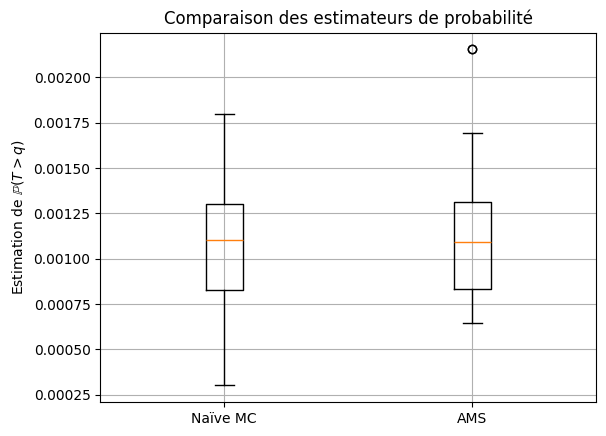

In [ ]:
def compare_estimators(alpha, rho, q, lam, n, M, R, c, theta=10):
    ams_estimates = []
    naive_estimates = []
    is_estimates = []

    for _ in range(R):
        p_ams, _ = last_particle_estimator(alpha, rho, q, n, lam, c)
        p_naive = naive_monte_carlo(alpha, rho, q, M, lam)
        ams_estimates.append(p_ams)
        naive_estimates.append(p_naive)


    # Boxplot avec les 3 méthodes
    plt.boxplot([naive_estimates, ams_estimates],
                labels=["Naïve MC", "AMS"])
    plt.ylabel(r"Estimation de $\mathbb{P}(T > q)$")
    plt.title("Comparaison des estimateurs de probabilité")
    plt.grid(True)
    plt.show()

# 7)  Simulation
alpha = 1.0
rho = 1.5
q = 5.0
lam = 1.0
c = 2         ### borne enveloppe pour rejet
n = 100
M = 1000
R = 50

compare_estimators(alpha, rho, q, lam, n, M, R, c)

In [ ]:
def last_particle_with_CI(alpha, rho, q, n, lam, c, B=200, ci_level=0.95):
    """
    Exécute B fois last_particle_estimator et retourne :
     - p_mean : moyenne des p_est
     - (p_lo, p_hi) : borne inf/sup de l'IC à 'ci_level'
     - Js : tableau des J obtenus
    """
    ps = np.empty(B)
    Js = np.empty(B, dtype=int)
    for b in range(B):
        p, J = last_particle_estimator(alpha, rho, q, n, lam, c)
        ps[b] = p
        Js[b] = J

    alpha2 = (1 - ci_level) / 2
    p_lo, p_hi = np.quantile(ps, [alpha2, 1-alpha2])
    p_mean = ps.mean()
    return p_mean, (p_lo, p_hi), Js

<ipython-input-13-f5f520eb64ac>:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([naive_estimates, ams_estimates], labels=["Naïve MC", "AMS"])


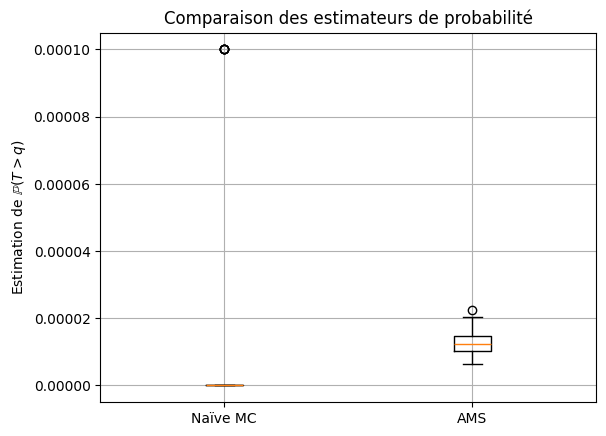

In [ ]:
def compare_estimators(alpha, rho, q, lam, n, M, R, c):
    ams_estimates = []
    naive_estimates = []

    for _ in range(R):
        p_ams, _ = last_particle_estimator(alpha, rho, q, n, lam, c)
        p_naive = naive_monte_carlo(alpha, rho, q, M, lam)
        ams_estimates.append(p_ams)
        naive_estimates.append(p_naive)

    # Boxplot
    plt.boxplot([naive_estimates, ams_estimates], labels=["Naïve MC", "AMS"])
    plt.ylabel(r"Estimation de $\mathbb{P}(T > q)$")
    plt.title("Comparaison des estimateurs de probabilité")
    plt.grid(True)
    plt.show()

# 7)  Simulation
alpha = 1.0
rho = 1.5
q = 8
lam = 1.0
c = 2         # borne enveloppe pour rejet
n = 100       # population AMS
M = 10000     # nombre d’échantillons MC
R = 50        # répétitions

compare_estimators(alpha, rho, q, lam, n, M, R, c)

### Quelques compraisons entre AMS et les etimateurs théoriques

In [ ]:
############################# Paramètres ######################################################
alpha, rho = 1.0, 1.5
q = 6.0
n = 500
############################ Détermination de lam et c pour rejection ##########################
lam = min(rho, 2*rho, 2*alpha + rho)
s_grid = np.linspace(0, 20, 20001)
g_vals = lam * np.exp(-lam * s_grid)
c = np.nanmax(f_T(s_grid, alpha, rho) / g_vals)

########################### Lance B répétitions pour construire l'IC ############################
p_mean, (p_lo, p_hi), Js = last_particle_with_CI(
    alpha, rho, q, n, lam, c,
    B=200,      ### nombre de répétitions Monte Carlo pour l'IC
    ci_level=0.95
)

print(f"Estimateur moyen   : {p_mean:.3e}")
print(f"IC à 95%           : [{p_lo:.3e}, {p_hi:.3e}]")
print(f"Médiane de J       : {np.median(Js)}")

# Valeur théorique P(T > q)
P_th = 1 - quad(lambda s: f_T(s, alpha, rho), 0, q)[0]
print(f"Théorique P(T > q) = {P_th:.3e}")

Estimateur moyen   : 2.482e-04
IC à 95%           : [1.900e-04, 3.041e-04]
Médiane de J       : 4152.0
Théorique P(T > q) = 2.468e-04


In [ ]:
alpha, rho = 1.0, 1.5
q = 7
n = 100
################### Détermination de lam et c pour rejection ################################
lam = min(rho, 2*rho, 2*alpha + rho)
s_grid = np.linspace(0, 20, 20001)
g_vals = lam * np.exp(-lam * s_grid)
c = np.nanmax(f_T(s_grid, alpha, rho) / g_vals)

##################### Lance B répétitions pour construire l'IC ##############################
p_mean, (p_lo, p_hi), Js = last_particle_with_CI(
    alpha, rho, q, n, lam, c,
    B=50,      ### nombre de répétitions Monte Carlo pour l'IC
    ci_level=0.95
)

print(f"Estimateur moyen   : {p_mean:.3e}")
print(f"IC à 95%           : [{p_lo:.3e}, {p_hi:.3e}]")
print(f"Médiane de J       : {np.median(Js)}")

######################### Valeur théorique ###################################################
P_th = 1 - quad(lambda s: f_T(s, alpha, rho), 0, q)[0]
print(f"Théorique P(T>q)   : {P_th:.3e}")

Estimateur moyen   : 5.683e-05
IC à 95%           : [3.531e-05, 8.931e-05]
Médiane de J       : 976.5
Théorique P(T>q)   : 5.507e-05


### Vérification des résultats théoriques du cours pour l'AMS (AMPHI 4)




*   $\sqrt{n}(\hat{p}_n - p) \xrightarrow{d} \mathcal{N}(0, -p^2 \ln p)$

*    $J_n \sim \mathcal{P}(-n \ln p)$




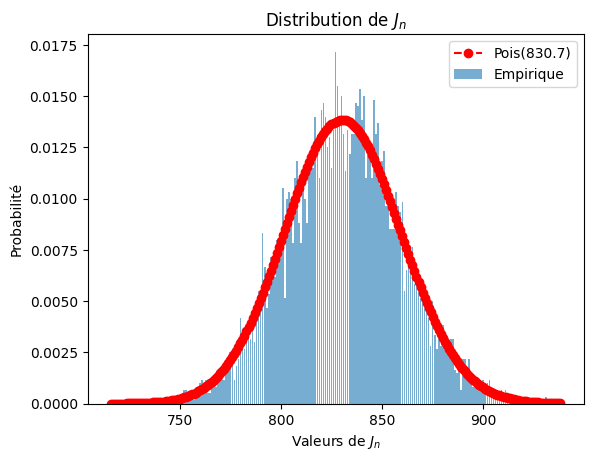

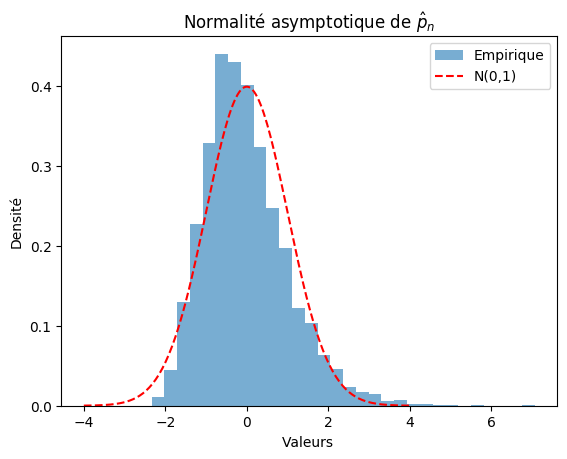

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.stats import poisson, norm


############################ Paramètres ########################################
alpha, rho = 1.0, 1.5
q=6
n = 100
########################### Calcul de p et lambda: les paramètres des lois théorique d'après le cours Amphi4 ##############################
p = 1 - quad(lambda s: f_T(s,alpha,rho), 0, q)[0]
lam_poisson = -n * np.log(p)

############################ Simulation de J et p_hat ##########################
B = 6000   # nombre de répétitions
Js = np.empty(B, int)
p_hats = np.empty(B)
def last_particle_J(alpha, rho, q, n, lam, c):
    p_est, J = last_particle_estimator(alpha, rho, q, n, lam, c)
    return J

for b in range(B):
    J = last_particle_J(alpha, rho, q, n, lam, c)
    Js[b] = J
    p_hats[b] = (1 - 1/n)**J

######################## impirical pmf vs Poisson ##############################
js = np.arange(Js.min(), Js.max()+1)
emp_pmf = np.array([np.mean(Js==j) for j in js])
theo_pmf = poisson.pmf(js, mu=lam_poisson)
plt.xlabel("Valeurs de $J_n$")
plt.ylabel("Probabilité")
plt.bar(js, emp_pmf, alpha=0.6, label='Empirique')
plt.plot(js, theo_pmf, 'r--o', label=f'Pois({lam_poisson:.1f})')
plt.legend(); plt.title("Distribution de $J_n$"); plt.show()

####################### Normalité de notre estimateur p_hat ####################
sigma = np.sqrt(-p**2 * np.log(p))
Z = (np.sqrt(n)*(p_hats - p)) / sigma

_, bins, _ = plt.hist(Z, bins=30, density=True, alpha=0.6, label='Empirique')
x = np.linspace(-4,4,200)
plt.xlabel("Valeurs ")
plt.ylabel("Densité")
plt.plot(x, norm.pdf(x), 'r--', label='N(0,1)')
plt.legend(); plt.title("Normalité asymptotique de $\\hat p_n$"); plt.show()

## Epédemie sur un arbre

### Théorie: Calcul du taux critique: $\alpha_c$


On considère l’épidémie SIR sur un arbre $d$-régulier, où chaque individu infecté peut infecter chacun de ses $d$ fils avant de guérir.  

1.  **Modélisation de la descendance.**
   - Temps jusqu’à infection d’un fils\,:exponentiel de paramètre $\alpha$.  
   - Temps de guérison\,: exponenetiel de paramètre $\rho$.  
   Par propriétés des lois exponentielles indépendantes, la probabilité que l’infection précède la guérison est
   $$
     p \;=\;\mathbb{P}[\text{infection avant guérison}]
     \;=\;\frac{\alpha}{\alpha+\rho}.
   $$
L’espérance du nombre d’enfants infectés est
   $$
     \mathbb{E}(\mu)
     \;=\;d\,p
     \;=\;d\,\frac{\alpha}{\alpha+\rho}.
   $$

3.  **Critère d’extinction.**
   Pour un processus de Galton–Watson dont la descendance a pour moyenne $m=\mathbb{E}(\mu)$ :
   $$
     \begin{cases}
       m \le 1       &\implies \text{extinction presque sûre},\\
       m > 1        &\implies \text{survie avec probabilité }>0.
     \end{cases}
   $$
   
4.  **Détermination de $\alpha_c$.**
   La phase critique se produit quand $m=1$. On résout donc
   $$
     d\,\frac{\alpha_c}{\alpha_c+\rho} \;=\;1
     \quad\Longrightarrow\quad
     d\,\alpha_c \;=\; \alpha_c + \rho
     \quad\Longrightarrow\quad
     \alpha_c\,(d-1) \;=\;\rho
     \quad\Longrightarrow\quad
     \boxed{\alpha_c \;=\;\frac{\rho}{\,d-1\,}.}
   $$
   
Ainsi, dès que
$$
\alpha
\begin{cases}
<\;\alpha_c &\text{(sous-critique : extinction p.s.),}\\
>\;\alpha_c &\text{(sur-critique : survie possible).}
\end{cases}
$$


### Illustration numérique

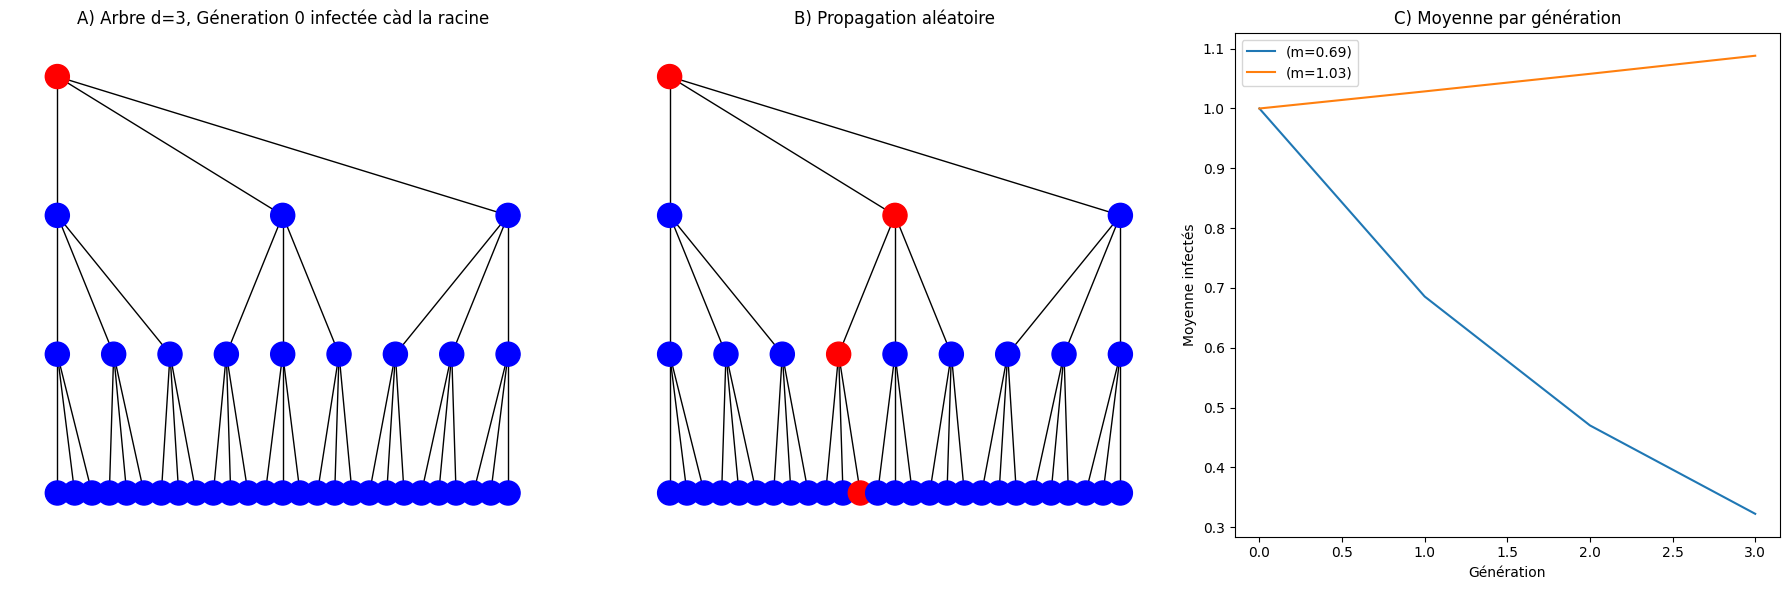

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def generate_tree_positions(G, racine=0):
    """

    Génère des positions hiérarchiques pour un arbre G enraciné en « racines ».
    Les nœuds de même profondeur sont placés sur une même ligne horizontale.
"""
# Calcul de la profondeur (génération) de chaque nœud par parcours en largeur (BFS)
    profondeur = {racine: 0}
    queue = [racine]
    while queue:
        node = queue.pop(0)
        for nbr in G.neighbors(node):
            if nbr not in  profondeur :
                profondeur[nbr] =  profondeur[node] + 1
                queue.append(nbr)

    # On regroupe les noeuds par profondeur
    levels = {}
    for node, d in  profondeur.items():
        levels.setdefault(d, []).append(node)

    # Assigner # Les positions sont définies tq: y = -profondeur  (chaque génération est sur une ligne horizontale distincte) & x = espacées uniformément au sein de chaque niveau
    pos = {}
    for d, nodes in levels.items():
        count = len(nodes)
        xs = np.linspace(0, 1, count)
        for x, node in zip(xs, nodes):
            pos[node] = (x, -d)
    return pos

def simulate_propagation(d=3,  profondeur=3, alpha=0.4, rho=1.0):
    """
    Simuler la propagation SIR sur un arbre d régulier.
    Renvoie le graphe et l'ensemble des noeuds infectés après propagation aléatoire.
    """
    G = nx.balanced_tree(r=d, h= profondeur)
    infected = {0}
    frontier = {0}
    p = alpha / (alpha + rho)
    for _ in range( profondeur):
        new_frontier = set()
        for node in frontier:
            children = [nbr for nbr in G.neighbors(node) if  profondeur_dict[nbr] ==  profondeur_dict[node] + 1]
            for child in children:
                if np.random.rand() < p:
                    new_frontier.add(child)
        infected |= new_frontier
        frontier = new_frontier
    return G, infected

def plot_sir_tree(d=3,  profondeur=3, alpha=0.4, rho=1.0):
    """
    Trace trois figures : Arbre régulier (d) avec racine infectée & Exemple de propagation aléatoire & Nombre moyen infectés par génération (l'espérance)
    """
    G = nx.balanced_tree(r=d, h= profondeur)
    global  profondeur_dict
    profondeur_dict = {}
    queue = [0]
    profondeur_dict[0] = 0
    while queue:
        node = queue.pop(0)
        for nbr in G.neighbors(node):
            if nbr not in  profondeur_dict:
                profondeur_dict[nbr] =  profondeur_dict[node] + 1
                queue.append(nbr)

    ### Simulation
    G, infected = simulate_propagation(d,  profondeur, alpha, rho)
    pos = generate_tree_positions(G, racine=0)
    p = alpha / (alpha + rho)
    m = d * p
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    ### Arbre avec seulement racine infectée
    colors_racine = ['red' if node == 0 else 'blue' for node in G.nodes()]
    nx.draw(G, pos, node_color=colors_racine, ax=axes[0], with_labels=False, node_size=300)
    axes[0].set_title(f"A) Arbre d={d}, Géneration 0 infectée càd la racine")
    axes[0].axis('off')

    ### Arbre après simulation
    colors_inf = ['red' if node in infected else 'blue' for node in G.nodes()]
    nx.draw(G, pos, node_color=colors_inf, ax=axes[1], with_labels=False, node_size=300)
    axes[1].set_title("B) Propagation aléatoire")
    axes[1].axis('off')

    ### Courbes avec differentes valeurs d'esperance
    #####  Ici, on veut toutes les générations depuis 0 jusqu’à profondeur incluse, on prend donc stop = profondeur + 1.
    generations = np.arange(0,  profondeur+1)
    ##### m est la moyenne de reproduction (nombre moyen d’enfants infectés).
    m_sub = m * 0.8 ### Pour simuler le prmeier régime ou m<1 cad epidemie s'etteint
    m_sup = m * 1.2 ### Pour simuler le deuxieme régime ou m>1
    avg_sub = m_sub**generations
    avg_sup = m_sup**generations

    axes[2].plot(generations, avg_sub, label=f"(m={m_sub:.2f})")
    axes[2].plot(generations, avg_sup, label=f"(m={m_sup:.2f})")
    axes[2].set_xlabel("Génération")
    axes[2].set_ylabel("Moyenne infectés")
    axes[2].set_title("C) Moyenne par génération")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

#  Execution pour affichage d'un exemple
plot_sir_tree(d=3,  profondeur=3, alpha=0.4, rho=1.0)

### Commentaires:



> Dans la denière figure à droite, on observe deux courbes représentant le nombre moyen d’individus infectés en fonction de la génération : la courbe décroissante ($m<1$; Régime sous-critique) illustre la disparition progressive de l’épidémie, tandis que la courbe croissante ($m>1$; Régime sur-critique) montre une croissance exponentielle conforme au critère de phase de phase illustré par la théorie.

